# **Install Requeriments**

Connecta com a tua google drive

In [1]:
# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Install**

Instalas a biblioteca necessária para calculares o garu necessário de semelhança entre strings

In [2]:
pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.9/159.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.9 MB/s eta 0:00:00


Instalas a biblioteca necessária para calculares o garu necessário de semelhança entre strings

In [3]:
pip install fuzzywuzzy

### **Import**

In [4]:
# Standard library
import itertools
import inspect
import math
import os
import sys
import time
from datetime import datetime, timedelta, timezone

# Third-party libraries

# Arrays, math, and stats
import joblib
import numpy as np
from numpy.linalg import LinAlgError
from scipy.interpolate import RBFInterpolator, Rbf, griddata
from scipy.optimize import minimize
from scipy.stats import norm

# Data handling
import pandas as pd
from dateutil.relativedelta import relativedelta

# Machine learning
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# Text processing
from fuzzywuzzy import process

# Plotting
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from plotly import express as px
from plotly import graph_objects as go
from plotly.subplots import make_subplots

#**Settings**

**Todas as variaveis que se podem perdsonalizar no algoritmo.**

As primeiras possibilidades de cada variável são aquelas as quais inicialmnete pensas-te que faziam mais sentido:

* data_source = 'sip', 'iex' (Tipos de fornecedores de dados ou IEX ou SIP.)
* symbol = 'AAPL', (retira do ficheito execel, tens o código que extrai)
* max_period = True, (podes ter erros por excesso de pedidos do API)
* start_date = '', '2022-10-31', (1 ano funciona bem para test runs)
* end_date = '', '2023-10-31', (1 ano funciona bem para test runs)
* timeframe = '1Min', '5Min', (mais de 5Min parece perder sentido a teoria)
* fisrt_marker = 'volume', 'close', 'high', 'low', 'trade_count', 'open', 'vwap', 'average_oc', 'average_hl', (a ideia inicial é ver o volume relativo, mas pode ser interessante estudar o trade_count)
* second_marker = 'vwap', 'volume', 'close', 'high', 'low', 'trade_count', 'open', 'average_oc', 'average_hl', (a ideia inicial era ver a média entre o high e o low - 'average_hl', mas fica na duvida ver a média entre o open e o close - 'average_oc', pode também ser muito interessante investigar o vwap)
* third_marker = '', 'volume', 'close', 'high', 'low', 'trade_count', 'open', 'vwap', 'average_oc', 'average_hl', (não pensas te em usar uma terceira coluna para criar as matrizes, mas se os resultados impiricos assim o provarem usa)
* n_rows = 12, 10, 15, 30, 5, (pensa no timeframe quando fazes isso, o 12 pareceu ser o melhor em testes impiricos)
* sort = True, (tens de pensar na sequencia temporal se faz sentido manter ou não)
* adjustment = 'all' ( refere-se ao modo como os preços históricos de barras (candles) são normalizados para refletir eventos corporativos, como stock splits e dividendos. ) ('raw, split, div, all)
* relative_first_marker = True, (tens de pensar em que marker correspondente estás a usar, pensa se matemáticamente faz sentido ou não colocares o marcador com valores relativos para todo o tensor, faltam te dados impiricos, o volume pensas te inicialmnete deixar em impirico para o tensor para normalizares os tensores)
* relative_second_marker = False, (tens de pensar em que marker correspondente estás a usar, pensa se matemáticamente faz sentido ou não colocares o marcador com valores relativos para todo o tensor, faltam te dados impiricos)
* relative_third_marker = False, (tens de pensar em que marker correspondente estás a usar, pensa se matemáticamente faz sentido ou não colocares o marcador com valores relativos para todo o tensor, faltam te dados impiricos)
* decimals = '', 3, 4 (tens de ver o que os dados impiricos te dizem se com arrendondamentos facilitas ou n a vida do AI)
* scaler_type = 'none' (Não se usa scaler), 'minmax' (MinMaxScaler), 'standard' (StandardScaler), 'maxabs' (MaxAbsScaler), 'robust' (RobustScaler), 'quantile' (QuantileTransformer), 'power' (PowerTransformer), 'normalize' (Normalizer), 'binarizer' (Binarizer) (com isto podes escolher qual será o scaler a ser usado no dataset)
* cols_to_scale = None (usa o scaler em todas as colunas), [0] (usas o scaler só na 1ª coluna), [0, 1] (usas o scaler na 1ª e na 2ª coluna), [0, 1, 2] (...)
* LSTM_boolean = True, (em caso de falso não usas um LSTM e partes do precipio que a relação causal deixa de ser importante para a cosntrução do tensor, quando normalizas os dados a esperança seria de não teres de usar um LSTM)
* epochs = 5, (este numero tende a ser irrelevante porque tens um checkpoint de callback referente ao melhor resultado de validation accuracy)
* early_stopping = True, (podes ligar ou desligar de forma automática o early_stopping, ou seja, o call back aqui)
* call_back = 'val_accuracy', 'val_loss', 'accuracy', 'loss' (escolhes o paramtero que monitora o call back)
* patience = 2, 50, 100, 500, 1000 (escolhes a paciencia do call back)
* batch_size = 64, 16, 32, 128, 256, 512 (varias com o tramanho do dataset, mas pensa que tens conseguido datasets bem grandes portanto usa os maiores valores)

In [5]:
# Exemplo de dicionário de configuração:
config = {
    'data_source': 'sip',
    'symbol': 'AAPL',
    'max_period': False,
    'start_date': '2016-01-1',
    'end_date': '2023-12-30',
    'timeframe': '5Min',
    'fisrt_marker': 'vwap',
    'second_marker': 'trade_count',
    'third_marker': '',
    'n_rows': 36,
    'sort': False,
    'adjustment': 'all',
    'relative_first_marker': False,
    'relative_second_marker': False,
    'relative_third_marker': False,
    'decimals': '',
    'scaler_type': 'none',
    'cols_to_scale': [0],
    'LSTM_boolean': True,
    'epochs': 500,
    'early_stopping': True,
    'call_back': 'val_accuracy',
    'patience': 100,
    'batch_size': 128
}

In [6]:
BASE_PATH = '/content/drive/MyDrive/AI Financial Analisys/Summer Project/Vasco'

# Caminho para o diretório onde os arquivos estão localizados
model_diretorio = os.path.join(BASE_PATH, 'Alpaca', 'Models', 'SIP', 'NoScaler') #caminho para o modelo LSTM
old_dataset_path = os.path.join(BASE_PATH, 'Data', 'SIP') #caminho para os datasets já previamente salvos
old_scaler_path = os.path.join(BASE_PATH, 'Data', 'Scalers') #caminho para ir buscar o scaler

Ajustar a janela de valores dos coeficientes e da sensibilidade decisiva em estudo e as suas respectivas granularidades. A sensibilidade decisiva e os coeficientes encontram-se explicados mnas células seguintes.

In [7]:
#sensibilidade decisiva 1 e 2
Max_Selling_SD = 1
Min_Floor_SD = 0
Step_SD = 0.2

# todos os coeficientes
Max_Selling_Coefficient = 8
Min_Floor_Coefficient = 0
Step_Coefficient = 0.5

# valor inicial dos fundos para simular a estratégia
Initial_Funds = 100000 #100K

# testar dataset de teste para diferentes valores inicias de fundo
Max_Selling_Fund = 10000000 #10M
Min_Floor_Fund = 1000 #1K
Step_money = 100 #100

Existem 4 possiveis formas de realizar a método de otimização e teste das estratégias do SunTzu: "training_validation"; "test_legacy"; "sixty_forty"; "seventy_thirty"; "seventy_thirty"; "eighty_twenty"; "training"; "validation".

In [8]:
# Métodos de dataset
otimization_method = "test_legacy" #"training_validation"; "test_legacy"; "sixty_forty"; "seventy_thirty"; "eighty_twenty"; "training"; "validation".

In [9]:
# 5) Choose a default risk-free rate (0 ⇒ zero)
rf = 0.043  # 4.3% annual risk-free rate

Choose between paid and free sun tzu strategy

In [10]:
Paid_Sun_Tzu = True # True (paid sun tzu) & False (free sun tzu)

In [11]:
# Exemplo de uso:
min_delayed = 15    # atraso em minutos
timeframe = '5min' # granularidade

In [12]:
valor_cobranca_otimization=99.0 #99 USD payed to get instant data from the market
valor_cobranca_test=valor_cobranca_otimization

In [13]:
# ====== Slippage configuration (per side, symmetric) ======
SLIPPAGE_BPS = {
    "VOO": 2, "DIA": 2, "IWM": 4,
    "AAPL": 3, "AMZN": 3, "GOOG": 3, "MSFT": 3, "NVDA": 3,
}
DEFAULT_SLIPPAGE_BPS = 5  # fallback if symbol not in dict

#### Extra Settings for Last Strategy

In [14]:
#sensibilidade decisiva 1 e 2
Max_Selling_SD_Last_Strategy = 1
Min_Floor_SD_Last_Strategy = 0
Step_SD_Last_Strategy = 0.2

# todos os coeficientes
Max_Selling_Coefficient_Last_Strategy = 4
Min_Floor_Coefficient_Last_Strategy = 1
Step_Coefficient_Last_Strategy = 0.5

# valor inicial dos fundos para simular a estratégia
Initial_Funds_Last_Strategy = 100000 #100K

# testar dataset de teste para diferentes valores inicias de fundo
Max_Selling_Fund_Last_Strategy = 10000000 #10M
Min_Floor_Fund_Last_Strategy = 1000 #1K
Step_money_Last_Strategy = 100 #100

### **Backend**

In [15]:
eps = 1e-10

In [16]:
# Arrays para os parâmetros:
sensibilidade_decisiva1_array_otimization = np.arange(Min_Floor_SD, Max_Selling_SD + Step_SD, Step_SD)  # Para sensibilidade decisiva 1
sensibilidade_decisiva2_array_otimization = np.arange(Min_Floor_SD, Max_Selling_SD + Step_SD, Step_SD)  # Para sensibilidade decisiva 2
coeficiente_c_array_otimization = np.arange(Min_Floor_Coefficient, Max_Selling_Coefficient + Step_Coefficient, Step_Coefficient) # Para Compra
coeficiente_v_array_otimization = np.arange(Min_Floor_Coefficient, Max_Selling_Coefficient + Step_Coefficient, Step_Coefficient) # Para Venda
coeficiente_s_array_otimization = np.arange(Min_Floor_Coefficient, Max_Selling_Coefficient + Step_Coefficient, Step_Coefficient)  # Coeficiente de Short-Selling

In [17]:
# Arrays para os parâmetros da ultima estratégia:
sensibilidade_decisiva1_array_otimization_Last_Strategy = np.arange(Min_Floor_SD_Last_Strategy, Max_Selling_SD_Last_Strategy + Step_SD_Last_Strategy, Step_SD_Last_Strategy)  # Para sensibilidade decisiva 1
sensibilidade_decisiva2_array_otimization_Last_Strategy = np.arange(Min_Floor_SD_Last_Strategy, Max_Selling_SD_Last_Strategy + Step_SD_Last_Strategy, Step_SD_Last_Strategy)  # Para sensibilidade decisiva 2
coeficiente_c_array_otimization_Last_Strategy = np.arange(Min_Floor_Coefficient_Last_Strategy, Max_Selling_Coefficient_Last_Strategy + Step_Coefficient_Last_Strategy, Step_Coefficient_Last_Strategy) # Para Compra
coeficiente_v_array_otimization_Last_Strategy = np.arange(Min_Floor_Coefficient_Last_Strategy, Max_Selling_Coefficient_Last_Strategy + Step_Coefficient_Last_Strategy, Step_Coefficient_Last_Strategy) # Para Venda
coeficiente_s_array_otimization_Last_Strategy = np.arange(Min_Floor_Coefficient_Last_Strategy, Max_Selling_Coefficient_Last_Strategy + Step_Coefficient_Last_Strategy, Step_Coefficient_Last_Strategy)  # Coeficiente de Short-Selling

In [18]:
def calculate_fee(transaction_type, transaction_value, open_time=None, cover_time=None,
                  borrowing_rate=0.01, sec_fee_rate=27.80, days_in_year=365, minutes_in_day=1440):
    """
    Calcula as taxas (custos) para uma transação de acordo com o tipo.
    A API Alpaca não cobra comissões diretas.

    Para uma posição de venda a descoberto:
      - Ao abrir a posição curta (transaction_type 'short'), cobra-se a SEC fee,
        calculada como: (transaction_value / 1_000_000) * sec_fee_rate.
      - Ao cobrir a posição curta (transaction_type 'cover'), cobra-se o custo de empréstimo,
        calculado com base no tempo real decorrido (em minutos) entre open_time e cover_time,
        usando uma base anual de 365 dias e considerando 1440 minutos por dia (24 horas).

    Parâmetros:
      - transaction_type: string, um dos seguintes:
          'buy'   -> Ordem de compra (taxa = 0)
          'sell'  -> Ordem de venda (aplica SEC fee)
          'short' -> Abrir uma posição short (aplica SEC fee)
          'cover' -> Cobrir a posição short (calcula o custo de empréstimo)
      - transaction_value: valor total da transação em dólares.
          Exemplo: Para 1.000 ações a US$150, transaction_value = 150000.
      - open_time: objeto datetime indicando quando a posição short foi aberta
                   (obrigatório para 'cover').
      - cover_time: objeto datetime indicando quando a posição short foi coberta
                    (obrigatório para 'cover').
      - borrowing_rate: taxa anual de empréstimo (em decimal, ex.: 0.01 para 1% ao ano).
      - sec_fee_rate: taxa da SEC em dólares por milhão negociado (default US$27,80).
      - days_in_year: número de dias para anualizar o custo de empréstimo (geralmente 365 para o ano inteiro).
      - minutes_in_day: número de minutos por dia para o cálculo de juros.
                       Aqui usamos 1440 para considerar o dia completo (24 horas).

    Retorna:
      - fee: custo total da transação em dólares.
    """
    ttype = transaction_type.lower()

    if ttype == 'buy':
        return 0.0
    elif ttype == 'sell':
        return (transaction_value / 1_000_000) * sec_fee_rate
    elif ttype == 'short':
        # Ao abrir a posição curta, cobra-se a SEC fee.
        return (transaction_value / 1_000_000) * sec_fee_rate
    elif ttype == 'cover':
        if open_time is None or cover_time is None:
            raise ValueError("Para 'cover', open_time e cover_time devem ser fornecidos.")
        # Calcula o tempo decorrido em minutos entre open_time e cover_time.
        holding_minutes = (cover_time - open_time).total_seconds() / 60
        # Converte a taxa anual para uma taxa por minuto, considerando um dia completo (1440 minutos)
        per_minute_rate = borrowing_rate / (days_in_year * minutes_in_day)
        borrowing_fee = transaction_value * per_minute_rate * holding_minutes
        return borrowing_fee
    else:
        raise ValueError("Tipo de transação inválido. Use 'buy', 'sell', 'short' ou 'cover'.")

In [19]:
# ====== Slippage configuration (per side, symmetric) ======

def _bps_for(side: str, ticker: str) -> float:
    # Same bps per side; you can split BUY/SELL later if you want asymmetry.
    return SLIPPAGE_BPS.get(ticker, DEFAULT_SLIPPAGE_BPS)

def exec_price_with_slippage(side: str, mid_price: float, ticker: str) -> float:
    """
    Adjust execution price by per-ticker slippage in basis points (1 bp = 0.01%).
      - 'buy'  or 'cover' => pay higher:   mid * (1 + bps/1e4)
      - 'sell' or 'short' => receive less: mid * (1 - bps/1e4)
    """
    bps = _bps_for(side, ticker)
    if side in ("buy", "cover"):
        return mid_price * (1.0 + bps / 1e4)
    elif side in ("sell", "short"):
        return mid_price * (1.0 - bps / 1e4)
    return mid_price

In [20]:
def parse_timeframe(timeframe):
    """
    Converte o timeframe para minutos.

    Parâmetros:
        timeframe (str, int ou float): Pode ser:
            - Uma string no formato 'XMin', representando X minutos;
            - Uma string no formato 'XSec', representando X segundos (convertidos para minutos);
            - Um número, que já será considerado em minutos.

    Retorna:
        float: Valor do timeframe em minutos.

    Lança:
        ValueError: Se o formato ou tipo do timeframe for inválido.
    """
    if isinstance(timeframe, str):
        timeframe = timeframe.strip()
        # Verifica se termina com "min" (ignorando maiúsculas/minúsculas)
        if timeframe[-3:].lower() == "min":
            try:
                return float(timeframe[:-3])
            except ValueError:
                raise ValueError("Formato de timeframe inválido: não foi possível converter o valor para float.")
        # Verifica se termina com "sec" (ignorando maiúsculas/minúsculas)
        elif timeframe[-3:].lower() == "sec":
            try:
                seconds = float(timeframe[:-3])
                return seconds / 60.0  # converte segundos para minutos
            except ValueError:
                raise ValueError("Formato de timeframe inválido: não foi possível converter o valor para float.")
        else:
            raise ValueError("Formato de timeframe inválido: deve terminar com 'Min' ou 'Sec'.")
    elif isinstance(timeframe, (int, float)):
        return float(timeframe)
    else:
        raise ValueError("Tipo de timeframe inválido. Deve ser uma string ou um número.")

def time_delay(min_delayed, timeframe):
    """
    Calcula o fator de atraso (time delay) como a razão entre min_delayed e timeframe,
    utilizando a divisão para validar se o atraso desejado é suportado pela granularidade.

    Observação: O cálculo é feito em minutos, portanto, o timeframe é convertido para minutos
    caso esteja no formato 'XMin' ou 'XSec'.

    Parâmetros:
        min_delayed (float ou int): Valor do atraso em minutos.
        timeframe (str, float ou int): Valor do timeframe. Se for string, pode ser 'XMin' ou 'XSec'.

    Retorna:
        int: Fator de atraso calculado.

    Lança:
        ValueError: Se o timeframe convertido for menor ou igual a zero ou se a granularidade do dataset
                    não suportar o atraso de tempo (ou seja, quando min_delayed não for múltiplo exato do timeframe).
    """
    # Converte o timeframe para minutos, se necessário
    timeframe_minutes = parse_timeframe(timeframe)

    if timeframe_minutes <= 0:
        raise ValueError("O timeframe deve ser um valor positivo e diferente de zero.")

    # Calcula o resto da divisão para verificar se o atraso desejado é compatível com a granularidade
    remainder = min_delayed % timeframe_minutes
    # Para evitar problemas com precisão de ponto flutuante, usa-se math.isclose
    if not math.isclose(remainder, 0, abs_tol=1e-9):
        raise ValueError("A granularidade do dataset não suporta esse atraso de tempo.")

    # Retorna o quociente da divisão, convertendo para inteiro
    return int(min_delayed / timeframe_minutes)

In [21]:
if not Paid_Sun_Tzu:
    granular_delay = time_delay(min_delayed, timeframe)
    print(granular_delay)

In [22]:
def estimate_periods_per_year(returns: pd.Series) -> float:
    """
    Estimate the effective number of periods per calendar year
    based on the count of observed return bars per year.
    """
    counts = returns.groupby(returns.index.year).size()
    return counts.mean()

def make_metrics(P: float) -> dict:
    """
    Generate a dictionary of performance metric functions
    parameterized by P periods per year.
    """
    def _rf_per_period(rf_annual: float) -> float:
        return (1 + rf_annual) ** (1 / P) - 1

    def total_return(returns: pd.Series) -> float:
        return (1 + returns).prod() - 1

    def annualized_return(returns: pd.Series) -> float:
        total = total_return(returns)
        n = len(returns)
        return (1 + total) ** (P / n) - 1

    def annualized_volatility(returns: pd.Series) -> float:
        return returns.std(ddof=1) * np.sqrt(P)

    def sharpe_ratio(returns: pd.Series, rf: float = 0.0) -> float:
        rf_p = _rf_per_period(rf)
        ex = returns - rf_p
        return ex.mean() / ex.std(ddof=1) * np.sqrt(P)

    def sortino_ratio(returns: pd.Series, rf: float = 0.0) -> float:
        rf_p = _rf_per_period(rf)
        ex = returns - rf_p
        neg = ex[ex < 0]
        dd_std = np.sqrt((neg ** 2).mean())
        return ex.mean() / dd_std * np.sqrt(P)

    def max_drawdown(returns: pd.Series) -> float:
        cum = (1 + returns).cumprod()
        high = cum.cummax()
        return (cum / high - 1).min()

    def drawdown_duration(returns: pd.Series) -> int:
        cum = (1 + returns).cumprod()
        high = cum.cummax()
        is_dd = cum < high
        durations = [sum(1 for _ in group) for val, group in itertools.groupby(is_dd) if val]
        return max(durations) if durations else 0

    def ulcer_index(returns: pd.Series) -> float:
        cum = (1 + returns).cumprod()
        high = cum.cummax()
        dd = (cum / high - 1) * 100
        return np.sqrt((dd ** 2).mean())

    def value_at_risk(returns: pd.Series, confidence: float = 0.95) -> float:
        return -returns.quantile(1 - confidence)

    def expected_shortfall(returns: pd.Series, confidence: float = 0.95) -> float:
        cutoff = returns.quantile(1 - confidence)
        return -returns[returns <= cutoff].mean()

    def calmar_ratio(returns: pd.Series) -> float:
        ann = annualized_return(returns)
        mdd = abs(max_drawdown(returns))
        return ann / mdd

    def information_ratio(returns: pd.Series, benchmark_returns: pd.Series) -> float:
        diff = returns - benchmark_returns
        return diff.mean() / diff.std(ddof=1) * np.sqrt(P)

    def _capm_regression(returns: pd.Series,
                         benchmark_returns: pd.Series, rf: float = 0.0):
        rf_p = _rf_per_period(rf)
        y = returns - rf_p
        x = benchmark_returns - rf_p
        X = sm.add_constant(x)
        return sm.OLS(y, X).fit()

    def beta(returns: pd.Series, benchmark_returns: pd.Series, rf: float = 0.0) -> float:
        return _capm_regression(returns, benchmark_returns, rf).params[1]

    def alpha(returns: pd.Series, benchmark_returns: pd.Series, rf: float = 0.0) -> float:
        a = _capm_regression(returns, benchmark_returns, rf).params[0]
        return (1 + a) ** P - 1

    def r_squared(returns: pd.Series, benchmark_returns: pd.Series, rf: float = 0.0) -> float:
        return _capm_regression(returns, benchmark_returns, rf).rsquared

    def treynor_ratio(returns: pd.Series, benchmark_returns: pd.Series, rf: float = 0.0) -> float:
        ann_ex = annualized_return(returns) - rf
        b = beta(returns, benchmark_returns, rf)
        return ann_ex / b

    def skewness(returns: pd.Series) -> float:
        return returns.skew()

    def kurtosis(returns: pd.Series) -> float:
        return returns.kurtosis()

    def omega_ratio(returns: pd.Series, threshold: float = 0.0) -> float:
        gains = returns[returns > threshold] - threshold
        losses = threshold - returns[returns < threshold]
        return gains.sum() / losses.sum()

    return {
        "total_return": total_return,
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe_ratio": sharpe_ratio,
        "sortino_ratio": sortino_ratio,
        "max_drawdown": max_drawdown,
        "drawdown_duration": drawdown_duration,
        "ulcer_index": ulcer_index,
        "value_at_risk": value_at_risk,
        "expected_shortfall": expected_shortfall,
        "calmar_ratio": calmar_ratio,
        "information_ratio": information_ratio,
        "beta": beta,
        "alpha": alpha,
        "r_squared": r_squared,
        "treynor_ratio": treynor_ratio,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "omega_ratio": omega_ratio,
    }

# **Escolhendo o Modelo Para Ser Utilizado:**

Todas as variaveis que se podem personalizar de forma a escolher o modelo e o dataset a ser usado neste algoritmo para testar estratégias de como usar da melhor forma o modelo no mercado.

In [23]:
def assign_config_vars(config):

    data_source = config['data_source']
    symbol = config['symbol']
    max_period = config['max_period']
    start_date = config['start_date']
    end_date = config['end_date']
    timeframe = config['timeframe']
    fisrt_marker = config['fisrt_marker']
    second_marker = config['second_marker']
    third_marker = config['third_marker']
    n_rows = config['n_rows']
    sort = config['sort']
    adjustment = config['adjustment']
    relative_first_marker = config['relative_first_marker']
    relative_second_marker = config['relative_second_marker']
    relative_third_marker = config['relative_third_marker']
    decimals = config['decimals']
    scaler_type = config['scaler_type']
    cols_to_scale = config['cols_to_scale']
    LSTM_boolean = config['LSTM_boolean']
    epochs = config['epochs']
    early_stopping = config['early_stopping']
    call_back = config['call_back']
    patience = config['patience']
    batch_size = config['batch_size']

    return (data_source, symbol, max_period, start_date, end_date, timeframe,
            fisrt_marker, second_marker, third_marker, n_rows, sort, adjustment,
            relative_first_marker, relative_second_marker, relative_third_marker,
            decimals, scaler_type, cols_to_scale, LSTM_boolean, epochs,
            early_stopping, call_back, patience, batch_size)

In [24]:
# Chamada da função, fazendo o "unpack" dos valores retornados para as variáveis:
(data_source, symbol, max_period, start_date, end_date, timeframe,
 fisrt_marker, second_marker, third_marker, n_rows, sort, adjustment,
 relative_first_marker, relative_second_marker, relative_third_marker,
 decimals, scaler_type, cols_to_scale, LSTM_boolean, epochs,
 early_stopping, call_back, patience, batch_size) = assign_config_vars(config)

Iniciar as variaveis reponsáveis por possivelmente localizar o modelo que está a ser escolhido, uma parte da encriptação do nome do ficheiro com o modelo são os resultados do modelo e aqui iniciacia-se os parametros dos resultado do modelo.

In [25]:
test_loss = 0.0000
test_accuracy = 0.0000

Função que utiliza as variaveis selecionadas para criar o nome de busca pelo ficheiro que se existir e encontra o modelo guardado que terá um nome de ficheiro igual ou parecido.

In [26]:
def create_file_name(data_source, symbol, max_period, start_date, end_date,
                     timeframe, first_marker, second_marker, third_marker,
                     n_rows, sort, adjustment, relative_first_marker, relative_second_marker,
                     relative_third_marker, decimals, scaler_type, cols_to_scale,
                     LSTM_boolean, epochs, early_stopping, call_back, patience,
                     batch_size, test_loss, test_accuracy):

    # Nome aproximado do arquivo
    nome_aproximado = 'ds=' + data_source + '+' + 's=' + symbol + '+' + 'mp=' + str(max_period) + '+' + 'sd=' + \
    start_date + '+' + 'ed=' + end_date + '+' + 'tf=' + timeframe + '+' + \
    'fm=' + first_marker + '+' + 'sm=' + second_marker + '+' + \
    'tm=' + third_marker + '+' + 'r=' + str(n_rows) + '+' + \
    'sort=' + str(sort) + '+' + 'adjustment=' + adjustment + '+' + 'rfm=' + str(relative_first_marker) + '+' + \
    'rsm=' + str(relative_second_marker) + '+' + \
    'rtm=' + str(relative_third_marker) + '+' + \
    'd=' + decimals + '+' + 'st=' + scaler_type + '+' + 'cts=' + str(cols_to_scale) + '+' + \
    'Lb=' + str(LSTM_boolean) + '+' + 'e=' + str(epochs) + '+' + \
    'es=' + str(early_stopping) + '+' + 'cb=' + call_back + '+' + \
    'p=' + str(patience) + '+' + 'bs=' + str(batch_size) + '+' + \
    'tl=' + str(round(test_loss, 4)) + '+' + 'ta=' + str(round(test_accuracy, 4))

    return nome_aproximado

Esta função permite extrair as variaveis do nome do ficheiro escolhido como modelo a ser testado e dataset a ser usado.

In [27]:
def get_variables_from_file_name(file_name):

    # Remover a extensão '.keras' se estiver presente
    if file_name.endswith('.keras'):
        file_name = file_name[:-6]  # Remove os últimos 6 caracteres
    elif file_name.endswith('.h5'):
        file_name = file_name[:-3]  # Remove os últimos 3 caracteres

    # Dividir a string pelo caractere '_'
    parts = file_name.split('+')

    # Dicionário para armazenar as variáveis extraídas
    variables = {}

    # Dicionário para mapear os prefixos no nome do arquivo às variáveis da função
    prefix_map = {
        'ds=': 'data_source',
        's=': 'symbol',
        'mp=': 'max_period',
        'sd=': 'start_date',
        'ed=': 'end_date',
        'tf=': 'timeframe',
        'fm=': 'first_marker',
        'sm=': 'second_marker',
        'tm=': 'third_marker',
        'r=': 'n_rows',
        'sort=': 'sort',
        'adjustment=': 'adjustment',
        'rfm=': 'relative_first_marker',
        'rsm=': 'relative_second_marker',
        'rtm=': 'relative_third_marker',
        'd=': 'decimals',
        'cts=': 'cols_to_scale',
        'st=': 'scaler_type',
        'Lb=': 'LSTM_boolean',
        'e=': 'epochs',
        'es=': 'early_stopping',
        'cb=': 'call_back',
        'p=': 'patience',
        'bs=': 'batch_size',
        'tl=': 'test_loss',
        'ta=': 'test_accuracy'
    }

    # Percorrer as partes e extrair o prefixo e o valor correspondente
    for part in parts:
        for prefix, var_name in prefix_map.items():
            if part.startswith(prefix):
                # Extrair o valor removendo o prefixo
                value = part[len(prefix):]

                # Converter os valores para seus tipos originais
                if var_name in ['max_period', 'sort', 'relative_first_marker',
                                'relative_second_marker', 'relative_third_marker',
                                'LSTM_boolean', 'early_stopping']:
                    value = value.lower() == 'true'
                elif var_name in ['n_rows', 'epochs', 'patience', 'batch_size']:
                    value = int(value)
                elif var_name in ['test_loss', 'test_accuracy']:
                    value = float(value)

                # Armazenar o valor no dicionário
                variables[var_name] = value
                break

    return variables

usa as variaveis introduzidas anteriormente para procurar na base de modelos criados e treinados qual é que mais se aproxima do modelo solicitado pelas variaveis. Para isto é utilizado uma biblioteca que tem funçõe que permite comparar strings a comparação com a pontuação mais elevada entre o nome virtual criado pelas vairaveis introduzidas no suntzu e o nome do ficheiro onde estam encriptadas as variaveis que foram usadas no alpaca para criar e treinar o modelo. O ficehiro que produzir a pontuação de comparação mais elevada é usado para ser testado no suntzu. Desta forma é carregado um modelo e um dataset da base de dados.

In [28]:
# Nome aproximado do arquivo
nome_aproximado = create_file_name(data_source, symbol, max_period, start_date, end_date,
                                    timeframe, fisrt_marker, second_marker, third_marker,
                                    n_rows, sort, adjustment, relative_first_marker, relative_second_marker,
                                    relative_third_marker, decimals, scaler_type, cols_to_scale,
                                    LSTM_boolean, epochs, early_stopping, call_back, patience,
                                    batch_size, test_loss, test_accuracy)

# Lista todos os arquivos no diretório
arquivos = os.listdir(model_diretorio)

# 3) CONDIÇÃO OBRIGATÓRIA: o nome do ficheiro tem de conter `symbol`
sym = symbol.casefold()
candidatos = [arq for arq in arquivos if sym in arq.casefold()]

if not candidatos:
    print(f"Nenhum arquivo encontrado em '{model_diretorio}' que contenha o símbolo '{symbol}'.")
else:
    # 4) Entre os que contêm `symbol`, escolhe o mais parecido
    arquivo_mais_proximo, pontuacao = process.extractOne(nome_aproximado, candidatos)

if arquivo_mais_proximo:
    caminho_do_modelo = os.path.join(model_diretorio, arquivo_mais_proximo)
    print("Nome do arquivo mais próximo:")
    print(arquivo_mais_proximo)
    print()
    print("Caminho completo do modelo:")
    print(caminho_do_modelo)
    print()
    print("Pontuação de similaridade:")
    print(pontuacao)

else:
    print("Nenhum arquivo próximo encontrado.")

Nome do arquivo mais próximo:
ds=sip+s=AAPL+mp=False+sd=2016-01-1+ed=2024-12-30+tf=5Min+fm=vwap+sm=trade_count+tm=+r=36+sort=False+adjustment=all+rfm=False+rsm=False+rtm=False+d=+st=none+cts=[0]+Lb=True+e=500+es=True+cb=val_accuracy+p=100+bs=128+tl=0.4137+ta=0.844.keras

Caminho completo do modelo:
/content/drive/MyDrive/AI Financial Analisys/Summer Project/Vasco/Alpaca/Models/SIP/NoScaler/ds=sip+s=AAPL+mp=False+sd=2016-01-1+ed=2024-12-30+tf=5Min+fm=vwap+sm=trade_count+tm=+r=36+sort=False+adjustment=all+rfm=False+rsm=False+rtm=False+d=+st=none+cts=[0]+Lb=True+e=500+es=True+cb=val_accuracy+p=100+bs=128+tl=0.4137+ta=0.844.keras

Pontuação de similaridade:
96


do ficheiro carregado serão extraidas as variaveis encriptadas no nome do ficheiro, para serem usadas para correr o modelo e testar as estratégias de otimização de gestão de portefólio ao longo do SunTzu.

In [29]:
# Usando a função get_variables_from_file_name para extrair as variáveis
print(arquivo_mais_proximo)
variables = get_variables_from_file_name(arquivo_mais_proximo)


# Imprimir as variáveis extraídas para depuração
print("Variáveis extraídas:", variables)
print()

# Agora redefinindo todas as variáveis usando o dicionário `variables`
data_source = variables['data_source']
symbol = variables['symbol']
max_period = variables['max_period']
start_date = variables['start_date']
end_date = variables['end_date']
timeframe = variables['timeframe']
first_marker = variables['first_marker']
second_marker = variables['second_marker']
third_marker = variables['third_marker']
n_rows = variables['n_rows']
sort = variables['sort']
adjustment = variables['adjustment']
relative_first_marker = variables['relative_first_marker']
relative_second_marker = variables['relative_second_marker']
relative_third_marker = variables['relative_third_marker']
decimals = variables['decimals']
scaler_type = variables['scaler_type']
cols_to_scale = variables['cols_to_scale']
LSTM_boolean = variables['LSTM_boolean']
epochs = variables['epochs']
early_stopping = variables['early_stopping']
call_back = variables['call_back']
patience = variables['patience']
batch_size = variables['batch_size']

ds=sip+s=AAPL+mp=False+sd=2016-01-1+ed=2024-12-30+tf=5Min+fm=vwap+sm=trade_count+tm=+r=36+sort=False+adjustment=all+rfm=False+rsm=False+rtm=False+d=+st=none+cts=[0]+Lb=True+e=500+es=True+cb=val_accuracy+p=100+bs=128+tl=0.4137+ta=0.844.keras
Variáveis extraídas: {'data_source': 'sip', 'symbol': 'AAPL', 'max_period': False, 'start_date': '2016-01-1', 'end_date': '2024-12-30', 'timeframe': '5Min', 'first_marker': 'vwap', 'second_marker': 'trade_count', 'third_marker': '', 'n_rows': 36, 'sort': False, 'adjustment': 'all', 'relative_first_marker': False, 'relative_second_marker': False, 'relative_third_marker': False, 'decimals': '', 'scaler_type': 'none', 'cols_to_scale': '[0]', 'LSTM_boolean': True, 'epochs': 500, 'early_stopping': True, 'call_back': 'val_accuracy', 'patience': 100, 'batch_size': 128, 'test_loss': 0.4137, 'test_accuracy': 0.844}



In [30]:
model = load_model(caminho_do_modelo)
print("Modelo e variáveis carregados!")

Modelo e variáveis carregados!


Este parte do código permite obter as características da arqitetura do AI que está a ser usada.

In [31]:
# Opcional: visualizar o resumo do modelo
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 36, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 36, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,725 (588.77 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 100,484 (392.52 KB)

# **Obtendo os Dados para Modelos LSTM:**

Esta função irá preparar dos dados para o modelo. Do Alpca seram retirados multiplos parametros do mercado interessa-te selecionar apenas os que queres alimentar ao modelo para isso esat função é usada para os selecionar. podes escolher entre 'close', 'high', 'low', 'trade_count', 'open', 'volume', 'vwap', que são os parametros de mercado dados por default pelo Alpaca. Mas para além disso crias te outras 2 métricas com base nas métricas já dadas caso as queiras testar eslas são: 'average_oc' e 'average_hl', que correspondem, respetivamente, ao ponto médio entre o open e o close e o ponto médio entre o high e o low.



*   close é o preço de fecho da ação naquele intervalo temporal
*   high é o preço mais alto da ação naquele intervalo temporal
*   low é o preço mais baixo da ação naquele intervalo temporal
*   trade_count é o número de matches entre compradosres e vendedores naquele intervalo temporal
*   open é o preço de abertura da ação naquele intervalo temporal
*   vwap é o preço da ação por volume naquele intervalo temporal ( uma forma diferente de olhar para o valor intrinseco de uma ação)



In [32]:
# Function to prepare the data
def prepare_data(data, fisrt_marker, second_marker, third_marker = ''):
    # Selecionar colunas relevantes e fazer uma cópia para evitar advertências
    data_selected = data[['close', 'high', 'low', 'trade_count', 'open', 'volume', 'vwap']].copy()

    # Calcular a média entre 'Open' e 'Close' usando .loc para evitar o SettingWithCopyWarning
    data_selected.loc[:, 'average_oc'] = data_selected[['open', 'close']].mean(axis=1)

    # Calcular a média entre 'High' e 'Low' usando .loc para evitar o SettingWithCopyWarning
    data_selected.loc[:, 'average_hl'] = data_selected[['high', 'low']].mean(axis=1)

    # Selecionar as colunas finais
    if third_marker != '':
        data_final = data_selected[[fisrt_marker, second_marker, third_marker]]
    else:
        data_final = data_selected[[fisrt_marker, second_marker]]

    return data_final

Agora temos de continuara a preparação dos dados para serem alimentado ao modelo para isso crio matrizes para segmentar os dados, cada matriz vai ter uma label: 0 ou 1. Assim o dataset vai ser constituido por ,atrizes de tamanho a defenir pelo o usuário do algoritmo e pelas suas respetivas labels de 0 ou 1. As matrizes no máximo poderão ter até 3 colunas, cada coluna representa uma metrica difrente do mercado. As linhas estam inicialmente organizadas de forma sequencial e representação a cada uma a granuralidade mínima do dataset, assim se a granuralidade é de 1 minuto e uma matriz tem 5 linhas, cada matriz representa 5 minutos continuos de métricas do mercado no tempo. As métricas de cada matriz por coluna podem ser formatadas como relativas, o que significa que as métricas da matriz seram apresentadas de forma relativa á matriz em questão, o que pode ser interessante para modelos sem ser um LSTM, pois permite que os dados históricos sejam baralhados temporalmente e manetenham coerência. Como é o caso por exemplo do preço e do volume, com a inflação é normal que o preço aumente mas não queremos que isso cause uma precepção errada de magnitude superior ao nosso modelo assim o 'relative' faz com que as métricas das matrizes apareçam como valores ponderados aos restantes valores da matriz, assim cada valor da métrica relativa é dividida pelo somatório dos valores dessa métrica presentes na matriz.

In [33]:
# Função para criar as matrizes e os labels
def create_matrices(
    data_final, n, fisrt_marker, second_marker,
    third_marker, relative_fisrt_marker,
    relative_second_marker, relative_third_marker
    ):

    # Assuming num_matrices is defined, e.g., num_matrices = len(data_final) // n
    num_matrices = len(data_final) // n # Example definition, adjust as per your full code

    matrices_x = [] # Renamed for clarity, this will be your list of feature matrices
    matrices_y = []

    for i in range(num_matrices):
        start_idx = i * n
        end_idx = start_idx + n
        # Create a DataFrame for the current matrix
        current_matrix_df = data_final.iloc[start_idx:end_idx].copy()

        # Apply relative transformations if the respective flags are true
        if relative_fisrt_marker:
            volume_sum = current_matrix_df[fisrt_marker].sum()
            if volume_sum != 0:  # Avoid division by zero
                current_matrix_df[fisrt_marker] = current_matrix_df[fisrt_marker] / volume_sum
            # else: you might want to handle the case where volume_sum is 0

        if relative_second_marker:
            volume_sum = current_matrix_df[second_marker].sum()
            if volume_sum != 0: # Avoid division by zero
                current_matrix_df[second_marker] = current_matrix_df[second_marker] / volume_sum
            # else: handle zero sum if necessary

        if relative_third_marker:
            volume_sum = current_matrix_df[third_marker].sum()
            if volume_sum != 0: # Avoid division by zero
                current_matrix_df[third_marker] = current_matrix_df[third_marker] / volume_sum
            # else: handle zero sum if necessary

        # Append the processed matrix (as numpy array) to matrices_x
        # This ensures matrices_x has one entry per i
        matrices_x.append(current_matrix_df.values)

        # Create labels
        # The condition 'i > 0' means the label is for the current matrix (matrices_x[i]),
        # and the very first matrix (matrices_x[0]) will not have a label.
        if i > 0:  # Ignorar a primeira matriz para alinhamento correto
            # Now matrices_x[i] is guaranteed to exist.
            first_value = matrices_x[i][0, 1]   # Access the relevant value from the current matrix
            last_value = matrices_x[i][n - 1, 1] # Access the relevant value from the current matrix
            delta = last_value - first_value
            delta_bi = 1 if delta >= 0 else 0
            matrices_y.append(delta_bi)

    return matrices_x, matrices_y

Caso se entenda que a ordem temporal, devido á elevada granuraridade dos dados de uma matriz, é irrelevante, esta função permite ordenar por ordem decrescente da métrica da segunda coluna os valores de uma matriz e assim por exemplo caso na segunda coluna se tenha o valor de volume estaria se a observar em cada matriz o preço por ordem crescente do volume. Esta função pode ser ativada ou desativada e pode ser interessante para uma elevada granuralidade em que as matrizes apenas representam 5 minutos e não se está a usar uma LSTM.

In [34]:
def sort_matrices(matrices):
    # Ordenar as linhas de cada matriz por ordem decrescente da coluna Average (segunda coluna)
    matrices_x = []
    for matrix in matrices:
        sorted_indices = np.argsort(matrix[:, 1])[::-1]
        sorted_matrix = matrix[sorted_indices]
        matrices_x.append(sorted_matrix)
    return matrices_x

Funçaõ para passar as matrizes para tensores para poderem ser tartadas pelo TensorFlow

In [35]:
def tensor_creator(matrices_x, matrices_y):
    # Converter listas para arrays numpy
    matrices_x = np.array(matrices_x)
    matrices_y = np.array(matrices_y)
    return matrices_x, matrices_y

Função que integra todas as outras funções que falamos para obter o dataset e manipulá-lo conforme o utilizador do algoritmo deseja

In [36]:
def get_dataset(
    company_data,
    n_rows,
    sort=True,
    fisrt_marker="volume",
    second_marker="vwap",
    third_marker="",
    relative_fisrt_marker=True,
    relative_second_marker=False,
    relative_third_marker=False,
    decimals="",
):
    matrices_x = []
    matrices_y = []

    matrices_x, matrices_y = create_matrices(
        company_data,
        n_rows,
        fisrt_marker,
        second_marker,
        third_marker,
        relative_fisrt_marker,
        relative_second_marker,
        relative_third_marker,
    )

    if sort:
        matrices_x = sort_matrices(matrices_x)

    # Remover a última matriz de matrices_x para alinhamento com matrices_y
    if matrices_x:
        matrices_x.pop()

    matrices_x, matrices_y = tensor_creator(matrices_x, matrices_y)

    if decimals != "":
        matrices_x = np.round(matrices_x, decimals=decimals)
    return matrices_x, matrices_y

Esta função divide o dataset em treino, validação e teste. Esta divisão tem de ser feita de forma diferente caso se esteja a usar um LSTM ou não. Se for usado um LSTM para manter a ordem temporal dos dados o datset é dividido em fatias sequêncis primeiros 60% dos dados históricos para treino, proximos 20% para validação e ultimos 20% para teste. Se não for usado uma LSTM os dados históricos são formatados em matrizes, as matrizes são baralhadas e entregues baralhadas tempralmente ao modelo.

In [37]:
def split_dataset(matrices_x, matrices_y, LSTM = True):

    if LSTM:
        # Total de amostras
        n_samples = matrices_x.shape[0]

        # Índices para divisão
        train_size = int(0.6 * n_samples)  # 60% para treino
        val_size = int(0.2 * n_samples)    # 20% para validação
        test_size = n_samples - train_size - val_size  # 20% para teste

        # Dividir os dados sequencialmente
        X_train = matrices_x[:train_size]
        y_train = matrices_y[:train_size]

        X_val = matrices_x[train_size:train_size + val_size]
        y_val = matrices_y[train_size:train_size + val_size]

        X_test = matrices_x[train_size + val_size:]
        y_test = matrices_y[train_size + val_size:]
    else:
        # Dividir os dados em conjuntos de treinamento + validação e teste
        X_train_val, X_test, y_train_val, y_test = train_test_split(matrices_x, matrices_y, test_size=0.2, random_state=42)

        # Dividir o conjunto de treinamento + validação em treinamento e validação
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

    return X_train, X_val, X_test, y_train, y_val, y_test

função para procurar se o modelo e os dados são originais, caso não sejamm originais é porque foi encontrado dados e pelo menos um modelo identicos ao que está a ser pedido ao algoritmo já guradado na base de dados e caso isso aconteça, os dados não seram novamente retirados da API mas sim seram usados aqueles que já se encontram na base de dados (arquivos da tua google drive). Isto é feito por compração de nomes de ficheiros, já que no nome dos ficheiros encotra-se encriptado tudo o que é necessário para voltar a correr o algoritmo em termos de hyperparamtros e variaveis.

In [38]:
def old_dataset_function(diretorio, symbol, max_period, start_date, end_date, timeframe):

    # Nome aproximado do arquivo
    nome_aproximado = 'ds=' + data_source + '+' + 's=' + symbol + '+' + 'mp=' + str(max_period) + '+' + 'sd=' + \
        start_date + '+' + 'ed=' + end_date + '+' + 'tf=' + timeframe + '.csv'

    # Lista todos os arquivos no diretório
    arquivos = os.listdir(diretorio)

    # 3) CONDIÇÃO OBRIGATÓRIA: o nome do ficheiro tem de conter `symbol`
    sym = symbol.casefold()
    candidatos = [arq for arq in arquivos if sym in arq.casefold()]

    if not candidatos:
        print(f"Nenhum arquivo encontrado em '{model_diretorio}' que contenha o símbolo '{symbol}'.")
    else:
        # 4) Entre os que contêm `symbol`, escolhe o mais parecido
        arquivo_mais_proximo, pontuacao = process.extractOne(nome_aproximado, candidatos)

    if arquivo_mais_proximo:
        caminho_do_modelo = os.path.join(diretorio, arquivo_mais_proximo)
        print("Nome do arquivo mais próximo:")
        print(arquivo_mais_proximo)
        print()
        print("Caminho completo do modelo:")
        print(caminho_do_modelo)
        print()
        print("Pontuação de similaridade:")
        print(pontuacao)
        old_dataset = True
    else:
        print("Nenhum arquivo próximo encontrado.")
        caminho_do_modelo = ''
        old_dataset = False

    return old_dataset, caminho_do_modelo

In [39]:
def old_scaler_function(diretorio, symbol, max_period, start_date, end_date, timeframe):

    if symbol == 'GOOG':
        scaler_type = 'minmax'
    else:
        scaler_type = 'robust'

    # Nome aproximado do arquivo
    nome_aproximado = scaler_type + '_' + 'ds=' + data_source + '+' + 's=' + symbol + '+' + 'mp=' + str(max_period) + '+' + 'sd=' + \
        start_date + '+' + 'ed=' + end_date + '+' + 'tf=' + timeframe + '.pkl'

    # Lista todos os arquivos no diretório
    arquivos = os.listdir(diretorio)

    # 3) CONDIÇÃO OBRIGATÓRIA: o nome do ficheiro tem de conter `symbol`
    sym = symbol.casefold()
    candidatos = [arq for arq in arquivos if sym in arq.casefold()]

    if not candidatos:
        print(f"Nenhum arquivo encontrado em '{model_diretorio}' que contenha o símbolo '{symbol}'.")
    else:
        # 4) Entre os que contêm `symbol`, escolhe o mais parecido
        arquivo_mais_proximo, pontuacao = process.extractOne(nome_aproximado, candidatos)

    if arquivo_mais_proximo and pontuacao>=80:
        caminho_do_modelo = os.path.join(diretorio, arquivo_mais_proximo)
        print("Nome do arquivo mais próximo:")
        print(arquivo_mais_proximo)
        print()
        print("Caminho completo do modelo:")
        print(caminho_do_modelo)
        print()
        print("Pontuação de similaridade:")
        print(pontuacao)
        old_scaler = True
    else:
        print("Nenhum arquivo próximo encontrado.")
        caminho_do_modelo = ''
        old_scaler = False

    return old_scaler, caminho_do_modelo

In [40]:
def scale_data(X_train, X_val, X_test, scaler, cols_to_scale):

    n_samples_train, timesteps, n_features = X_train.shape

    # Cria cópias dos dados para não alterar os arrays originais
    X_train_scaled = np.copy(X_train)
    X_val_scaled = np.copy(X_val)
    X_test_scaled = np.copy(X_test)

    # Processamento dos dados de treinamento:
    # Extrai as colunas a serem escalonadas, achata para 2D,
    # aplica o fit_transform e reorganiza para 3D.
    X_train_part = X_train[:, :, cols_to_scale].reshape(-1, len(cols_to_scale))
    X_train_scaled_part = scaler.transform(X_train_part)
    X_train_scaled[:, :, cols_to_scale] = X_train_scaled_part.reshape(n_samples_train, timesteps, len(cols_to_scale))

    # Processamento dos dados de validação:
    n_samples_val = X_val.shape[0]
    X_val_part = X_val[:, :, cols_to_scale].reshape(-1, len(cols_to_scale))
    X_val_scaled_part = scaler.transform(X_val_part)
    X_val_scaled[:, :, cols_to_scale] = X_val_scaled_part.reshape(n_samples_val, timesteps, len(cols_to_scale))

    # Processamento dos dados de teste:
    n_samples_test = X_test.shape[0]
    X_test_part = X_test[:, :, cols_to_scale].reshape(-1, len(cols_to_scale))
    X_test_scaled_part = scaler.transform(X_test_part)
    X_test_scaled[:, :, cols_to_scale] = X_test_scaled_part.reshape(n_samples_test, timesteps, len(cols_to_scale))

    return X_train_scaled, X_val_scaled, X_test_scaled

Carrega o dataset que foi encontrado correspondente ao modelo na base de dados usando o mesmo mecânismo de correspondecia de strings que ajuda a selecionar o modelo, conforma os settings impostos no SunTzu.

In [41]:
old_dataset, caminho_do_modelo = old_dataset_function(old_dataset_path, symbol, max_period, start_date, end_date, timeframe)

Nome do arquivo mais próximo:
ds=sip+s=AAPL+mp=False+sd=2016-01-1+ed=2024-12-30+tf=5Min.csv

Caminho completo do modelo:
/content/drive/MyDrive/AI Financial Analisys/Summer Project/Vasco/Data/SIP/ds=sip+s=AAPL+mp=False+sd=2016-01-1+ed=2024-12-30+tf=5Min.csv

Pontuação de similaridade:
100


In [42]:
if symbol == 'GOOG' or symbol == 'VOO':
    old_scaler, caminho_do_modelo_scaler = old_scaler_function(old_scaler_path, symbol, max_period, start_date, end_date, timeframe)
else:
    old_scaler = False
    caminho_do_modelo_scaler = ''
    print("Model without scaler.")

Model without scaler.


In [43]:
if old_dataset and not old_scaler:
    all_company_data = pd.read_csv(caminho_do_modelo, index_col=0)
elif old_dataset and old_scaler:
    all_company_data = pd.read_csv(caminho_do_modelo, index_col=0)
    scaler = joblib.load(caminho_do_modelo_scaler)
else:
    print("Files not found.")

all_company_data

,close,high,low,trade_count,open,volume,vwap
timestamp,,,,,,,
2016-01-01 00:00:00+00:00,23.84,23.85,23.84,8,23.85,3460,23.842374
2016-01-01 00:10:00+00:00,23.85,23.85,23.84,4,23.84,3352,23.844289
2016-01-01 00:15:00+00:00,23.84,23.85,23.84,7,23.85,6484,23.846009
2016-01-01 00:35:00+00:00,23.86,23.86,23.84,10,23.85,7200,23.855872
2016-01-01 00:45:00+00:00,23.87,23.87,23.86,13,23.86,7996,23.870000
...,...,...,...,...,...,...,...
2024-12-31 00:30:00+00:00,251.59,251.59,251.55,33,251.55,965,251.584286
2024-12-31 00:40:00+00:00,251.59,251.59,251.59,18,251.59,342,251.590000
2024-12-31 00:45:00+00:00,251.57,251.57,251.57,10,251.57,398,251.570000


Seleciona apenas as métricas que seram usadas dos dados todos da bolsa.

In [44]:
needed_company_data = prepare_data(all_company_data, fisrt_marker, second_marker, third_marker)

needed_company_data

,vwap,trade_count
timestamp,,
2016-01-01 00:00:00+00:00,23.842374,8
2016-01-01 00:10:00+00:00,23.844289,4
2016-01-01 00:15:00+00:00,23.846009,7
2016-01-01 00:35:00+00:00,23.855872,10
2016-01-01 00:45:00+00:00,23.870000,13
...,...,...
2024-12-31 00:30:00+00:00,251.584286,33
2024-12-31 00:40:00+00:00,251.590000,18
2024-12-31 00:45:00+00:00,251.570000,10


Divide os dados no tamnaho certo das matrizes para serem alimentados ao modelo.

In [45]:
matrices_x, matrices_y = get_dataset(
    needed_company_data,
    n_rows,
    sort,
    fisrt_marker,
    second_marker,
    third_marker,
    relative_first_marker,
    relative_second_marker,
    relative_third_marker,
    decimals,
)

print(matrices_x)
print(matrices_x.shape)
print(matrices_y)
print(matrices_y.shape)
print()

[[[2.38423740e+01 8.00000000e+00]
  [2.38442890e+01 4.00000000e+00]
  [2.38460090e+01 7.00000000e+00]
  ...
  [2.33873320e+01 8.00000000e+00]
  [2.33565950e+01 3.60000000e+01]
  [2.33244620e+01 3.20000000e+01]]

 [[2.33500000e+01 8.00000000e+00]
  [2.33300000e+01 5.00000000e+00]
  [2.33023520e+01 2.20000000e+01]
  ...
  [2.31613250e+01 1.64890000e+04]
  [2.32930560e+01 1.31950000e+04]
  [2.33390070e+01 1.10080000e+04]]

 [[2.32670650e+01 7.24500000e+03]
  [2.32906520e+01 6.47400000e+03]
  [2.32561250e+01 5.37600000e+03]
  ...
  [2.34922610e+01 2.95000000e+03]
  [2.35431050e+01 4.00500000e+03]
  [2.36021570e+01 3.90000000e+03]]

 ...

 [[2.54170000e+02 1.90000000e+01]
  [2.54230000e+02 2.70000000e+01]
  [2.54410000e+02 3.50000000e+01]
  ...
  [2.52701504e+02 2.09000000e+02]
  [2.52670581e+02 3.41000000e+02]
  [2.52288101e+02 8.30000000e+02]]

 [[2.52279453e+02 3.51000000e+02]
  [2.52217963e+02 3.97000000e+02]
  [2.52056501e+02 3.82000000e+02]
  ...
  [2.51557428e+02 3.68900000e+03]
  [2

Esta função divide o dataset em treino, teste e validação

In [46]:
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(matrices_x, matrices_y, LSTM_boolean)

if old_scaler:
    X_train, X_val, X_test = scale_data(X_train, X_val, X_test, scaler, cols_to_scale)

# Exibir as formas dos arrays resultantes
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (7705, 36, 2)
Shape of y_train: (7705,)
Shape of X_val: (2568, 36, 2)
Shape of y_val: (2568,)
Shape of X_test: (2570, 36, 2)
Shape of y_test: (2570,)


In [47]:
if otimization_method == "test_legacy":
    X_otimization = X_test
    y_otimization = y_test
elif otimization_method == "training_validation":
    X_otimization = tf.concat([X_train, X_val], axis=0)
    y_otimization = tf.concat([y_train, y_val], axis=0)
elif otimization_method == "training":
    X_otimization = X_train
    y_otimization = y_train
elif otimization_method == "validation":
    X_otimization = X_val
    y_otimization = y_val
elif otimization_method == "sixty_forty" or otimization_method == "seventy_thirty" or otimization_method == "eighty_twenty" :
    otimization_slice = {
    "sixty_forty":   0.6,
    "seventy_thirty": 0.7
    }.get(otimization_method, 0.8)

    # number of test samples
    n_test = X_test.shape[0]

    # compute split point (first XX%)
    split_idx = int(n_test * otimization_slice)

    # slice into two parts
    X_otimization = X_test[:split_idx]
    y_otimization = y_test[:split_idx]

    X_test = X_test[split_idx:]
    y_test = y_test[split_idx:]

In [48]:
# Exibir as formas dos arrays resultantes
print("Shape of X_otimization:", X_otimization.shape)
print("Shape of y_otimization:", y_otimization.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_otimization: (2570, 36, 2)
Shape of y_otimization: (2570,)
Shape of X_test: (2570, 36, 2)
Shape of y_test: (2570,)


# **Prevendo Dataset no Mercado Financeiro:**

Agora é necessário estudar o dataset de teste de forma promenorizada. É preciso traduzir o datset de teste num período de mercado e extrair no mínimo um gráfico de preço em função do tempo da ação para preceberemos o comportamento da bolsa. Também é necessário comparar o comportamento normal da bolsa com uma estratégia simplista usando o modelo.

Esta etapa é importante e dificil de executar, pois também não te esqueças que é necessário extrair o open e o close para operar estratégias da bolsa, independentemente dos parametrso usados no modelo. Para operar na bolsa deves considerar que o modelo realiza o trading sempre no valor de open da intervalo temporal seguinte.

In [49]:
# Dividir o DataFrame em subconjuntos de `n_rows` linhas
def split_dataframe(df, n_rows):
    # Número total de linhas no DataFrame
    num_rows = len(df)
    # Dividir o DataFrame em partes
    return np.array_split(df, np.arange(n_rows, num_rows, n_rows))

Esta função divide o test dataset em matrizes

Extrai o open e o close do dataset para conseguir compor o gráfico de preço em função do tempo. O último intervalo temporal não necessita de ter o close e não deve.

In [50]:
# Função para processar os subconjuntos
def process_subsets(subsets, n_rows, delay=0):
    processed_subsets = []
    for subset in subsets:
        if len(subset) >= n_rows:
            # Manter apenas a granular_delay - 1 linha (primeiro 'open')
            first_open = subset.iloc[[delay]].copy()
            # Manter apenas a última linha (último 'close')
            last_close = subset.iloc[[-1]].copy()
            # Concatenar os resultados
            subset_processed = pd.concat([first_open, last_close])
            processed_subsets.append(subset_processed)

    return processed_subsets

Teremos agora de ingorar o ultimo conjunto, onde não será se operará temporalmente lógicamente. O primeiro open de todos intervalos temporais, na exceção do primeiro, será usado para simular os trades possivelemente executados pelo modelo. No ultimo subconjunto será apenas selecionado o close.

In [51]:
def select_open_close(processed_subsets):
    selected_data = []

    # Selecionar o primeiro 'open' de todos os subconjuntos (exceto o último)
    for i, subset in enumerate(processed_subsets[:-1]):  # Ignorar o último subconjunto
        first_open = subset.iloc[0]['open']  # Seleciona o primeiro 'open'
        selected_data.append(first_open)

    # Para o último subconjunto, selecionar apenas o último 'close'
    last_subset = processed_subsets[-1]
    last_close = last_subset.iloc[-1]['close']  # Seleciona o último 'close'
    selected_data.append(last_close)

    return selected_data

Retirar o open e o close do dataset.

In [52]:
needed_company_data = prepare_data(all_company_data, 'open', 'close')

needed_company_data

,open,close
timestamp,,
2016-01-01 00:00:00+00:00,23.85,23.84
2016-01-01 00:10:00+00:00,23.84,23.85
2016-01-01 00:15:00+00:00,23.85,23.84
2016-01-01 00:35:00+00:00,23.85,23.86
2016-01-01 00:45:00+00:00,23.86,23.87
...,...,...
2024-12-31 00:30:00+00:00,251.55,251.59
2024-12-31 00:40:00+00:00,251.59,251.59
2024-12-31 00:45:00+00:00,251.57,251.57


## **Otimization Dataset**

#### **Otimization Dataset Not Delayed**

Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função divide o open e o close em matrizes para serem tratadas e lhes atribuir uma label temporal.

In [53]:
# Usar a função para dividir `needed_company_data`
subsets_otimization = split_dataframe(needed_company_data, n_rows)

# Exibir informações sobre os subconjuntos
#for i, subset in enumerate(subsets):
    #print(f"Subset {i+1}:")
    #print(subset)
    #print(f"Shape: {subset.shape}")
    #print()

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função escolhe apenas os open e close essenciais como relatado anteriormente.

In [54]:
# Processar cada subconjunto para manter apenas o primeiro 'open' e o último 'close'
processed_subsets_otimization = process_subsets(subsets_otimization, n_rows)

# Exibir informações sobre os subconjuntos processados
#for i, subset in enumerate(processed_subsets):
    #print(f"Processed Subset {i+1}:")
    #print(subset)
    #print(f"Shape: {subset.shape}")
    #print()

Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente este código mantém os labels temporais do dataframe para poder mais tarde dar traceback do open e do close a uma data e horário.

In [55]:
dates_list_otimization = []  # Lista para armazenar as datas

# Número total de subconjuntos
num_subsets_otimization = len(processed_subsets_otimization)

# Iterar sobre todos os subconjuntos, exceto o último
for i in range(num_subsets_otimization - 1):
    subset_otimization = processed_subsets_otimization[i]
    # Garantir que o índice é do tipo datetime
    subset_otimization.index = pd.to_datetime(subset_otimization.index)
    # Extrair a data do primeiro 'open' e remover o horário
    first_date_otimization = subset_otimization.index[0].date()  # Apenas a data
    dates_list_otimization.append(first_date_otimization)

# Para o último subconjunto, garantir que o índice é datetime e extrair a data
last_subset_otimization = processed_subsets_otimization[-1]
last_subset_otimization.index = pd.to_datetime(last_subset_otimization.index)
last_date_otimization = last_subset_otimization.index[-1].date()  # Apenas a data
dates_list_otimization.append(last_date_otimization)

# Exibir as datas extraídas
#print("Datas extraídas:")
#for i, date in enumerate(dates_list):
    #print(f"Subset {i+1}: {date}")

/tmp/ipython-input-2514037511.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset_otimization.index = pd.to_datetime(subset_otimization.index)
/tmp/ipython-input-2514037511.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset_otimization.index = pd.to_datetime(subset_otimization.index)
/tmp/ipython-input-2514037511.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset_otimization.index = pd.to_datetime(subset_otimization.index)
/tmp/ipython-input-2514037511.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling 

Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função retira a ultima matriz temporal.

In [56]:
# Extrair os últimos "X_test + 1" subconjuntos da lista dates_list
if otimization_method == "test_legacy":
    last_subsets_dates_otimization = dates_list_otimization[-(X_otimization.shape[0] + 1):]
elif otimization_method == "training_validation":
    last_subsets_dates_otimization = dates_list_otimization[:(X_otimization.shape[0] + 1)]
elif otimization_method == "training":
    last_subsets_dates_otimization = dates_list_otimization[:(X_otimization.shape[0] + 1)]
elif otimization_method == "validation":
    last_subsets_dates_otimization = dates_list_otimization[(X_train.shape[0] + 1):(X_otimization.shape[0] + 1)]
elif otimization_method == "sixty_forty" or otimization_method == "seventy_thirty" or otimization_method == "eighty_twenty" :
    otimization_slice = {
    "sixty_forty":   0.6,
    "seventy_thirty": 0.7
    }.get(otimization_method, 0.8)

    n = len(dates_list_otimization)

    # last XX%
    start_last = int(n * 0.8)
    dates_last = dates_list_otimization[start_last:]

    # first YY% of that XX%
    cut = int(len(dates_last) * otimization_slice) + 2
    last_subsets_dates_otimization   = dates_last[:cut]

print(len(last_subsets_dates_otimization))
# Exibir os subconjuntos extraídos
#print("Últimos subconjuntos extraídos:")
#for i, date in enumerate(last_subsets_dates):
    #print(f"Subset {i+1}: {date}")

2571


Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função escolhe o open de todos os conjuntos que indicam os valores onde o modelo irá operar e retira o close do ultimo conjunto viavel pois esse será o ultimo preço a ser considerado para o ativo a ser julgado no datset de teste.

In [57]:
# Selecionar os primeiros "open" e o último "close"
final_selection_otimization = select_open_close(processed_subsets_otimization)

# Exibir o resultado
#print("Primeiro 'open' de cada subconjunto (exceto o último) e último 'close' do último subconjunto:")
#for i, value in enumerate(final_selection):
    #print(f"Subset {i+1}: {value}")

final_selection_otimization = np.array(final_selection_otimization)
print(final_selection_otimization.shape)

(12844,)


Atenção toda esta parte dos dados que tem comentários está extremamente redundante e poderia ser muito mais otimizada no entanto esta é a versão original do tratamento deste dados que foi desenvolvida enquanto eu criava o algoritmo o passo a passo e a redundância ddesta parte do código servia para eu ir verificando e ter a certeza que o código estava a tratar o código corretamente.

In [58]:
# Selecionar os últimos `X_test.shape[0] + 1` subconjuntos de final_selection
if otimization_method == "test_legacy":
    selected_subsets_otimization = final_selection_otimization[-(X_otimization.shape[0] + 1):]
elif otimization_method == "training_validation":
    selected_subsets_otimization = final_selection_otimization[:(X_otimization.shape[0] + 1)]
elif otimization_method == "training":
    last_subsets_dates_otimization = dates_list_otimization[:(X_otimization.shape[0] + 1)]
elif otimization_method == "validation":
    last_subsets_dates_otimization = dates_list_otimization[(X_train.shape[0] + 1):(X_otimization.shape[0] + 1)]
elif otimization_method == "sixty_forty" or otimization_method == "seventy_thirty" or otimization_method == "eighty_twenty" :
    otimization_slice = {
    "sixty_forty":   0.6,
    "seventy_thirty": 0.7
    }.get(otimization_method, 0.8)

    n = len(final_selection_otimization)

    # last XX%
    start_last = int(n * 0.8)
    dates_last = final_selection_otimization[start_last:]

    # first YY% of that XX%
    cut = int(len(dates_last) * otimization_slice) + 2
    selected_subsets_otimization   = dates_last[:cut]

# Exibir o resultado
#print(f"Últimos {num_to_select} subconjuntos de final_selection:")
#for i, value in enumerate(selected_subsets, 1):
    #print(f"Subset {i}: {value}")

# Converter para um array NumPy
selected_subsets_otimization = np.array(selected_subsets_otimization)
print(selected_subsets_otimization.shape)

(2571,)


In [59]:
# Fazer previsões com o modelo
previsoes_otimization = model.predict(X_otimization)

# Exibir as previsões e as classes binárias
print()
print("Previsões como probabilidades:", previsoes_otimization)
print()
print(previsoes_otimization.shape)

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step

Previsões como probabilidades: [[0.47213516]
 [0.9665679 ]
 [0.9994867 ]
 ...
 [0.99921286]
 [0.1615833 ]
 [0.00443902]]

(2570, 1)


In [60]:
loss, accuracy = model.evaluate(X_otimization, y_otimization)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8447 - loss: 0.3941
Loss: 0.4137
Accuracy: 0.8440


In [61]:
# --- 2) Obter probabilidades preditas pelo modelo ---
y_prob = previsoes_otimization.ravel()  # achata para vetor unidimensional

# --- 3) Definir grade de limiares e buscar o melhor ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
best_thr = 0.5
best_acc = 0.0
accs = []  # para guardar todas as acurácias

for thr in thresholds:
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_otimization, y_pred)
    accs.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_thr = thr

print(f"Melhor limiar = {best_thr:.2f} → acurácia = {best_acc:.4f}")

Melhor limiar = 0.54 → acurácia = 0.8455


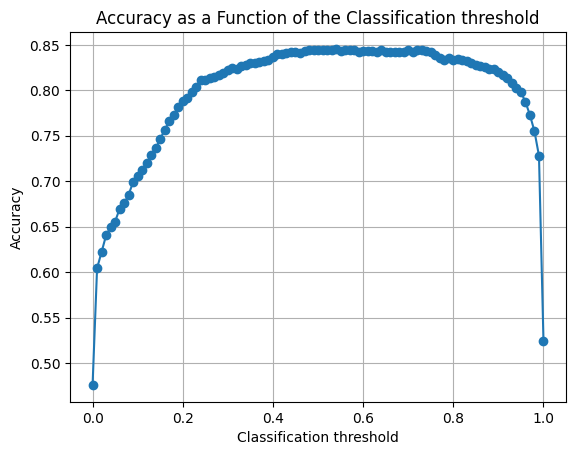

In [62]:
plt.figure()
plt.plot(thresholds, accs, marker='o', linestyle='-')
plt.xlabel("Classification threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy as a Function of the Classification threshold")
plt.grid(True)
plt.show()

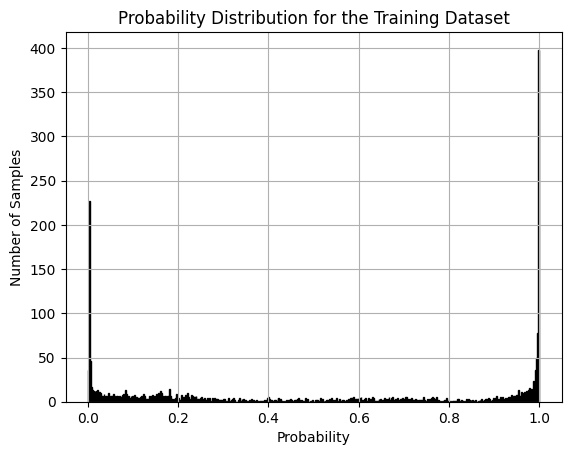

In [63]:
# Criar histograma das probabilidades
plt.hist(previsoes_otimization, bins=500, color='blue', edgecolor='black')

# Configurações do gráfico
plt.xlabel('Probability')
plt.ylabel('Number of Samples')
plt.title('Probability Distribution for the Training Dataset')
plt.grid(True)

# Exibir o gráfico
plt.show()

In [64]:
# Converter probabilidades em classes binárias (0 ou 1)
classes_preditas_otimization = (previsoes_otimization > 0.5).astype(int)

# Exibir as classes binárias
print("Classes previstas (binárias):", classes_preditas_otimization)
print()
print(classes_preditas_otimization.shape)

Classes previstas (binárias): [[0]
 [1]
 [1]
 ...
 [1]
 [0]
 [0]]

(2570, 1)


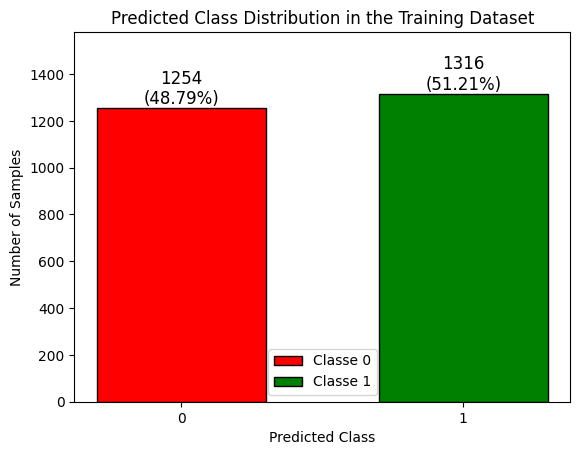

In [65]:
# Contar o número de 0s e 1s
num_zeros_otimization = np.sum(classes_preditas_otimization == 0)
num_uns_otimization = np.sum(classes_preditas_otimization == 1)

# Calcular as percentagens
percent_zero_otimization = (num_zeros_otimization / len(classes_preditas_otimization)) * 100
percent_one_otimization = (num_uns_otimization / len(classes_preditas_otimization)) * 100

# Criar histograma com cores específicas para cada classe
plt.bar([0], [num_zeros_otimization], color='red', edgecolor='black', width=0.6, label='Classe 0')
plt.bar([1], [num_uns_otimization], color='green', edgecolor='black', width=0.6, label='Classe 1')

# Adicionar contagem específica e percentagem a cada barra com uma margem acima para evitar sobreposição
plt.text(0, num_zeros_otimization + 0.1, f'{num_zeros_otimization}\n({percent_zero_otimization:.2f}%)', ha='center', va='bottom', fontsize=12)
plt.text(1, num_uns_otimization + 0.1, f'{num_uns_otimization}\n({percent_one_otimization:.2f}%)', ha='center', va='bottom', fontsize=12)

# Configurações do gráfico
plt.xticks([0, 1], ['0', '1'])
plt.xlabel('Predicted Class')
plt.ylabel('Number of Samples')
plt.title('Predicted Class Distribution in the Training Dataset')
plt.ylim(0, max(num_zeros_otimization, num_uns_otimization) * 1.2)  # Ajusta o limite superior do eixo Y para dar espaço para o texto
plt.legend()

# Exibir o gráfico
plt.show()

In [66]:
# Inicializar uma lista para armazenar o tensor
tensor_otimization = []

# Criar o tensor para os primeiros 2051 elementos
for i in range(X_otimization.shape[0]):
    tensor_otimization.append([selected_subsets_otimization[i], previsoes_otimization[i, 0]])

# Adicionar o último elemento de selected_subsets com 'none' para previsoes
tensor_otimization.append([selected_subsets_otimization[X_otimization.shape[0]], 'none'])

# Converter a lista para um array NumPy (dtype=object para lidar com tipos mistos)
tensor_otimization_np = np.array(tensor_otimization, dtype=object)

# Exibir o tensor final
print("Tensor final para otimização:")
print(tensor_otimization_np)
print(f"Shape do tensor de treino: {tensor_otimization_np.shape}")

Tensor final para otimização:
[[np.float64(167.22) np.float32(0.47213516)]
 [np.float64(166.62) np.float32(0.9665679)]
 [np.float64(167.43) np.float32(0.9994867)]
 ...
 [np.float64(252.34) np.float32(0.1615833)]
 [np.float64(252.04) np.float32(0.0044390177)]
 [np.float64(252.07) 'none']]
Shape do tensor de treino: (2571, 2)


#### **Otimization Delayed Dataset**

In [67]:
if not Paid_Sun_Tzu:
    processed_subsets_otimization_delayed = process_subsets(subsets_otimization, n_rows, granular_delay)

    dates_list_otimization_delayed = []  # Lista para armazenar as datas

    # Número total de subconjuntos
    num_subsets = len(processed_subsets_otimization_delayed)

    # Iterar sobre todos os subconjuntos, exceto o último
    for i in range(num_subsets - 1):
        subset_otimization_delayed = processed_subsets_otimization_delayed[i]
        # Garantir que o índice é do tipo datetime
        subset_otimization_delayed.index = pd.to_datetime(subset_otimization_delayed.index)
        # Extrair a data do primeiro 'open' e remover o horário
        first_date = subset_otimization_delayed.index[0].date()  # Apenas a data
        dates_list_otimization_delayed.append(first_date)

    # Para o último subconjunto, garantir que o índice é datetime e extrair a data
    last_subset_otimization_delayed = processed_subsets_otimization_delayed[-1]
    last_subset_otimization_delayed.index = pd.to_datetime(last_subset_otimization_delayed.index)
    last_date_otimization_delayed = last_subset_otimization_delayed.index[-1].date()  # Apenas a data
    dates_list_otimization_delayed.append(last_date_otimization_delayed)

    if otimization_method == "test_legacy":
        last_subsets_dates_otimization_delayed = dates_list_otimization_delayed[-(X_otimization.shape[0] + 1):]
    elif otimization_method == "training_validation":
        last_subsets_dates_otimization_delayed = dates_list_otimization_delayed[:(X_otimization.shape[0] + 1)]
    elif otimization_method == "training":
        last_subsets_dates_otimization_delayed = dates_list_otimization_delayed[:(X_otimization.shape[0] + 1)]
    elif otimization_method == "validation":
        last_subsets_dates_otimization_delayed = dates_list_otimization_delayed[(X_train.shape[0] + 1):(X_otimization.shape[0] + 1)]
    elif otimization_method == "sixty_forty" or otimization_method == "seventy_thirty" or otimization_method == "eighty_twenty" :
        otimization_slice = {
        "sixty_forty":   0.6,
        "seventy_thirty": 0.7
        }.get(otimization_method, 0.8)

        n = len(dates_list_otimization_delayed)

        # last XX%
        start_last = int(n * 0.8)
        dates_last = dates_list_otimization_delayed[start_last:]

        # first YY% of that XX%
        cut = int(len(dates_last) * otimization_slice) + 2
        last_subsets_dates_otimization_delayed   = dates_last[:cut]

    # Selecionar os primeiros "open" e o último "close"
    final_selection_otimization_delayed = select_open_close(processed_subsets_otimization_delayed)

    final_selection_otimization_delayed = np.array(final_selection_otimization_delayed)

    # Selecionar os últimos `X_test.shape[0] + 1` subconjuntos de final_selection
    if otimization_method == "test_legacy":
        selected_subsets_otimization_delayed = final_selection_otimization_delayed[-(X_otimization.shape[0] + 1):]
    elif otimization_method == "training_validation":
        selected_subsets_otimization_delayed = final_selection_otimization_delayed[:(X_otimization.shape[0] + 1)]
    elif otimization_method == "training":
        last_subsets_dates_otimization_delayed = dates_list_otimization_delayed[:(X_otimization.shape[0] + 1)]
    elif otimization_method == "validation":
        last_subsets_dates_otimization_delayed = dates_list_otimization_delayed[(X_train.shape[0] + 1):(X_otimization.shape[0] + 1)]
    elif otimization_method == "sixty_forty" or otimization_method == "seventy_thirty" or otimization_method == "eighty_twenty" :
        otimization_slice = {
        "sixty_forty":   0.6,
        "seventy_thirty": 0.7
        }.get(otimization_method, 0.8)

        n = len(final_selection_otimization_delayed)

        # last XX%
        start_last = int(n * 0.8)
        dates_last = final_selection_otimization_delayed[start_last:]

        # first YY% of that XX%
        cut = int(len(dates_last) * otimization_slice) + 2
        selected_subsets_otimization_delayed   = dates_last[:cut]

    # Converter para um array NumPy
    selected_subsets_otimization_delayed = np.array(selected_subsets_otimization_delayed)

    # Converter para um array NumPy
    selected_subsets_otimization_delayed = np.array(selected_subsets_otimization_delayed)

    # Inicializar uma lista para armazenar o tensor
    tensor_otimization_delayed = []

    # Criar o tensor para os primeiros 2051 elementos
    for i in range(X_otimization.shape[0]):
        tensor_otimization_delayed.append([selected_subsets_otimization_delayed[i], previsoes_otimization[i, 0]])

    # Adicionar o último elemento de selected_subsets com 'none' para previsoes
    tensor_otimization_delayed.append([selected_subsets_otimization_delayed[X_otimization.shape[0]], 'none'])

    # Converter a lista para um array NumPy (dtype=object para lidar com tipos mistos)
    tensor_otimization_delayed_np = np.array(tensor_otimization_delayed, dtype=object)

In [68]:
if not Paid_Sun_Tzu:
    # Determinar o número de pontos válidos
    num_points = min(len(selected_subsets_otimization_delayed), len(selected_subsets_otimization), len(matrices_y))

    # Criar os pontos do eixo x (índices de iteração)
    x_points = list(range(num_points))

    # Preparar listas para armazenar os valores de y e os pontos de cada cor
    all_y = []      # Para a linha cinzenta sequencial
    red_x, red_y = [], []    # Pontos onde matrices_y indica 0
    green_x, green_y = [], []  # Pontos onde matrices_y indica 1

    # Calcular os valores de y conforme a lógica definida:
    # Para i == 0, usamos matrices_y[0]; para os demais, usamos matrices_y[i-1]
    for i in range(num_points):
        matrix_value = matrices_y[0] if i == 0 else matrices_y[i-1]
        if matrix_value == 0:
            y_val = selected_subsets_otimization_delayed[i] - selected_subsets_otimization[i]
            red_x.append(i)
            red_y.append(y_val)
        else:
            y_val = selected_subsets_otimization[i] - selected_subsets_otimization_delayed[i]
            green_x.append(i)
            green_y.append(y_val)
        all_y.append(y_val)

    # Criar a figura interativa com Plotly
    fig = go.Figure()

    # Adicionar a linha cinzenta que conecta todos os pontos na ordem
    fig.add_trace(go.Scatter(
        x=x_points,
        y=all_y,
        mode='lines',
        line=dict(color='gray'),
        name='Sequential Line'
    ))

    # Adicionar os marcadores vermelhos (matrices_y == 0)
    fig.add_trace(go.Scatter(
        x=red_x,
        y=red_y,
        mode='markers',
        marker=dict(color='red', size=8),
        name='matrices_y == 0'
    ))

    # Adicionar os marcadores verdes (matrices_y == 1)
    fig.add_trace(go.Scatter(
        x=green_x,
        y=green_y,
        mode='markers',
        marker=dict(color='green', size=8),
        name='matrices_y == 1'
    ))

    # Configurar o layout do gráfico
    fig.update_layout(
      title='Interactive Graph: Calculated Difference per Iteration and Category',
      xaxis_title='Iteration (i)',
      yaxis_title='Calculated Difference',
      legend_title='Categories',
      template='plotly_white'
  )


    # Exibir o gráfico interativo
    fig.show()

In [69]:
if not Paid_Sun_Tzu:
    # Supondo que a lista all_y já esteja definida com os valores de y
    total_y = sum(all_y)
    print("Somatório dos valores de y:", round(total_y, 2))

In [70]:
if not Paid_Sun_Tzu:
    # Supondo que os seguintes arrays já estejam definidos:
    # red_x, red_y: pontos onde matrices_y indica 0 (vermelhos)
    # green_x, green_y: pontos onde matrices_y indica 1 (verdes)

    # Calcular a contagem absoluta de cada grupo
    red_count = len(red_x)
    green_count = len(green_x)
    total_count = red_count + green_count

    # Calcular os percentuais
    red_percent = red_count / total_count * 100
    green_percent = green_count / total_count * 100

    # Criar subplots: 1 linha e 2 colunas
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=("Count", "Percentage (%)"))

    # Gráfico 1: Contagem absoluta
    fig.add_trace(go.Bar(
        x=["Vermelho"],
        y=[red_count],
        text=[red_count],
        textposition='auto',
        marker_color='red',
        name="Red"
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=["Verde"],
        y=[green_count],
        text=[green_count],
        textposition='auto',
        marker_color='green',
        name="Green"
    ), row=1, col=1)

    # Gráfico 2: Percentuais
    fig.add_trace(go.Bar(
        x=["Vermelho"],
        y=[red_percent],
        text=[f"{red_percent:.1f}%"],
        textposition='auto',
        marker_color='red',
        name="Red"
    ), row=1, col=2)

    fig.add_trace(go.Bar(
        x=["Verde"],
        y=[green_percent],
        text=[f"{green_percent:.1f}%"],
        textposition='auto',
        marker_color='green',
        name="Green"
    ), row=1, col=2)

    # Atualizar o layout do gráfico
    fig.update_layout(
        title="Green vs Red Points",
        template='plotly_white',
        showlegend=False
    )

    # Atualizar os rótulos dos eixos
    fig.update_yaxes(title_text="Count", row=1, col=1)
    fig.update_yaxes(title_text="Percentage (%)", row=1, col=2)

    fig.show()

In [71]:
if not Paid_Sun_Tzu:
    # Supondo que as listas green_y e red_y já estejam definidas a partir dos cálculos anteriores

    # Criar subplots: 1 linha e 2 colunas
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["Green Points Distribution", "Red Points Distribution"]
    )

    # Histograma para os pontos verdes com aumento no número de bins
    fig.add_trace(go.Histogram(
        x=green_y,
        nbinsx=500,  # Define 50 bins para aumentar a granularidade do histograma
        name="Pontos Verdes",
        marker_color='green'
    ), row=1, col=1)

    # Histograma para os pontos vermelhos com aumento no número de bins
    fig.add_trace(go.Histogram(
        x=red_y,
        nbinsx=500,  # Define 50 bins para aumentar a granularidade do histograma
        name="Red Points",
        marker_color='red'
    ), row=1, col=2)

    # Atualizar o layout dos gráficos
    fig.update_layout(
        title="Red and Green Points Distribution Based on Gain/Loss Due to Delay",
        template='plotly_white',
        bargap=0.1
    )

    # Atualizar rótulos dos eixos
    fig.update_xaxes(title_text="Gain/Loss", row=1, col=1)
    fig.update_xaxes(title_text="Gain/Loss", row=1, col=2)
    fig.update_yaxes(title_text="Number of Points", row=1, col=1)
    fig.update_yaxes(title_text="Number of Points", row=1, col=2)

    fig.show()

In [72]:
if not Paid_Sun_Tzu:
    # Somatório dos valores y dos pontos vermelhos
    sum_red_y = sum(red_y)

    # Somatório dos valores y dos pontos verdes
    sum_green_y = sum(green_y)

    print("Somatório dos valores de y dos pontos vermelhos:", round(sum_red_y, 2))
    print("Somatório dos valores de y dos pontos verdes:", round(sum_green_y, 2))

In [73]:
if not Paid_Sun_Tzu:
    # cria figura vazia
    fig = go.Figure()

    # histograma dos pontos verdes
    fig.add_trace(go.Histogram(
        x=green_y,
        nbinsx=500,
        name="Green Points",
        marker_color='green',
        opacity=0.6        # torna semi-transparente para vermos sobreposições
    ))

    # histograma dos pontos vermelhos
    fig.add_trace(go.Histogram(
        x=red_y,
        nbinsx=500,
        name="Red Points",
        marker_color='red',
        opacity=0.6
    ))

    # layout
    fig.update_layout(
        title="Red and Green Points Distribution Based on Gain/Loss Due to Delay",
        template='plotly_white',
        bargap=0.1,         # espaço entre barras de classes diferentes
        barmode='overlay',  # sobrepõe em vez de side-by-side
    )

    # rótulos
    fig.update_xaxes(title_text="Gain/Loss")
    fig.update_yaxes(title_text="Number of Points")

    fig.show()

In [74]:
if not Paid_Sun_Tzu:
    # combina os dois vetores
    combined_y = list(green_y) + list(red_y)

    # cria figura
    fig2 = go.Figure()

    # histograma do conjunto combinado, em preto
    fig2.add_trace(go.Histogram(
        x=combined_y,
        nbinsx=1000,
        name="Total Points",
        marker_color='black',
        opacity=1.0
    ))

    # layout
    fig2.update_layout(
        title="Combined Distribution of Red and Green Point Based on Gain/Loss Due to Delay",
        template='plotly_white',
        bargap=0.1,
    )

    # eixos
    fig2.update_xaxes(title_text="Gain/Loss")
    fig2.update_yaxes(title_text="Number of Points")

    fig2.show()

## **Test Dataset**

#### **Test Dataset Not Delayed**

In [75]:
# Usar a função para dividir `needed_company_data`
subsets_test = split_dataframe(needed_company_data, n_rows)

# Exibir informações sobre os subconjuntos
#for i, subset in enumerate(subsets):
    #print(f"Subset {i+1}:")
    #print(subset)
    #print(f"Shape: {subset.shape}")
    #print()

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [76]:
# Processar cada subconjunto para manter apenas o primeiro 'open' e o último 'close'
processed_subsets_test = process_subsets(subsets_test, n_rows)

# Exibir informações sobre os subconjuntos processados
#for i, subset in enumerate(processed_subsets):
    #print(f"Processed Subset {i+1}:")
    #print(subset)
    #print(f"Shape: {subset.shape}")
    #print()

In [77]:
dates_list_test = []  # Lista para armazenar as datas

# Número total de subconjuntos
num_subsets_test = len(processed_subsets_test)

# Iterar sobre todos os subconjuntos, exceto o último
for i in range(num_subsets_test - 1):
    subset_test = processed_subsets_test[i]
    # Garantir que o índice é do tipo datetime
    subset_test.index = pd.to_datetime(subset_test.index)
    # Extrair a data do primeiro 'open' e remover o horário
    first_date_test = subset_test.index[0].date()  # Apenas a data
    dates_list_test.append(first_date_test)

# Para o último subconjunto, garantir que o índice é datetime e extrair a data
last_subset_test = processed_subsets_test[-1]
last_subset_test.index = pd.to_datetime(last_subset_test.index)
last_date_test = last_subset_test.index[-1].date()  # Apenas a data
dates_list_test.append(last_date_test)

# Exibir as datas extraídas
#print("Datas extraídas:")
#for i, date in enumerate(dates_list):
    #print(f"Subset {i+1}: {date}")

/tmp/ipython-input-2496806510.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset_test.index = pd.to_datetime(subset_test.index)
/tmp/ipython-input-2496806510.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset_test.index = pd.to_datetime(subset_test.index)
/tmp/ipython-input-2496806510.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset_test.index = pd.to_datetime(subset_test.index)
/tmp/ipython-input-2496806510.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is c

In [78]:
# Extrair os últimos "X_test + 1" subconjuntos da lista dates_list
last_subsets_dates_test = dates_list_test[-(X_test.shape[0] + 1):]

# Exibir os subconjuntos extraídos
#print("Últimos subconjuntos extraídos:")
#for i, date in enumerate(last_subsets_dates):
    #print(f"Subset {i+1}: {date}")

In [79]:
# Selecionar os primeiros "open" e o último "close"
final_selection_test = select_open_close(processed_subsets_test)

# Exibir o resultado
#print("Primeiro 'open' de cada subconjunto (exceto o último) e último 'close' do último subconjunto:")
#for i, value in enumerate(final_selection):
    #print(f"Subset {i+1}: {value}")

final_selection_test = np.array(final_selection_test)
print(final_selection_test.shape)

(12844,)


Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta parte do codigo acaba o processamento dos  dados e converte os arrais necessários para vetores numpy para mais facilmente serem manipulados.

In [80]:
# Selecionar os últimos `X_test.shape[0] + 1` subconjuntos de final_selection
num_to_select = X_test.shape[0] + 1  # Quantidade de subconjuntos a selecionar
selected_subsets_test = final_selection_test[-num_to_select:]  # Selecionar os últimos 'num_to_select' subconjuntos

# Exibir o resultado
#print(f"Últimos {num_to_select} subconjuntos de final_selection:")
#for i, value in enumerate(selected_subsets, 1):
    #print(f"Subset {i}: {value}")

# Converter para um array NumPy
selected_subsets_test = np.array(selected_subsets_test)
print(selected_subsets_test.shape)

(2571,)


O modelo realiza previsões ao longo de todo o dataset de teste.

As previsões são binárias. A matriz tem label 1 se na matriz seguinte o preço do ativo subiu e a matriz tem label 0 se na matriz seguinte o preço do arivo se manteve constante ou desceu. Em classificações binárias o modelo apenas devolve um número entre 0 e 1, que representa a probabilidade da dabele do dataset de teste ser 1, por default normalemnte qualuqer previsão menor a 0.5 é considerada 0 e qualquer acima de 0.5 é considerada 1. No entanto para estudar a otimização de estrtégias de deployment do modelo no mercado este valore será otimizado e não escolhido arbitráriamente como o 0.5.

Também é obtida o número de previsões feitas.

In [81]:
# Fazer previsões com o modelo
previsoes_test = model.predict(X_test)

# Exibir as previsões e as classes binárias
print()
print("Previsões como probabilidades:", previsoes_test)
print()
print(previsoes_test.shape)

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Previsões como probabilidades: [[0.47213516]
 [0.9665679 ]
 [0.9994867 ]
 ...
 [0.99921286]
 [0.1615833 ]
 [0.00443902]]

(2570, 1)


In [82]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8447 - loss: 0.3941
Loss: 0.4137
Accuracy: 0.8440


In [83]:
# --- 2) Obter probabilidades preditas pelo modelo ---
y_prob = previsoes_test.ravel()  # achata para vetor unidimensional

# --- 3) Definir grade de limiares e buscar o melhor ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
best_thr = 0.5
best_acc = 0.0
accs = []  # para guardar todas as acurácias

for thr in thresholds:
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_test, y_pred)
    accs.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_thr = thr

print(f"Melhor limiar = {best_thr:.2f} → acurácia = {best_acc:.4f}")

Melhor limiar = 0.54 → acurácia = 0.8455


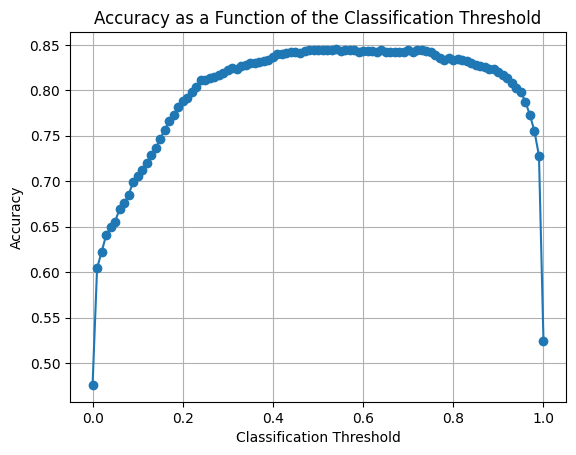

In [84]:
plt.figure()
plt.plot(thresholds, accs, marker='o', linestyle='-')
plt.xlabel("Classification Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy as a Function of the Classification Threshold")
plt.grid(True)
plt.show()

Plot do número de previsões em função da probabilidade prevista.

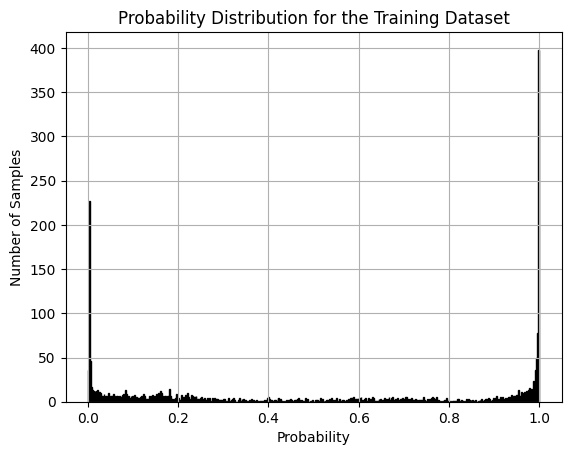

In [85]:
# Criar histograma das probabilidades
plt.hist(previsoes_test, bins=500, color='blue', edgecolor='black')

# Configurações do gráfico
plt.xlabel('Probability')
plt.ylabel('Number of Samples')
plt.title('Probability Distribution for the Training Dataset')
plt.grid(True)

# Exibir o gráfico
plt.show()

Usando o valor default de 0.5 traformar o vetor de previsões probabilisticas do modelo num vetor de labels. tudo acima de 0.5 vira 1 e tudo o resto vira 0.

In [86]:
# Converter probabilidades em classes binárias (0 ou 1)
classes_preditas_test = (previsoes_test > 0.5).astype(int)

# Exibir as classes binárias
print("Classes previstas (binárias):", classes_preditas_test)
print()
print(classes_preditas_test.shape)

Classes previstas (binárias): [[0]
 [1]
 [1]
 ...
 [1]
 [0]
 [0]]

(2570, 1)


plot do número e percentagem de previsões positivas e negativas (0 e 1).

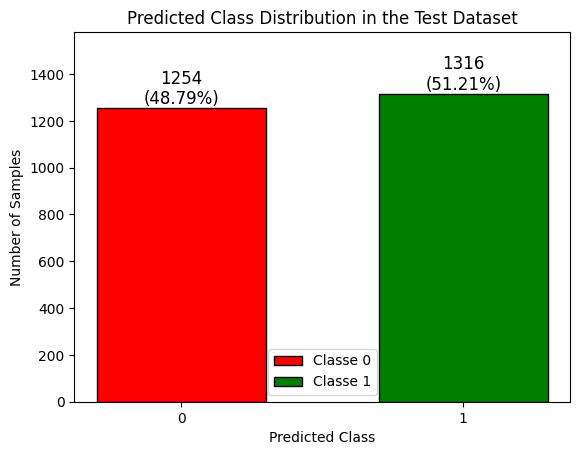

In [87]:
# Contar o número de 0s e 1s
num_zeros_test = np.sum(classes_preditas_test == 0)
num_uns_test = np.sum(classes_preditas_test == 1)

# Calcular as percentagens
percent_zero_test = (num_zeros_test / len(classes_preditas_test)) * 100
percent_one_test = (num_uns_test / len(classes_preditas_test)) * 100

# Criar histograma com cores específicas para cada classe
plt.bar([0], [num_zeros_test], color='red', edgecolor='black', width=0.6, label='Classe 0')
plt.bar([1], [num_uns_test], color='green', edgecolor='black', width=0.6, label='Classe 1')

# Adicionar contagem específica e percentagem a cada barra com uma margem acima para evitar sobreposição
plt.text(0, num_zeros_test + 0.1, f'{num_zeros_test}\n({percent_zero_test:.2f}%)', ha='center', va='bottom', fontsize=12)
plt.text(1, num_uns_test + 0.1, f'{num_uns_test}\n({percent_one_test:.2f}%)', ha='center', va='bottom', fontsize=12)

# Configurações do gráfico
plt.xticks([0, 1], ['0', '1'])
plt.xlabel('Predicted Class')
plt.ylabel('Number of Samples')
plt.title('Predicted Class Distribution in the Test Dataset')
plt.ylim(0, max(num_zeros_test, num_uns_test) * 1.2)  # Ajusta o limite superior do eixo Y para dar espaço para o texto
plt.legend()

# Exibir o gráfico
plt.show()

Criar um tensor com as previões percentuais do modelo e a cada respetiva previsão o preço do atrivo em que o modelo estaria a atuar (open do espaço temporal seguinte). A ultima previsão obviamente não terá nehum preço associado pois nessa altura o trading da estrtégia já terá fechado, pois chegou ao fim dos do dataset.

In [88]:
# Inicializar uma lista para armazenar o tensor
tensor_test = []

# Criar o tensor para os primeiros 2051 elementos
for i in range(X_test.shape[0]):
    tensor_test.append([selected_subsets_test[i], previsoes_test[i, 0]])

# Adicionar o último elemento de selected_subsets com 'none' para previsoes
tensor_test.append([selected_subsets_test[X_test.shape[0]], 'none'])

# Converter a lista para um array NumPy (dtype=object para lidar com tipos mistos)
tensor_test_np = np.array(tensor_test, dtype=object)

# Exibir o tensor final
print("Tensor final de teste:")
print(tensor_test_np)
print(f"Shape do tensor de teste: {tensor_test_np.shape}")

Tensor final de teste:
[[np.float64(167.22) np.float32(0.47213516)]
 [np.float64(166.62) np.float32(0.9665679)]
 [np.float64(167.43) np.float32(0.9994867)]
 ...
 [np.float64(252.34) np.float32(0.1615833)]
 [np.float64(252.04) np.float32(0.0044390177)]
 [np.float64(252.07) 'none']]
Shape do tensor de teste: (2571, 2)


#### **Test Delayed Dataset**

In [89]:
if not Paid_Sun_Tzu:
    processed_subsets_test_delayed = process_subsets(subsets_test, n_rows, granular_delay)

    dates_list_test_delayed = []  # Lista para armazenar as datas

    # Número total de subconjuntos
    num_subsets = len(processed_subsets_test_delayed)

    # Iterar sobre todos os subconjuntos, exceto o último
    for i in range(num_subsets - 1):
        subset_test_delayed = processed_subsets_test_delayed[i]
        # Garantir que o índice é do tipo datetime
        subset_test_delayed.index = pd.to_datetime(subset_test_delayed.index)
        # Extrair a data do primeiro 'open' e remover o horário
        first_date_test_delayed = subset_test_delayed.index[0].date()  # Apenas a data
        dates_list_test_delayed.append(first_date_test_delayed)

    # Para o último subconjunto, garantir que o índice é datetime e extrair a data
    last_subset_test_delayed = processed_subsets_test_delayed[-1]
    last_subset_test_delayed.index = pd.to_datetime(last_subset_test_delayed.index)
    last_date_test_delayed = last_subset_test_delayed.index[-1].date()  # Apenas a data
    dates_list_test_delayed.append(last_date_test_delayed)

    last_subsets_dates_test_delayed = dates_list_test_delayed[-(X_test.shape[0] + 1):]

    # Selecionar os primeiros "open" e o último "close"
    final_selection_test_delayed = select_open_close(processed_subsets_test_delayed)

    final_selection_test_delayed = np.array(final_selection_test_delayed)

    # Selecionar os últimos `X_test.shape[0] + 1` subconjuntos de final_selection
    num_to_select = X_test.shape[0] + 1  # Quantidade de subconjuntos a selecionar
    selected_subsets_test_delayed = final_selection_test_delayed[-num_to_select:]  # Selecionar os últimos 'num_to_select' subconjuntos

    # Converter para um array NumPy
    selected_subsets_test_delayed = np.array(selected_subsets_test_delayed)

    # Inicializar uma lista para armazenar o tensor
    tensor_test_delayed = []

    # Criar o tensor para os primeiros 2051 elementos
    for i in range(X_test.shape[0]):
        tensor_test_delayed.append([selected_subsets_test_delayed[i], previsoes_test[i, 0]])

    # Adicionar o último elemento de selected_subsets com 'none' para previsoes
    tensor_test_delayed.append([selected_subsets_test_delayed[X_test.shape[0]], 'none'])

    # Converter a lista para um array NumPy (dtype=object para lidar com tipos mistos)
    tensor_test_delayed_np = np.array(tensor_test_delayed, dtype=object)

In [90]:
if not Paid_Sun_Tzu:
    # Determinar o número de pontos válidos
    num_points = min(len(selected_subsets_test_delayed), len(selected_subsets_test), len(matrices_y))

    # Criar os pontos do eixo x (índices de iteração)
    x_points = list(range(num_points))

    # Preparar listas para armazenar os valores de y e os pontos de cada cor
    all_y = []      # Para a linha cinzenta sequencial
    red_x, red_y = [], []    # Pontos onde matrices_y indica 0
    green_x, green_y = [], []  # Pontos onde matrices_y indica 1

    # Calcular os valores de y conforme a lógica definida:
    # Para i == 0, usamos matrices_y[0]; para os demais, usamos matrices_y[i-1]
    for i in range(num_points):
        matrix_value = matrices_y[0] if i == 0 else matrices_y[i-1]
        if matrix_value == 0:
            y_val = selected_subsets_test_delayed[i] - selected_subsets_test[i]
            red_x.append(i)
            red_y.append(y_val)
        else:
            y_val = selected_subsets_test[i] - selected_subsets_test_delayed[i]
            green_x.append(i)
            green_y.append(y_val)
        all_y.append(y_val)

    # Criar a figura interativa com Plotly
    fig = go.Figure()

    # Adicionar a linha cinzenta que conecta todos os pontos na ordem
    fig.add_trace(go.Scatter(
        x=x_points,
        y=all_y,
        mode='lines',
        line=dict(color='gray'),
        name='Sequential Line'
    ))

    # Adicionar os marcadores vermelhos (matrices_y == 0)
    fig.add_trace(go.Scatter(
        x=red_x,
        y=red_y,
        mode='markers',
        marker=dict(color='red', size=8),
        name='matrices_y == 0'
    ))

    # Adicionar os marcadores verdes (matrices_y == 1)
    fig.add_trace(go.Scatter(
        x=green_x,
        y=green_y,
        mode='markers',
        marker=dict(color='green', size=8),
        name='matrices_y == 1'
    ))

    # Configurar o layout do gráfico
    fig.update_layout(
        title='Interactive Graph: Calculated Difference per Iteration and Category',
        xaxis_title='Iteration (i)',
        yaxis_title='Calculated Difference',
        legend_title='Categories',
        template='plotly_white'
    )

    # Exibir o gráfico interativo
    fig.show()

In [91]:
if not Paid_Sun_Tzu:
    # Supondo que a lista all_y já esteja definida com os valores de y
    total_y = sum(all_y)
    print("Somatório dos valores de y:", round(total_y, 2))

In [92]:
if not Paid_Sun_Tzu:
    # Supondo que os seguintes arrays já estejam definidos:
    # red_x, red_y: pontos onde matrices_y indica 0 (vermelhos)
    # green_x, green_y: pontos onde matrices_y indica 1 (verdes)

    # Calcular a contagem absoluta de cada grupo
    red_count = len(red_x)
    green_count = len(green_x)
    total_count = red_count + green_count

    # Calcular os percentuais
    red_percent = red_count / total_count * 100
    green_percent = green_count / total_count * 100

    # Criar subplots: 1 linha e 2 colunas
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=("Count", "Percentage (%)"))

    # Gráfico 1: Contagem absoluta
    fig.add_trace(go.Bar(
        x=["Vermelho"],
        y=[red_count],
        text=[red_count],
        textposition='auto',
        marker_color='red',
        name="Red"
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=["Verde"],
        y=[green_count],
        text=[green_count],
        textposition='auto',
        marker_color='green',
        name="Green"
    ), row=1, col=1)

    # Gráfico 2: Percentuais
    fig.add_trace(go.Bar(
        x=["Vermelho"],
        y=[red_percent],
        text=[f"{red_percent:.1f}%"],
        textposition='auto',
        marker_color='red',
        name="Red"
    ), row=1, col=2)

    fig.add_trace(go.Bar(
        x=["Verde"],
        y=[green_percent],
        text=[f"{green_percent:.1f}%"],
        textposition='auto',
        marker_color='green',
        name="Green"
    ), row=1, col=2)

    # Atualizar o layout do gráfico
    fig.update_layout(
        title="Green vs Red Points",
        template='plotly_white',
        showlegend=False
    )

    # Atualizar os rótulos dos eixos
    fig.update_yaxes(title_text="Count", row=1, col=1)
    fig.update_yaxes(title_text="Percentage(%)", row=1, col=2)

    fig.show()

In [93]:
if not Paid_Sun_Tzu:
    # Supondo que as listas green_y e red_y já estejam definidas a partir dos cálculos anteriores

    # Criar subplots: 1 linha e 2 colunas
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["Green Points Distribution", "Red Points Distribution"]
    )

    # Histograma para os pontos verdes com aumento no número de bins
    fig.add_trace(go.Histogram(
        x=green_y,
        nbinsx=500,  # Define 50 bins para aumentar a granularidade do histograma
        name="Green Points",
        marker_color='green'
    ), row=1, col=1)

    # Histograma para os pontos vermelhos com aumento no número de bins
    fig.add_trace(go.Histogram(
        x=red_y,
        nbinsx=500,  # Define 50 bins para aumentar a granularidade do histograma
        name="Red Points",
        marker_color='red'
    ), row=1, col=2)

    # Atualizar o layout dos gráficos
    fig.update_layout(
        title="Red and Green Points Distribution Based on Gain/Loss Due to Delay",
        template='plotly_white',
        bargap=0.1
    )

    # Atualizar rótulos dos eixos
    fig.update_xaxes(title_text="Gain/Loss", row=1, col=1)
    fig.update_xaxes(title_text="Gain/Loss", row=1, col=2)
    fig.update_yaxes(title_text="Number of Points", row=1, col=1)
    fig.update_yaxes(title_text="Number of Points", row=1, col=2)

    fig.show()

In [94]:
if not Paid_Sun_Tzu:
    # Somatório dos valores y dos pontos vermelhos
    sum_red_y = sum(red_y)

    # Somatório dos valores y dos pontos verdes
    sum_green_y = sum(green_y)

    print("Somatório dos valores de y dos pontos vermelhos:", round(sum_red_y, 2))
    print("Somatório dos valores de y dos pontos verdes:", round(sum_green_y, 2))

# **Buy and Hold Classic**

### **Otimization Dataset**

In [95]:
# Inicializar variáveis para a evolução natural do mercado
initial_fund_natural_otimization = 100000  # Fundo inicial de $100,000
natural_fund_otimization = initial_fund_natural_otimization
Total_Slippage = 0

# Comprar ações no segundo índice do tensor (primeira operação de compra)
initial_price_natural_otimization = float(tensor_otimization_np[1][0])  # Preço da ação no segundo índice
exec_px = exec_price_with_slippage("buy", initial_price_natural_otimization, symbol)
num_shares_natural_otimization = natural_fund_otimization / exec_px # Quantidade de ações compradas (fracionárias)
Slippage_Cost = num_shares_natural_otimization * (exec_px - initial_price_natural_otimization)
Total_Slippage += Slippage_Cost
natural_fund_otimization -= num_shares_natural_otimization * exec_px  # Atualiza o fundo após compra

print(f"Comprado {num_shares_natural_otimization:.6f} ações a {exec_px:.2f} cada (preço original: {initial_price_natural_otimization:.2f}), fundo restante: ${natural_fund_otimization:.2f}. Slippage custou: ${Slippage_Cost:.2f}.")

# No final do tensor, vender todas as ações restantes
final_price_natural_otimization = float(tensor_otimization_np[-1][0])  # Preço final para venda
exec_px = exec_price_with_slippage("sell", final_price_natural_otimization, symbol)
SEC_fees_otimization = calculate_fee('sell', num_shares_natural_otimization * exec_px)
Slippage_Cost = num_shares_natural_otimization * (final_price_natural_otimization - exec_px)
Total_Slippage += Slippage_Cost
natural_fund_otimization += num_shares_natural_otimization * exec_px - SEC_fees_otimization # Vende todas as ações restantes

print(f"Vendido {num_shares_natural_otimization:.6f} ações a {exec_px:.2f} cada (preço original: {final_price_natural_otimization:.2f}) no final, pago ${SEC_fees_otimization:.2f} em taxas do SEC. Slippage custou: ${Slippage_Cost:.2f}. Fundo total final: ${natural_fund_otimization:.2f}")

# Calcular o percentual de crescimento
initial_investment_otimization = initial_fund_natural_otimization
final_value_otimization = natural_fund_otimization
percentage_increase_otimization = ((final_value_otimization - initial_investment_otimization) / initial_investment_otimization) * 100

print(f"\nTotal gasto em slippage: ${Total_Slippage:.2f}")

print(f"\nTotal gasto em taxas do SEC: ${SEC_fees_otimization:.2f}")

print(f"\nPercentual de crescimento do fundo com a estratégia natural: {percentage_increase_otimization:.3f}%")

Comprado 599.988051 ações a 166.67 cada (preço original: 166.62), fundo restante: $0.00. Slippage custou: $29.99.
Vendido 599.988051 ações a 251.99 cada (preço original: 252.07) no final, pago $4.20 em taxas do SEC. Slippage custou: $45.37. Fundo total final: $151189.41

Total gasto em slippage: $75.36

Total gasto em taxas do SEC: $4.20

Percentual de crescimento do fundo com a estratégia natural: 51.189%


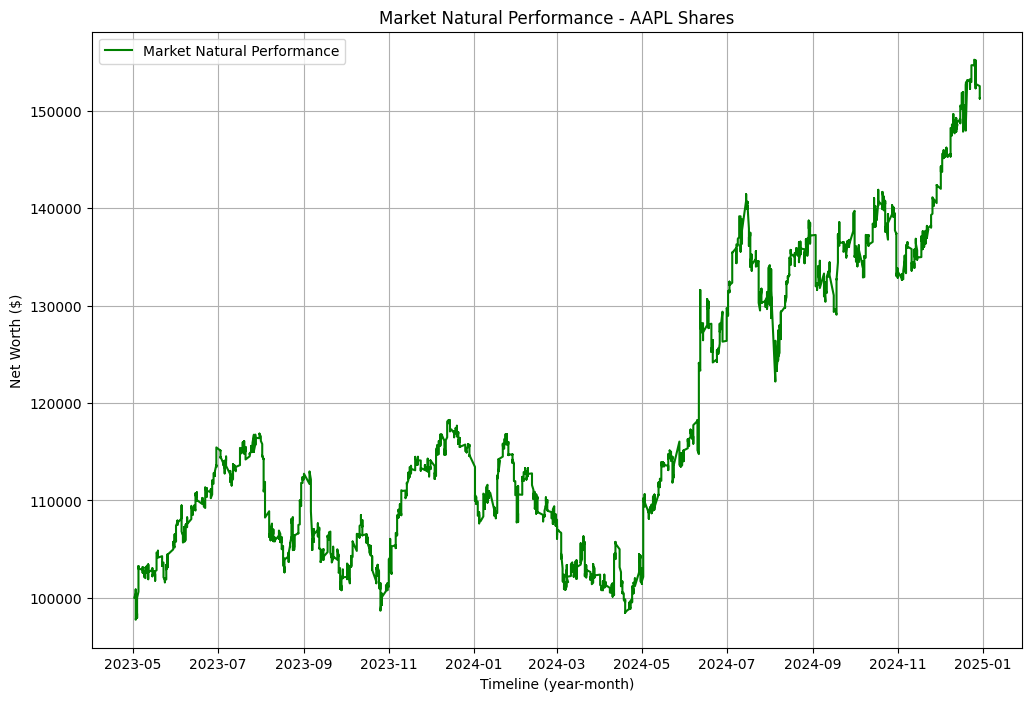

In [96]:
# Criar uma lista para armazenar a evolução do valor do fundo para a evolução natural do mercado
natural_fund_values_otimization = []

# Inicializar variáveis para a evolução natural do mercado
initial_fund_otimization = 100000  # Fundo inicial de $100,000
initial_price_natural_otimization = float(tensor_otimization_np[1][0])  # Preço da ação no segundo índice do tensor
num_shares_natural_otimization = initial_fund_otimization / initial_price_natural_otimization  # Ações fracionárias compradas
current_fund_natural_otimization = initial_fund_otimization - num_shares_natural_otimization * initial_price_natural_otimization

# A primeira posição do fundo natural é logo após a compra inicial
natural_fund_values_otimization.append(current_fund_natural_otimization + num_shares_natural_otimization * initial_price_natural_otimization)

# Simular a evolução natural do mercado
for i in range(1, len(tensor_otimization_np)):
    price_otimization = float(tensor_otimization_np[i][0])

    if i < len(tensor_otimization_np) - 1:
        # Atualizar a evolução natural do mercado ao longo do tempo
        natural_fund_values_otimization.append(current_fund_natural_otimization + num_shares_natural_otimization * price_otimization)

# Registrar o valor final para a evolução natural
final_price_natural_otimization = float(tensor_otimization_np[-1][0])
natural_fund_values_otimization.append(current_fund_natural_otimization + num_shares_natural_otimization * final_price_natural_otimization)

# Gerar o gráfico da evolução do fundo
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_otimization, natural_fund_values_otimization, label='Market Natural Performance', color='green')

plt.title('Market Natural Performance - ' + symbol + ' Shares')
plt.xlabel('Timeline (year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

In [97]:
if not Paid_Sun_Tzu:
    last_subsets_dates_otimization = last_subsets_dates_otimization_delayed
    tensor_otimization_np = tensor_otimization_delayed_np

### **Test Dataset**

Evolução natural de uma carteira sem estratégia (evolução do mercado).

Este código simula o que é que aconteceria se fosse gasto todo o dinheiro do portefólio em ações e no final do periodo temporal do dataset de teste vendidas todas as ações compradas no inicio. Estrtégia natural = holding basico.

In [98]:
# Inicializar variáveis para a evolução natural do mercado
initial_fund_natural_test = 100000  # Fundo inicial de $100,000
natural_fund_test = initial_fund_natural_test
Total_Slippage = 0

# Comprar ações no segundo índice do tensor (primeira operação de compra)
initial_price_natural_test = float(tensor_test_np[1][0])  # Preço da ação no segundo índice
exec_px = exec_price_with_slippage("buy", initial_price_natural_test, symbol)
num_shares_natural_test = natural_fund_test / exec_px  # Quantidade de ações compradas (fracionárias)
Slippage_Cost = num_shares_natural_test * (exec_px - initial_price_natural_test)
Total_Slippage += Slippage_Cost
natural_fund_test -= num_shares_natural_test * exec_px  # Atualiza o fundo após compra

print(f"Comprado {num_shares_natural_test:.6f} ações a {exec_px} cada (preço original: {initial_price_natural_otimization:.2f}), fundo restante: ${natural_fund_test:.2f}. Slippage custou: ${Slippage_Cost:.2f}.")

# No final do tensor, vender todas as ações restantes
final_price_natural_test = float(tensor_test_np[-1][0])  # Preço final para venda
exec_px = exec_price_with_slippage("sell", final_price_natural_test, symbol)
SEC_fees_test = calculate_fee('sell', num_shares_natural_test * exec_px)
Slippage_Cost = num_shares_natural_test * (final_price_natural_test - exec_px)
Total_Slippage += Slippage_Cost
natural_fund_test += num_shares_natural_test * exec_px - SEC_fees_test # Vende todas as ações restantes

print(f"Vendido {num_shares_natural_test:.6f} ações a {exec_px} cada (preço original: {final_price_natural_test:.2f}) no final, pago ${SEC_fees_test:.2f} em taxas. Slippage custou: ${Slippage_Cost:.2f}. Fundo total final: ${natural_fund_test:.2f}")

# Calcular o percentual de crescimento
initial_investment_test = initial_fund_natural_test
final_value_test = natural_fund_test
percentage_increase_test = ((final_value_test - initial_investment_test) / initial_investment_test) * 100

print(f"\nTotal gasto em slippage: ${Total_Slippage:.2f}")

print(f"\nTotal gasto em taxas do SEC: ${SEC_fees_test:.2f}")

print(f"\nPercentual de crescimento do fundo com a estratégia natural: {percentage_increase_test:.3f}%")

Comprado 599.988051 ações a 166.669986 cada (preço original: 166.62), fundo restante: $0.00. Slippage custou: $29.99.
Vendido 599.988051 ações a 251.994379 cada (preço original: 252.07) no final, pago $4.20 em taxas. Slippage custou: $45.37. Fundo total final: $151189.41

Total gasto em slippage: $75.36

Total gasto em taxas do SEC: $4.20

Percentual de crescimento do fundo com a estratégia natural: 51.189%


Este código permite dar plot ao que está a acontecer no mercado, que para o caso desta estratégia é o mesmo que está a acontecer á networth do nosso portafólio durante o período temporal do dataset de teste. Usando os closes como indicadores de preço do ativo em função do tempo. Calro que com uma maior ganularidade e se também se tivesse em conta o open a resolução do gráfico seria maior, mas a resolução do gráfico de nada afeta o estudo da estratégia e a sua veracidade, portanto não foi tido em conta, pois esses dados também nesta etapa já não se encontram disponíveis pois forma tratados. Para além disso se este problema da resolução do gráfico apenas é verdade se se encarar o gráfico como uma representação do mercad, no entanto se se encarar o gráfico como a networth ao longo do tempo do portefólio sobre esta estretégia o gráfico esté perfeito e a resolução maximizada.

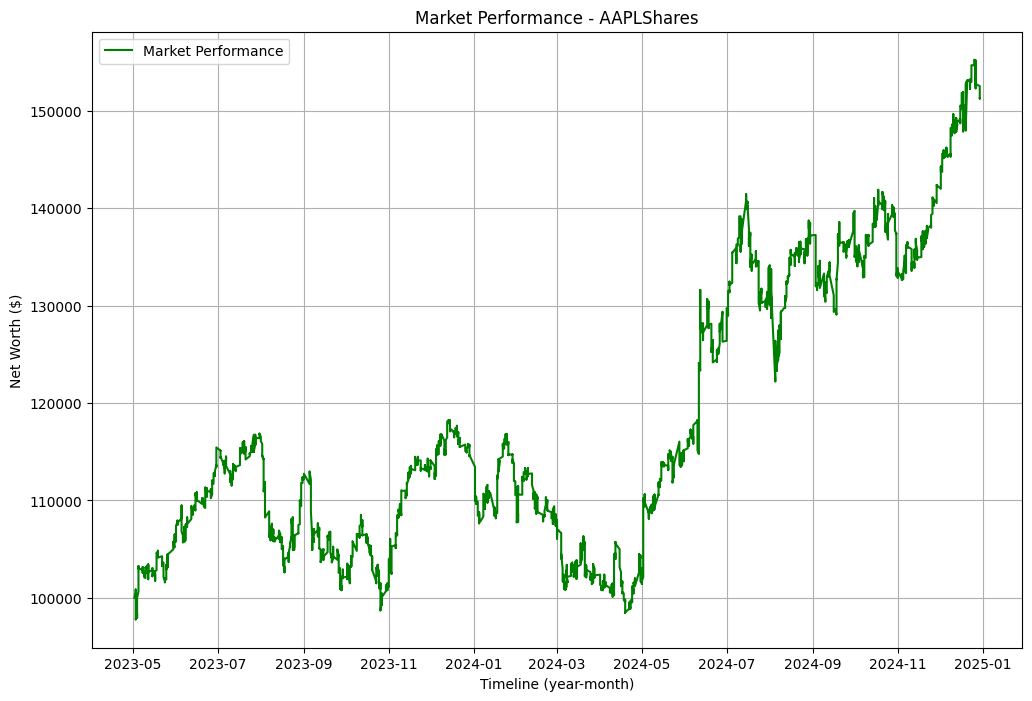

In [99]:
# Criar uma lista para armazenar a evolução do valor do fundo para a evolução natural do mercado
natural_fund_values_test = []

# Inicializar variáveis para a evolução natural do mercado
initial_fund_test = 100000  # Fundo inicial de $100,000
initial_price_natural_test = float(tensor_test_np[1][0])  # Preço da ação no segundo índice do tensor
num_shares_natural_test = initial_fund_test / initial_price_natural_test  # Ações fracionárias compradas
current_fund_natural_test = initial_fund_test - num_shares_natural_test * initial_price_natural_test

# A primeira posição do fundo natural é logo após a compra inicial
natural_fund_values_test.append(current_fund_natural_test + num_shares_natural_test * initial_price_natural_test)

# Simular a evolução natural do mercado
for i in range(1, len(tensor_test_np)):
    price_test = float(tensor_test_np[i][0])

    if i < len(tensor_test_np) - 1:
        # Atualizar a evolução natural do mercado ao longo do tempo
        natural_fund_values_test.append(current_fund_natural_test + num_shares_natural_test * price_test)

# Registrar o valor final para a evolução natural
final_price_natural_test = float(tensor_test_np[-1][0])
natural_fund_values_test.append(current_fund_natural_test + num_shares_natural_test * final_price_natural_test)

# Gerar o gráfico da evolução do fundo
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, natural_fund_values_test, label='Market Performance', color='green')

plt.title('Market Performance - ' + symbol + 'Shares')
plt.xlabel('Timeline (year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

In [100]:
if not Paid_Sun_Tzu:
    last_subsets_dates_test = last_subsets_dates_test_delayed
    tensor_test_np = tensor_test_delayed_np

# **Estratégias de Gestão do Portefólio de Investimentos Sem Short-Selling**

Aqui seram estudadas todas as possíveis estratégias de gestão de portefólio com o modelo sem usar short-selling. Para estudar as seguintes estratégias será criado um portefólio virtual com 100 000$ que será gerido usando o modelo para prever o mercado e a respetiva estratégia de gestão de portefólio que estará a ser estudada. Isto permite simular o mais aproximado ppossível a gestão real de um portefólio com o modelo desenvolvido no alpaca e a estratégia escolhida e desenvolvida pelo SunTzu.

É imporante destacar que a networth de um portefólio é dado pela seguinte função:

Networth(localização temporal; modelo; estratégia; ativo; valor inicial = 100 000$$) = Valor_do_ativo(localização temporal; ativo) + Valor_Liquido_Guardado(localização temporal; modelo; estratégia; valor inicial = 100 000$)

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

Sensibilidade Decisiva trata-se do valor decimal que estipula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

Iniciar os arrays de resultados para guardar os resultados das estretégias estudadas.

In [101]:
Results_Mean_array = []
Results_Last_array = []
Results_Mean_array_test = []

Results_Mean_array.extend([None] * (2))
Results_Last_array.extend([None] * (2))
Results_Mean_array_test.extend([None] * (2))

## **Absolute Buy and Sell**

Comprar em absoluto, ou seja, gastar todo o dinheiro da carteira ao primeiro sinal positivo "1". Buy and Hold, ou seja, manter todo o dinheiro nas ações uma vez executada a compra. Vender em absoluto, ou seja, vender todo o dinheiro das ações ao primeiro sinal negativo "0". Repetir infinitamente o processo.

### **Otimization**



**Estudo da Melhor Sensibilidade Decisiva:**

Sensibilidade Decisiva trata-se do valor decimal que estibula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

In [102]:
# Arrays para armazenar as diferenças percentuais e as médias de diferença percentual
percentages_diference_array_otimization = []
media_diff_percentual_array_otimization = []

# Lista para armazenar os resultados de cada combinação
results_otimization = []

total_iterations = len(sensibilidade_decisiva1_array_otimization) * len(sensibilidade_decisiva2_array_otimization)
iteration = 0

# Iterar sobre todas as combinações de sensibilidade decisiva 1 (sd1) e sensibilidade decisiva 2 (sd2)
for sd1_otimization in sensibilidade_decisiva1_array_otimization:
    for sd2_otimization in sensibilidade_decisiva2_array_otimization:
        iteration += 1
        print(f"\rProgress: {(iteration/total_iterations*100):.2f}%", end='')
        sys.stdout.flush()

        # Inicializar variáveis para cada combinação
        initial_fund_otimization = Initial_Funds  # Fundo inicial de $100,000
        fund_otimization = initial_fund_otimization
        num_shares_otimization = 0.0  # Número de ações detidas (permitindo frações)
        networth_strategy_otimization = []  # Armazenar o valor líquido ao longo do tempo
        if Paid_Sun_Tzu:
            proxima_cobranca_otimization = last_subsets_dates_otimization[0]

        # Iterar sobre o tensor (exceto a última entrada sem previsão)
        for i in range(len(tensor_otimization_np) - 1):
            current_price_otimization = float(tensor_otimization_np[i + 1][0])  # Preço da ação para compra/venda
            prediction_otimization_str = tensor_otimization_np[i][1]  # Previsão atual

            if Paid_Sun_Tzu:
                if proxima_cobranca_otimization <= last_subsets_dates_otimization[i]:
                    proxima_cobranca_otimization = last_subsets_dates_otimization[i] + relativedelta(months=1)
                    fund_otimization -= valor_cobranca_otimization

            if prediction_otimization_str != 'none':
                prediction_otimization = float(prediction_otimization_str)

                if sd1_otimization < prediction_otimization and prediction_otimization < sd2_otimization:
                   pass

                # Cenário de queda: se a previsão estiver abaixo de sd1, vende todas as ações (se houver)
                elif prediction_otimization < sd1_otimization and num_shares_otimization > 0:
                    exec_px = exec_price_with_slippage("sell", current_price_otimization, symbol)
                    SEC_fee_otimization = calculate_fee('sell', num_shares_otimization * exec_px)
                    fund_otimization += num_shares_otimization * exec_px - SEC_fee_otimization
                    num_shares_otimization = 0.0

                # Cenário de alta: se a previsão estiver acima de sd2, compra ações com todo o dinheiro disponível
                elif prediction_otimization > sd2_otimization and fund_otimization > 0:
                    exec_px = exec_price_with_slippage("buy", current_price_otimization, symbol)
                    num_shares_to_buy_otimization = fund_otimization / exec_px
                    fund_otimization -= num_shares_to_buy_otimization * exec_px
                    num_shares_otimization += num_shares_to_buy_otimization

                # Se a previsão estiver entre sd1 e sd2, não altera a posição (mantém as ações ou o dinheiro)

            # Armazenar o valor líquido da estratégia no instante atual
            networth_strategy_otimization.append(fund_otimization + num_shares_otimization * current_price_otimization)

        # Ao final do tensor, vender quaisquer ações remanescentes
        if num_shares_otimization > 0:
            final_price_otimization = float(tensor_otimization_np[-1][0])  # Preço final para venda
            exec_px = exec_price_with_slippage("sell", final_price_otimization, symbol)
            SEC_fee_otimization = calculate_fee('sell', num_shares_otimization * exec_px)
            fund_otimization += num_shares_otimization * exec_px - SEC_fee_otimization
            num_shares_otimization = 0.0

        # Calcular o percentual de crescimento da estratégia
        percentage_increase_strategy_otimization = ((fund_otimization - initial_fund_otimization) / initial_fund_otimization) * 100

        # Armazenar a diferença percentual em relação à estratégia natural (baseline percentage_increase)
        diff_percentage_otimization = percentage_increase_strategy_otimization - percentage_increase_otimization
        percentages_diference_array_otimization.append(diff_percentage_otimization)

        # Armazenar o valor líquido final na estratégia
        networth_strategy_otimization.append(fund_otimization)

        # Calcular a diferença percentual ao longo do tempo em relação aos valores naturais do portfólio
        diff_percentual_otimization = ((np.array(networth_strategy_otimization) - np.array(natural_fund_values_otimization)) / np.array(natural_fund_values_otimization)) * 100
        media_diff_percentual_otimization = np.mean(diff_percentual_otimization)
        media_diff_percentual_array_otimization.append(media_diff_percentual_otimization)

        # Armazenar os resultados da combinação atual
        results_otimization.append({
            'sensibilidade_decisiva1': sd1_otimization,
            'sensibilidade_decisiva2': sd2_otimization,
            'final_fund': fund_otimization,
            'percentage_increase_strategy': percentage_increase_strategy_otimization,
            'diff_percentage': diff_percentage_otimization,
            'media_diff_percentual': media_diff_percentual_otimization
        })

Progress: 100.00%

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva utilizada sinalarizará a melhor sensibilidade decisiva para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor sensibilidade decisiva.

Melhor combinação: Sensibilidade Decisiva 1 = 0.00, Sensibilidade Decisiva 2 = 0.00, Melhoria Percentual = -2.03%
Segunda melhor combinação: Sensibilidade Decisiva 1 = 0.00, Sensibilidade Decisiva 2 = 0.20, Melhoria Percentual = -2.03%
Terceira melhor combinação: Sensibilidade Decisiva 1 = 0.00, Sensibilidade Decisiva 2 = 0.40, Melhoria Percentual = -2.03%

Absolute maximum of the interpolated surface:
  Decision Sensitivity 1 = 0.0000
  Decision Sensitivity 2 = 0.7273
  Improvement         = 1.6825%


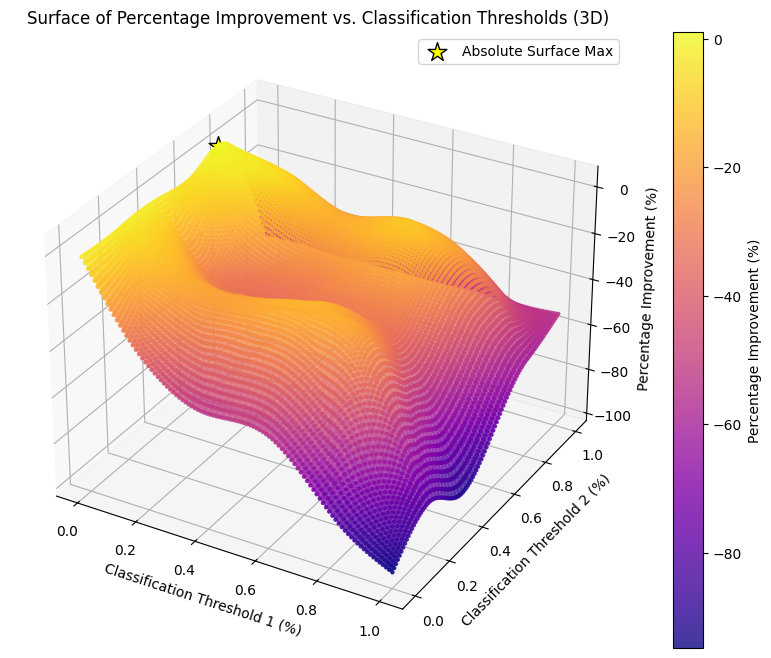

In [103]:
# Ordenar os resultados pela melhoria percentual (diff_percentage) em ordem decrescente
sorted_results = sorted(results_otimization, key=lambda x: x['diff_percentage'], reverse=True)

# Extrair os três melhores resultados
best_result = sorted_results[0]
second_best_result = sorted_results[1]
third_best_result = sorted_results[2]

# Dados para os três melhores resultados
best_sd1, best_sd2, best_diff = best_result['sensibilidade_decisiva1'], best_result['sensibilidade_decisiva2'], best_result['diff_percentage']
second_best_sd1, second_best_sd2, second_best_diff = second_best_result['sensibilidade_decisiva1'], second_best_result['sensibilidade_decisiva2'], second_best_result['diff_percentage']
third_best_sd1, third_best_sd2, third_best_diff = third_best_result['sensibilidade_decisiva1'], third_best_result['sensibilidade_decisiva2'], third_best_result['diff_percentage']

# Imprimir as três melhores combinações
print(f"Melhor combinação: Sensibilidade Decisiva 1 = {best_sd1:.2f}, Sensibilidade Decisiva 2 = {best_sd2:.2f}, Melhoria Percentual = {best_diff:.2f}%")
print(f"Segunda melhor combinação: Sensibilidade Decisiva 1 = {second_best_sd1:.2f}, Sensibilidade Decisiva 2 = {second_best_sd2:.2f}, Melhoria Percentual = {second_best_diff:.2f}%")
print(f"Terceira melhor combinação: Sensibilidade Decisiva 1 = {third_best_sd1:.2f}, Sensibilidade Decisiva 2 = {third_best_sd2:.2f}, Melhoria Percentual = {third_best_diff:.2f}%")

# Preparar os dados para o gráfico 3D
sd1_values = np.array([r['sensibilidade_decisiva1'] for r in results_otimization])
sd2_values = np.array([r['sensibilidade_decisiva2'] for r in results_otimization])
diff_values = np.array([r['diff_percentage'] for r in results_otimization])

# Criar uma grade regular para a interpolação
xi = np.linspace(sd1_values.min(), sd1_values.max(), 100)
yi = np.linspace(sd2_values.min(), sd2_values.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolar os valores dos pontos para a grade (método 'cubic' para uma superfície suave)
zi = griddata((sd1_values, sd2_values), diff_values, (xi, yi), method='cubic')

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotar a superfície interpolada
surf = ax.plot_surface(xi, yi, zi, cmap='plasma', alpha=0.8, edgecolor='none')

# Plotar os pontos originais
sc = ax.scatter(xi, yi, zi, c=zi, cmap='plasma', s=5, alpha=0.8)

# Adicionar barra de cores para referência
fig.colorbar(surf, label='Percentage Improvement (%)')

# Configurar os rótulos dos eixos
ax.set_xlabel('Classification Threshold 1 (%)')
ax.set_ylabel('Classification Threshold 2 (%)')
ax.set_zlabel('Percentage Improvement (%)')

# --- Find absolute maximum of the interpolated surface ---
# Get linear index of max (ignoring NaNs)
max_idx = np.nanargmax(zi)
# Convert to 2D index
max_i, max_j = np.unravel_index(max_idx, zi.shape)
# Retrieve coordinates and value
max_sd1 = xi[max_i, max_j]
max_sd2 = yi[max_i, max_j]
max_diff = zi[max_i, max_j]

Results_Last_array[0] = [max_sd1, max_sd2, max_diff]

print("\nAbsolute maximum of the interpolated surface:")
print(f"  Decision Sensitivity 1 = {max_sd1:.4f}")
print(f"  Decision Sensitivity 2 = {max_sd2:.4f}")
print(f"  Improvement         = {max_diff:.4f}%")

# Highlight the absolute max on the surface
ax.scatter(max_sd1, max_sd2, max_diff,
           color='yellow', s=200, marker='*', edgecolors='black',
           label='Absolute Surface Max')

plt.title('Surface of Percentage Improvement vs. Classification Thresholds (3D)')
plt.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a sensibilidade decisiva que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor sensibilidade decisiva parqa este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

Melhor combinação: Sensibilidade Decisiva 1 = 0.20, Sensibilidade Decisiva 2 = 0.80, Média Diferença Percentual = -0.33%
Segunda melhor combinação: Sensibilidade Decisiva 1 = 0.00, Sensibilidade Decisiva 2 = 0.00, Média Diferença Percentual = -0.86%
Terceira melhor combinação: Sensibilidade Decisiva 1 = 0.00, Sensibilidade Decisiva 2 = 0.20, Média Diferença Percentual = -0.86%

Absolute maximum on interpolated surface:
  Decision Sensitivity 1 = 0.1212
  Decision Sensitivity 2 = 0.7576
  Mean Difference       = 0.3598%


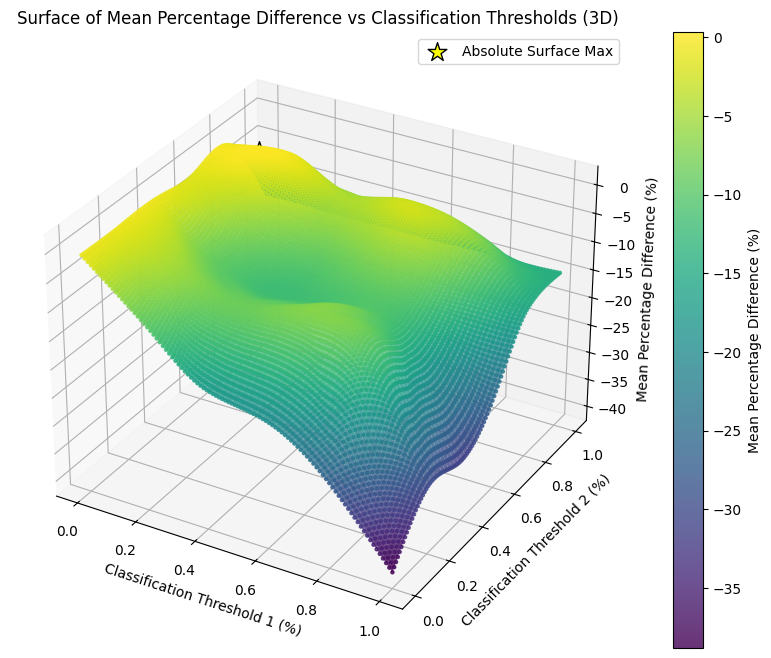

In [104]:
# Ordenar os resultados pela média da diferença percentual (media_diff_percentual) em ordem decrescente
sorted_results = sorted(results_otimization, key=lambda x: x['media_diff_percentual'], reverse=True)

# Extrair os três melhores resultados
best_result = sorted_results[0]
second_best_result = sorted_results[1]
third_best_result = sorted_results[2]

# Dados para os três melhores resultados
best_sd1 = best_result['sensibilidade_decisiva1']
best_sd2 = best_result['sensibilidade_decisiva2']
best_media_diff = best_result['media_diff_percentual']

second_best_sd1 = second_best_result['sensibilidade_decisiva1']
second_best_sd2 = second_best_result['sensibilidade_decisiva2']
second_best_media_diff = second_best_result['media_diff_percentual']

third_best_sd1 = third_best_result['sensibilidade_decisiva1']
third_best_sd2 = third_best_result['sensibilidade_decisiva2']
third_best_media_diff = third_best_result['media_diff_percentual']

# Imprimir as três melhores combinações
print(f"Melhor combinação: Sensibilidade Decisiva 1 = {best_sd1:.2f}, Sensibilidade Decisiva 2 = {best_sd2:.2f}, Média Diferença Percentual = {best_media_diff:.2f}%")
print(f"Segunda melhor combinação: Sensibilidade Decisiva 1 = {second_best_sd1:.2f}, Sensibilidade Decisiva 2 = {second_best_sd2:.2f}, Média Diferença Percentual = {second_best_media_diff:.2f}%")
print(f"Terceira melhor combinação: Sensibilidade Decisiva 1 = {third_best_sd1:.2f}, Sensibilidade Decisiva 2 = {third_best_sd2:.2f}, Média Diferença Percentual = {third_best_media_diff:.2f}%")

# Preparar os dados para o gráfico 3D
sd1_values = np.array([r['sensibilidade_decisiva1'] for r in results_otimization])
sd2_values = np.array([r['sensibilidade_decisiva2'] for r in results_otimization])
media_diff_values = np.array([r['media_diff_percentual'] for r in results_otimization])

# Criar uma grade regular para a interpolação
xi = np.linspace(sd1_values.min(), sd1_values.max(), 100)
yi = np.linspace(sd2_values.min(), sd2_values.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolar os valores dos pontos para a grade (método 'cubic' para uma superfície suave)
zi = griddata((sd1_values, sd2_values), media_diff_values, (xi, yi), method='cubic')

# --- Find the absolute maximum on the interpolated surface ---
linear_max_idx = np.nanargmax(zi)                            # index of max (ignores NaNs)
max_i, max_j = np.unravel_index(linear_max_idx, zi.shape)    # convert to 2D index
max_sd1 = xi[max_i, max_j]
max_sd2 = yi[max_i, max_j]
max_mean = zi[max_i, max_j]

Results_Mean_array[0] = [max_sd1, max_sd2, max_mean]

print("\nAbsolute maximum on interpolated surface:")
print(f"  Decision Sensitivity 1 = {max_sd1:.4f}")
print(f"  Decision Sensitivity 2 = {max_sd2:.4f}")
print(f"  Mean Difference       = {max_mean:.4f}%")

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotar a superfície interpolada
surf = ax.plot_surface(xi, yi, zi, cmap='viridis', alpha=0.8, edgecolor='none')

# Plotar os pontos originais
sc = ax.scatter(xi, yi, zi, c=zi, cmap='viridis', s=5, alpha=0.8)

# Highlight absolute maximum on the surface
ax.scatter(max_sd1, max_sd2, max_mean,
           color='yellow', s=200, marker='*', edgecolors='black',
           label='Absolute Surface Max')

# Adicionar barra de cores para referência
fig.colorbar(surf, label='Mean Percentage Difference (%)')

# Configurar os rótulos dos eixos
ax.set_xlabel('Classification Threshold 1 (%)')
ax.set_ylabel('Classification Threshold 2 (%)')
ax.set_zlabel('Mean Percentage Difference (%)')

plt.title('Surface of Mean Percentage Difference vs Classification Thresholds (3D)')
plt.legend()
plt.show()

### **Test**

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para um valor em especifico de sensibilidade decisiva.

Geralmente a ideia é analisar detalhadamente o que é que acontec com o valor considerado ideal encotrado anteriormente.

Escolhe-se o valor da sensibilidade decisiva que se quer estudar.

In [105]:
sensibilidade_decisiva1 = Results_Mean_array[0][0]
print(f"Sensibilidade Decisiva 1: {sensibilidade_decisiva1}")
sensibilidade_decisiva2 = Results_Mean_array[0][1]
print(f"Sensibilidade Decisiva 2: {sensibilidade_decisiva2}")

Sensibilidade Decisiva 1: 0.12121212121212122
Sensibilidade Decisiva 2: 0.7575757575757577


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [106]:
# Inicializar variáveis
initial_fund = Initial_Funds  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0         # Número de ações atualmente detidas (permitindo frações)
networth_strategy_test = []   # Lista para armazenar a evolução do fundo
Total_Fees = 0
Total_Slippage = 0
if Paid_Sun_Tzu:
    proxima_cobranca = last_subsets_dates_test[0]
    total_cobrancas = 0

print("Início da Simulação de Transações")
print("=" * 60)

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_test_np) - 1):
    current_price = float(tensor_test_np[i + 1][0])  # Preço da ação para compra/venda
    prediction = tensor_test_np[i][1]                # Previsão atual

    print("-" * 60)
    print(f"Período {i + 1}:")
    print(f"Data: {last_subsets_dates_test[i]}")
    print(f"Preço da ação: ${current_price:.2f}")
    print(f"Previsão: {prediction}")

    if Paid_Sun_Tzu:
        if proxima_cobranca <= last_subsets_dates_test[i]:
            total_cobrancas += 1
            proxima_cobranca = last_subsets_dates_test[i] + relativedelta(months=1)
            fund -= valor_cobranca_test
            print(f"Custo do Alpaca cobrado: ${valor_cobranca_test:.2f}")
            print(f"Fundo restante: ${fund:.2f}")

    # Verificar se há previsão válida
    if prediction != 'none':
        prediction_val = float(prediction)

        # Cenário de venda: previsão baixa e ações em carteira
        if prediction_val < sensibilidade_decisiva1 and num_shares > 0:
            exec_px = exec_price_with_slippage("sell", current_price, symbol)
            sale_value = num_shares * exec_px
            SEC_fee = calculate_fee('sell', sale_value)
            fund += sale_value - SEC_fee
            Slippage_Cost = num_shares * (current_price - exec_px)
            Total_Slippage += Slippage_Cost
            Total_Fees += SEC_fee
            print(f">>> Sinal de VENDA detectado! (Previsão {prediction_val:.2f} < {sensibilidade_decisiva1})")
            print(f"Vendido {num_shares:.6f} ações a ${exec_px:.2f} cada, total recebido: ${sale_value:.2f}")
            print(f"Custo de slippage: ${Slippage_Cost:.2f}")
            print(f"Custo da transação: ${SEC_fee:.2f}")
            print(f"Fundo atualizado: ${fund:.2f}")
            num_shares = 0.0

        # Cenário de compra: previsão alta e fundos disponíveis
        elif prediction_val > sensibilidade_decisiva2 and fund > 0:
            exec_px = exec_price_with_slippage("buy", current_price, symbol)
            num_shares_to_buy = fund / exec_px
            cost = num_shares_to_buy * exec_px
            Slippage_Cost = num_shares_to_buy * (exec_px - current_price)
            Total_Slippage += Slippage_Cost
            fund -= cost
            num_shares += num_shares_to_buy
            print(f">>> Sinal de COMPRA detectado! (Previsão {prediction_val:.2f} > {sensibilidade_decisiva2})")
            print(f"Comprado {num_shares_to_buy:.6f} ações a ${exec_px:.2f} cada, custo total: ${cost:.2f}")
            print(f"Custo de slippage: ${Slippage_Cost:.2f}")
            print(f"Fundo restante: ${fund:.2f}")

        # Caso a previsão esteja entre os dois thresholds, mantém a posição
        else:
            print(">>> Nenhuma operação executada. Mantendo posição atual.")

    else:
        print(">>> Previsão 'none' detectada. Nenhuma operação executada.")

    current_networth = fund + num_shares * current_price
    print(f"Valor líquido atual (fundo + ações): ${current_networth:.2f}")
    networth_strategy_test.append(current_networth)

# No final do tensor, vender quaisquer ações restantes
if num_shares > 0:
    final_price = float(tensor_test_np[-1][0])
    exec_px = exec_price_with_slippage("sell", final_price, symbol)
    SEC_fee = calculate_fee('sell', num_shares * exec_px)
    Slippage_Cost = num_shares * (final_price - exec_px)
    Total_Slippage += Slippage_Cost
    Total_Fees += SEC_fee
    final_sale_value = num_shares * exec_px - SEC_fee
    fund += final_sale_value
    print("\n" + "=" * 60)
    print("Período Final:")
    print(f"Preço final da ação: ${final_price:.2f}")
    print(f">>> Vendendo {num_shares:.6f} ações restantes a ${exec_px:.2f} cada, total recebido: ${final_sale_value:.2f}")
    print(f"Custo de slippage: ${Slippage_Cost:.2f}")
    print(f"Custo da transação: ${SEC_fee:.2f}")
    num_shares = 0.0
    print(f"Fundo final atualizado: ${fund:.2f}")
    print("=" * 60)

print("=" * 60)
print("Fim da Simulação de Transações")
print("=" * 60)

networth_strategy_test.append(fund)

print(f"Data de ínicio da simulação: {last_subsets_dates_test[0]}. Data de fim da simulação: {last_subsets_dates_test[-1]}")

# Exibir o balanço final do fundo
print("Balanço final do fundo de investimento: ${:.2f}".format(fund))

print(f"Total gasto em slippage: ${Total_Slippage:.2f}")

print(f"Total gasto em taxas do SEC: ${Total_Fees:.2f}")
if Paid_Sun_Tzu:
    print(f"Data da primeira cobrança Alpaca: {last_subsets_dates_test[0]}. Total de cobranças do Alpaca: {total_cobrancas}. Valor gasto: ${total_cobrancas*valor_cobranca_test}")

# Calcular o percentual de crescimento
percentage_increase_strategy_test = ((fund - initial_fund) / initial_fund) * 100
print("Percentual de crescimento do fundo com a estratégia: {:.3f}%".format(percentage_increase_strategy_test))

Início da Simulação de Transações
------------------------------------------------------------
Período 1:
Data: 2023-05-02
Preço da ação: $166.62
Previsão: 0.47213515639305115
Custo do Alpaca cobrado: $99.00
Fundo restante: $99901.00
>>> Nenhuma operação executada. Mantendo posição atual.
Valor líquido atual (fundo + ações): $99901.00
------------------------------------------------------------
Período 2:
Data: 2023-05-02
Preço da ação: $167.43
Previsão: 0.966567873954773
>>> Sinal de COMPRA detectado! (Previsão 0.97 > 0.7575757575757577)
Comprado 596.494288 ações a $167.48 cada, custo total: $99901.00
Custo de slippage: $29.96
Fundo restante: $0.00
Valor líquido atual (fundo + ações): $99871.04
------------------------------------------------------------
Período 3:
Data: 2023-05-03
Preço da ação: $167.51
Previsão: 0.9994866847991943
>>> Nenhuma operação executada. Mantendo posição atual.
Valor líquido atual (fundo + ações): $99918.76
---------------------------------------------------

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo.

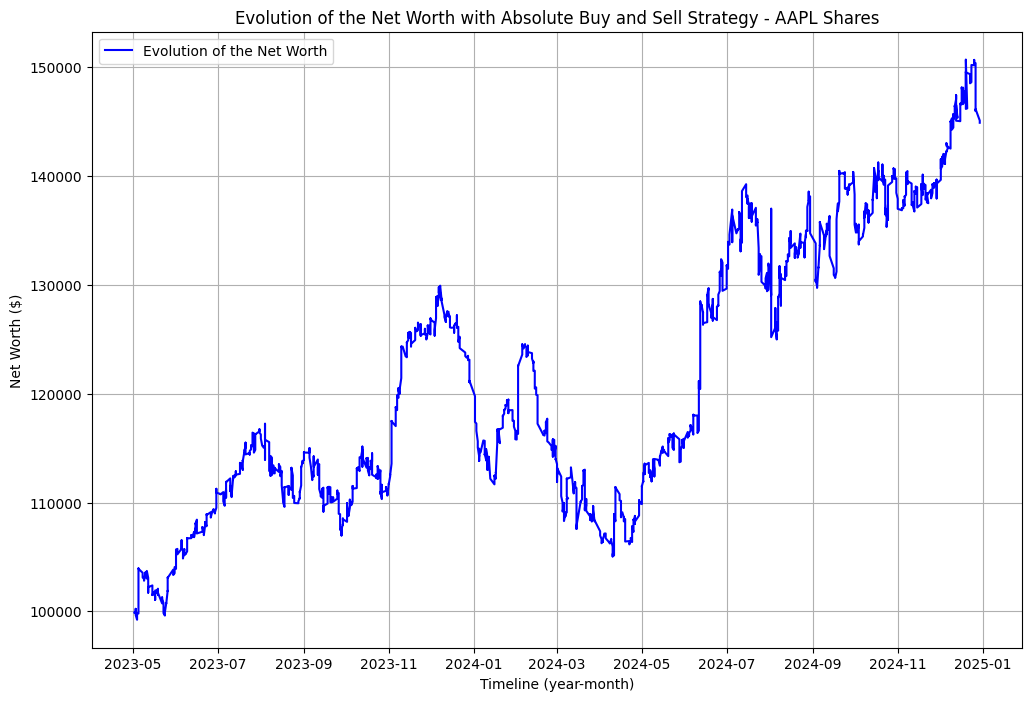

In [107]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, networth_strategy_test, label='Evolution of the Net Worth', color='blue')

plt.title('Evolution of the Net Worth with Absolute Buy and Sell Strategy - ' + symbol + " Shares")
plt.xlabel('Timeline (year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

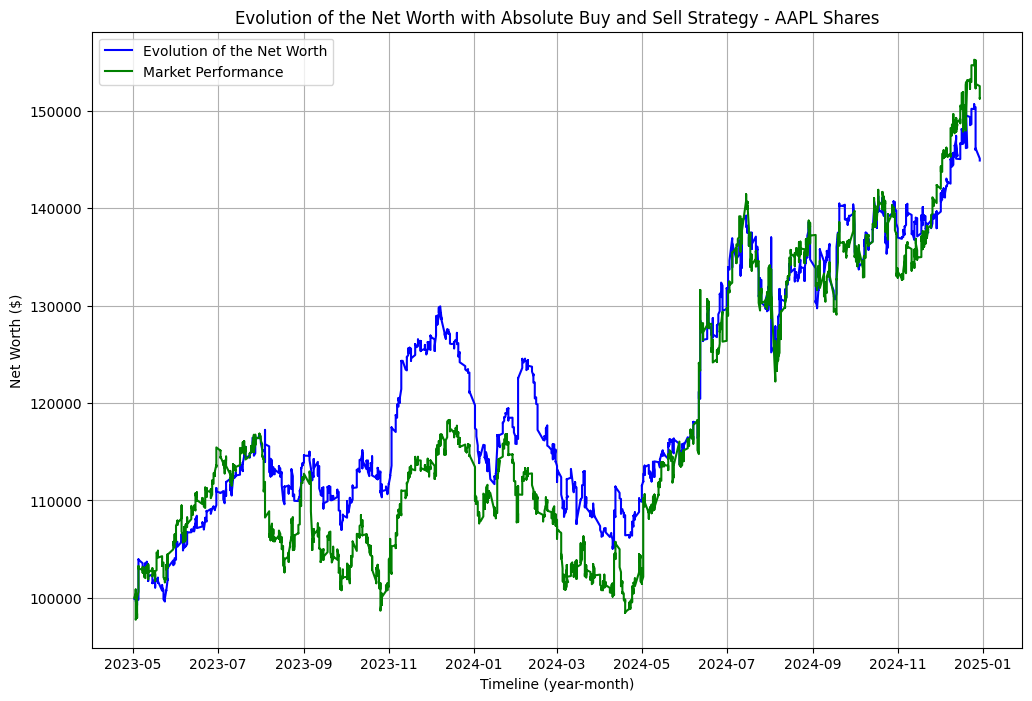

In [108]:
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, networth_strategy_test, label='Evolution of the Net Worth', color='blue')
plt.plot(last_subsets_dates_test, natural_fund_values_test, label='Market Performance', color='green')

plt.title('Evolution of the Net Worth with Absolute Buy and Sell Strategy - ' + symbol + " Shares")
plt.xlabel('Timeline (year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [109]:
print(f"Dinheiro extra ganho ao se ter usado AI: {fund-percentage_increase_test-final_value_test:.3f}$")

percentage_improvement_AI_test = percentage_increase_strategy_test-percentage_increase_test
print(f"\nMelhoria percentual ao se ter usado AI: {percentage_improvement_AI_test:.3f}%")

Dinheiro extra ganho ao se ter usado AI: -6333.282$

Melhoria percentual ao se ter usado AI: -6.282%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. O valor da sensibilidade decisiva deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Absolute Maximum's Coordenates:
Date: 2023-11-10
Maximum Percentage Difference: 14.01%
Average Percentage Difference between Net Worth and Market Price: 3.15%


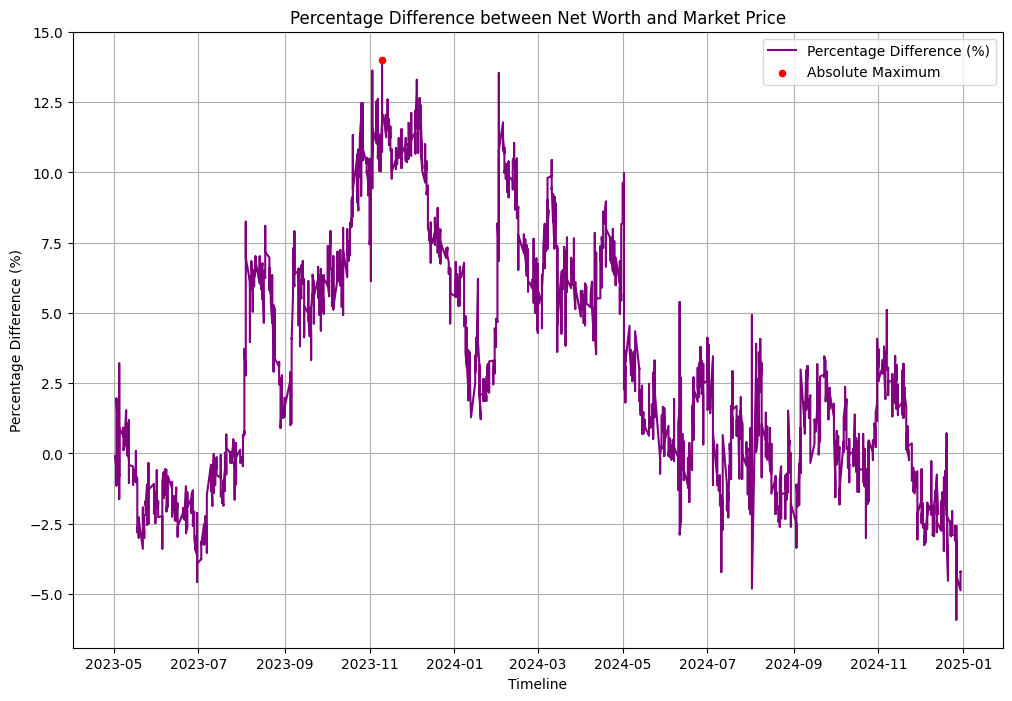

In [110]:
# Calcular a diferença percentual
diff_percentual_test = ((np.array(networth_strategy_test) - np.array(natural_fund_values_test)) / np.array(natural_fund_values_test)) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual_test)

# Coordenadas do valor máximo
max_diff_percentual_test = diff_percentual_test[max_index]
max_date = last_subsets_dates_test[max_index]

print(f"Absolute Maximum's Coordenates:")
print(f"Date: {max_date}")
print(f"Maximum Percentage Difference: {max_diff_percentual_test:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, diff_percentual_test, label='Percentage Difference (%)', color='purple')

# Adicionar o ponto máximo ao gráfico
plt.scatter(max_date, max_diff_percentual_test, color='red', s=20, zorder=5, label='Absolute Maximum')

# Rótulos e título
plt.title('Percentage Difference between Net Worth and Market Price')
plt.xlabel('Timeline')
plt.ylabel('Percentage Difference (%)')

# Calcular a média da diferença percentual
media_diff_percentual_test = np.mean(diff_percentual_test)

# Printar o valor médio
print(f"Average Percentage Difference between Net Worth and Market Price: {media_diff_percentual_test:.2f}%")

Results_Mean_array_test[0] = [sensibilidade_decisiva1, sensibilidade_decisiva2, percentage_improvement_AI_test, media_diff_percentual_test]

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

In [111]:
# 1) Build your NAV Series from lists
values = pd.Series(
    data=networth_strategy_test,
    index=pd.to_datetime(last_subsets_dates_test),
    name="NAV"
).sort_index()

# 2) Compute period-to-period returns
returns = values.pct_change().dropna()

# 3) Estimate effective periods per year
P = estimate_periods_per_year(returns)

# 4) Build the metric functions for your frequency
metrics = make_metrics(P)

# —————————————————
# NEW: load & prepare your benchmark
bench_nav = pd.Series(
    data=natural_fund_values_test,
    index=pd.to_datetime(last_subsets_dates_test),
    name="Natural NAV"
).sort_index()

benchmark_returns = bench_nav.pct_change().dropna()

# 5) Define a (scalar) annual risk-free rate - Glabally define Above on the section of settings
#rf = 0.01  # e.g. 1% p.a.

# 6) Automatically run **all** metrics you can compute:
results = {}
for name, func in metrics.items():
    sig    = inspect.signature(func)
    params = list(sig.parameters)

    try:
        # If it expects (returns, benchmark_returns, rf)
        if params == ["returns", "benchmark_returns", "rf"]:
            results[name] = func(returns, benchmark_returns, rf)

        # If it expects only (returns, benchmark_returns)
        elif params == ["returns", "benchmark_returns"]:
            results[name] = func(returns, benchmark_returns)

        # If it expects (returns, rf)
        elif params == ["returns", "rf"]:
            results[name] = func(returns, rf)

        # Otherwise just (returns,)
        else:
            results[name] = func(returns)

    except Exception:
        results[name] = float("nan")

# 7) Display only the successfully computed metrics
print(pd.Series(results).dropna())

total_return               0.450509
annualized_return          0.204371
annualized_volatility      0.266406
sharpe_ratio               0.672807
sortino_ratio              0.784450
max_drawdown              -0.191489
drawdown_duration        838.000000
ulcer_index                7.276747
value_at_risk              0.010907
expected_shortfall         0.017652
calmar_ratio               1.067272
information_ratio         -0.091413
beta                       0.296482
alpha                      0.124372
r_squared                  0.109853
treynor_ratio              0.544285
skewness                   0.624570
kurtosis                  12.617702
omega_ratio                1.088601
dtype: float64


/tmp/ipython-input-1640029880.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return _capm_regression(returns, benchmark_returns, rf).params[1]
/tmp/ipython-input-1640029880.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = _capm_regression(returns, benchmark_returns, rf).params[0]
/tmp/ipython-input-1640029880.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return _capm_regression(returns, benchmark_returns, rf).pa

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

Coordenadas do ponto máximo absoluto: Dinheiro Inicial = $10000100.00, Percentual de Crescimento = 47.308%


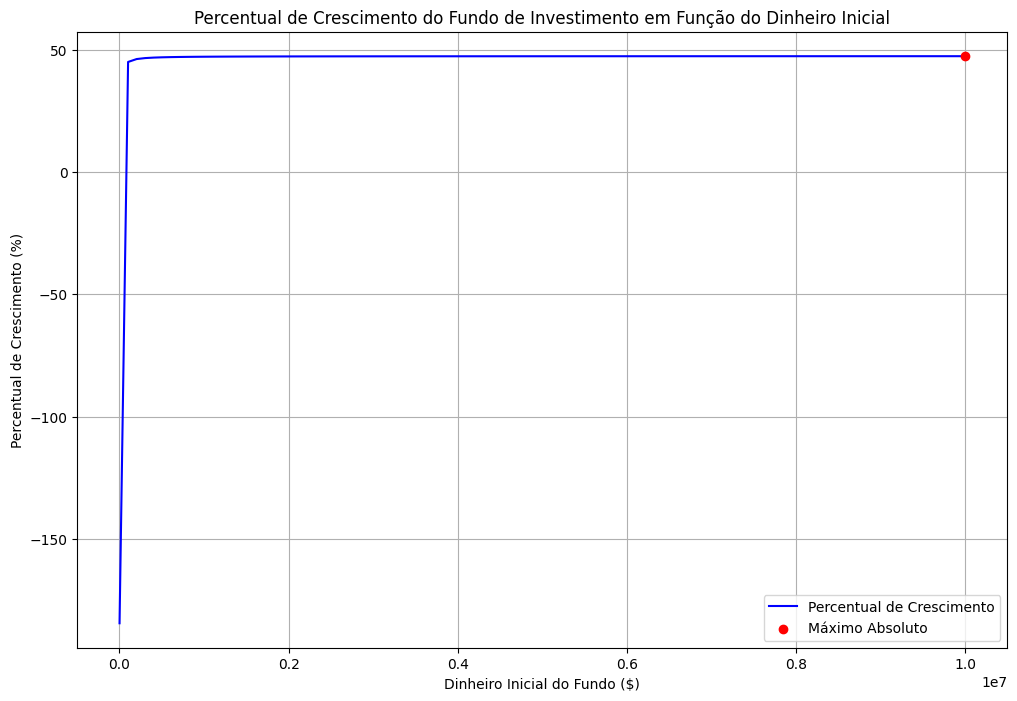

In [112]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(Min_Floor_Fund, Max_Selling_Fund + Step_money, Step_money)

# Lista para armazenar os resultados: percentual de crescimento para cada valor inicial
percentual_ganhos = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Número de ações atualmente detidas (permitindo frações)
    if Paid_Sun_Tzu:
        proxima_cobranca = last_subsets_dates_test[0]

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_test_np) - 1):
        current_price = float(tensor_test_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_str = tensor_test_np[i][1]  # Previsão atual (grau de certeza)

        if Paid_Sun_Tzu:
            if proxima_cobranca <= last_subsets_dates_test[i]:
                proxima_cobranca = last_subsets_dates_test[i] + relativedelta(months=1)
                fund -= valor_cobranca_test

        # Converter a previsão para float se válida, caso contrário definir como 0
        if prediction_str != 'none':
            prediction = float(prediction_str)
        else:
            prediction = 0

        # Se a previsão indicar cenário de queda (abaixo do threshold de venda) e houver ações, vende
        if prediction < sensibilidade_decisiva1 and num_shares > 0:
            exec_px = exec_price_with_slippage("sell", current_price, symbol)
            SEC_fee = calculate_fee('sell', num_shares * exec_px)
            fund += num_shares * exec_px  - SEC_fee # Vende todas as ações
            num_shares = 0.0

        # Se a previsão indicar cenário de alta (acima do threshold de compra) e houver fundos, compra
        elif prediction > sensibilidade_decisiva2 and fund > 0:
            exec_px = exec_price_with_slippage("buy", current_price, symbol)
            num_shares_to_buy = fund / exec_px  # Quantidade de ações que podemos comprar
            fund -= num_shares_to_buy * exec_px  # Atualiza o fundo após compra
            num_shares += num_shares_to_buy

        # Se a previsão estiver entre os thresholds, nenhuma operação é executada

    # No final do tensor, vender quaisquer ações remanescentes
    if num_shares > 0:
        final_price = float(tensor_test_np[-1][0])  # Preço final para venda
        exec_px = exec_price_with_slippage("sell", final_price, symbol)
        SEC_fee = calculate_fee('sell', num_shares * exec_px)
        fund += num_shares * exec_px - SEC_fee # Vende todas as ações restantes
        num_shares = 0.0

    # Calcular o percentual de crescimento da estratégia para este fundo inicial
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
    percentual_ganhos.append(percentage_increase_strategy)

# Encontrar o índice do valor máximo de percentual_ganhos
max_index = np.argmax(percentual_ganhos)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = percentual_ganhos[max_index]

print(f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%")

# Plotar o gráfico do Percentual de Crescimento em função do Dinheiro Inicial
plt.figure(figsize=(12, 8))
plt.plot(initial_fund_values, percentual_ganhos, label='Percentual de Crescimento', color='blue')
plt.scatter(max_initial_fund, max_percentage_increase, color='red', zorder=5, label="Máximo Absoluto")  # Destacar o ponto máximo
plt.ylim(min(percentual_ganhos) - 10, max(percentual_ganhos) + 10)
plt.title('Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial')
plt.xlabel('Dinheiro Inicial do Fundo ($)')
plt.ylabel('Percentual de Crescimento (%)')
plt.grid(True)
plt.legend()
plt.show()

## **Independent Parcial Buy and Sell in Function of Predictions Probabilaty**

Agora eu quero testar uma nova estratégia. As compras e as vendas vão ser de forma percentual. Ou seja, sempre que existe um sinal positivo para compra - "1", deve ser gasto "coeficiente * grau_certeza"% (o grau_certeza é dado por "predictions", relembrando que sempre que "predictions" é superior a "sensibilidade_decisiva" é um "1" e sempre que "predictions" é inferior a "sensibilidade_decisiva" é um "0", o grau_certeza é pela certeza que o modelo tem se se trata de um "0" ou de um "1", isto pode ser inferido através de "predictions") do dinheiro do fundo de investimento na compra de ações, se existir algum dinheiro ainda no fundo para o fazer de acordo com o percentual calculado. Sempre que existe um sinal positivo de venda - "0", devem ser vendidas "coeficiente * grau_certeza"% das ações do fundo de investimento, se o fundo tiver ainda ações suficientes para o fazer de acordo com a percentagem calculada. A questão que aqui diferencia da passada estratégia é que agora vão existir 2 coeficientes em jogo um coeficente para ações de venda, coeficiente_v, outro para ações de compra, coeficiente_c.

Esta estratégia é extremamente semelhante á anterior apenas é acrecenta um novo coeficiente e para tal terá de ser distinguido o coeficiente de buy do coeficiente de sell.

if prediction > sensibilidade_decisiva and fund > 0:
    grau_certeza = abs(prediction)  # Grau de certeza do modelo
    # Comprar ações com base no percentual calculado
    amount_to_invest = coeficiente_c * grau_certeza * fund
    num_shares_to_buy = amount_to_invest / current_price  # Quantidade de ações que podemos comprar (fracionária)
    fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
    num_shares += num_shares_to_buy  # Atualiza o número de ações

elif prediction <= sensibilidade_decisiva and num_shares > 0:
    grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
    # Vender ações com base no percentual calculado
    amount_to_sell = coeficiente_v * grau_certeza * num_shares  # Quantidade de ações a vender
    num_shares_to_sell = amount_to_sell  # Quantidade fracionária de ações a vender
    fund += num_shares_to_sell * current_price  # Vende as ações e atualiza o fundo
    num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda

Por este código passam 3 loops diferentes todos uns dentro uns dos outros assim consigo garantir que para cada coeficiente de compra é testado para todos os valores de coeficiente de venda e para todos os valores de sensibilidade decisiva.

### **Otimization**

**Estudo do Melhor Coeficiente e Melhor Sensibilidade Decisiva para Formatar o Percentual Investido:**

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva e do coeficientes. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva e com o coeficientes utilizados sinalarizará a melhor combinação sensibilidade decisiva, coeficiente para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva e coefieciente em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor combinação sensibilidade decisiva, coeficientes.

In [113]:
# Fundo inicial
initial_fund_otimization = Initial_Funds  # $100,000

# Listas para armazenar os parâmetros e resultados
x_vals_otimization = []            # Sensibilidade Decisiva 1 (sd1 - VENDA)
y_vals_otimization = []            # Sensibilidade Decisiva 2 (sd2 - COMPRA)
z_vals_otimization = []            # Coeficiente C (Compra)
color_vals_media_otimization = []  # Média da Diferença Percentual (métrica de desempenho)
color_vals_otimization = []        # Ganho percentual relativo (percentual_ganho - percentage_increase)

total_iterations = len(sensibilidade_decisiva1_array_otimization) * len(sensibilidade_decisiva2_array_otimization) * len(coeficiente_c_array_otimization) * len(coeficiente_v_array_otimization)
iteration = 0

# Loop aninhado: percorre as combinações de sd1, sd2, coeficiente_c e coeficiente_v.
# Apenas combinações onde sd1 < sd2 são válidas.
for sd1_otimization in sensibilidade_decisiva1_array_otimization:
    for sd2_otimization in sensibilidade_decisiva2_array_otimization:
        for coef_c_otimization in coeficiente_c_array_otimization:
            for coef_v_otimization in coeficiente_v_array_otimization:
                iteration += 1
                print(f"\rProgress: {(iteration/total_iterations*100):.2f}%", end='')
                sys.stdout.flush()

                # Inicializar variáveis para cada combinação
                fund_otimization = initial_fund_otimization
                num_shares_otimization = 0.0
                networth_strategy_otimization = []
                if Paid_Sun_Tzu:
                    proxima_cobranca_otimization = last_subsets_dates_otimization[0]

                # Iterar pelo tensor (exceto o último que não tem previsão)
                for m in range(len(tensor_otimization_np) - 1):
                    current_price_otimization = float(tensor_otimization_np[m + 1][0])
                    prediction_otimization_str = tensor_otimization_np[m][1]

                    if Paid_Sun_Tzu:
                        if proxima_cobranca_otimization <= last_subsets_dates_otimization[m]:
                            proxima_cobranca_otimization = last_subsets_dates_otimization[m] + relativedelta(months=1)
                            fund_otimization -= valor_cobranca_otimization

                    if prediction_otimization_str != 'none':
                        prediction_otimization = float(prediction_otimization_str)
                    else:
                        prediction_otimization = 0  # Se não houver previsão, define como 0



                    # Operação de COMPRA: se previsão > sd2 e houver fundos
                    if prediction_otimization > sd2_otimization and fund_otimization > 0:
                        percentage_to_spend_otimization = coef_c_otimization * max(0.0, min(1.0, (prediction_otimization - sd2_otimization) / max(eps, 1 - sd2_otimization)))
                        if percentage_to_spend_otimization > 1:
                            percentage_to_spend_otimization = 1
                        amount_to_invest_otimization = percentage_to_spend_otimization * fund_otimization
                        exec_px = exec_price_with_slippage("buy", current_price_otimization, symbol)
                        num_shares_to_buy_otimization = amount_to_invest_otimization / exec_px
                        fund_otimization -= num_shares_to_buy_otimization * exec_px
                        num_shares_otimization += num_shares_to_buy_otimization

                    # Operação de VENDA: se previsão < sd1 e houver ações
                    elif prediction_otimization < sd1_otimization and num_shares_otimization > 0:
                        percentage_to_sell_otimization = coef_v_otimization * max(0.0, min(1.0, (sd1_otimization - prediction_otimization) / max(eps, sd1_otimization)))
                        if percentage_to_sell_otimization > 1:
                            percentage_to_sell_otimization = 1
                        amount_to_sell_otimization = percentage_to_sell_otimization * num_shares_otimization * current_price_otimization
                        exec_px = exec_price_with_slippage("sell", current_price_otimization, symbol)
                        amount_to_sell_otimization = min(amount_to_sell_otimization, num_shares_otimization * exec_px)
                        amount_shares_to_sell_otimization = amount_to_sell_otimization / exec_px
                        SEC_fee_otimization = calculate_fee('sell', amount_shares_to_sell_otimization * exec_px)
                        fund_otimization += amount_shares_to_sell_otimization * exec_px - SEC_fee_otimization
                        num_shares_otimization -= amount_shares_to_sell_otimization

                    # Registrar o valor líquido atual (fundo + ações)
                    networth_strategy_otimization.append(fund_otimization + num_shares_otimization * current_price_otimization)

                # Ao final, vender quaisquer ações remanescentes
                if num_shares_otimization > 0:
                    final_price_otimization = float(tensor_otimization_np[-1][0])
                    exec_px = exec_price_with_slippage("sell", final_price_otimization, symbol)
                    SEC_fee_otimization = calculate_fee('sell', num_shares_otimization * exec_px)
                    fund_otimization += num_shares_otimization * exec_px - SEC_fee_otimization
                    num_shares_otimization = 0
                networth_strategy_otimization.append(fund_otimization)

                # Calcular o percentual de crescimento do fundo
                percentual_ganho_otimization = ((fund_otimization - initial_fund_otimization) / initial_fund_otimization) * 100

                # Calcular a diferença percentual entre a estratégia simulada e um fundo natural
                diff_percentual_otimization = ((np.array(networth_strategy_otimization) - np.array(natural_fund_values_otimization)) /
                                   np.array(natural_fund_values_otimization)) * 100
                media_diff_percentual_otimization = np.mean(diff_percentual_otimization)
                # Armazenar os parâmetros e resultados para plotagem
                x_vals_otimization.append(sd1_otimization)
                y_vals_otimization.append(sd2_otimization)
                z_vals_otimization.append(coef_c_otimization)
                color_vals_media_otimization.append(media_diff_percentual_otimization)
                color_vals_otimization.append(percentual_ganho_otimization - percentage_increase_otimization)

Progress: 100.00%

> Using RBFInterpolator gaussian, smoothing=1e-06

=== Absolute Maximum Found ===
Source of maximum: empirical (original data)
SD1 (Sell)     = 1.000000
SD2 (Buy)      = 0.000000
Coefficient C  = 2.000000
Coefficient V  = 2.000000
Percentage Gain = 24.099329%

=== Top 3 Empirical Data Points ===
Top 1 empirical point: SD1 (Sell) = 1.000000, SD2 (Buy) = 0.000000, Coefficient C = 2.000000, Coefficient V = 2.000000, Percentage Gain = 24.099329%
Top 2 empirical point: SD1 (Sell) = 1.000000, SD2 (Buy) = 0.000000, Coefficient C = 2.000000, Coefficient V = 2.000000, Percentage Gain = 21.710994%
Top 3 empirical point: SD1 (Sell) = 1.000000, SD2 (Buy) = 0.000000, Coefficient C = 3.500000, Coefficient V = 3.500000, Percentage Gain = 10.008448%


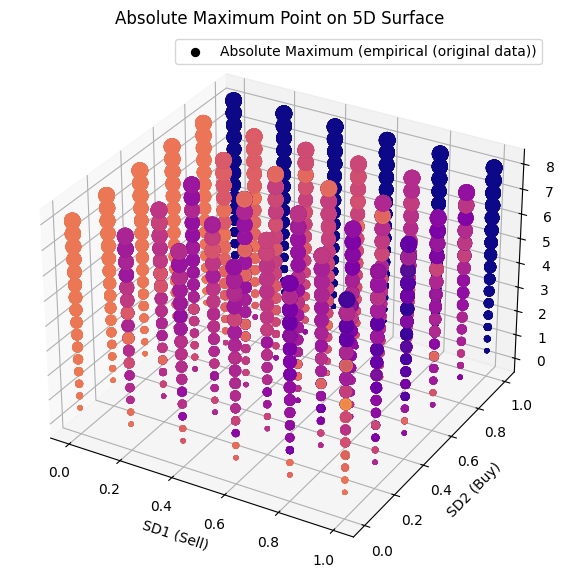

In [114]:
# --- 1) Original data as numpy arrays ---
sd1 = np.array(x_vals_otimization)       # Decision Sensitivity 1 (Sell)
sd2 = np.array(y_vals_otimization)       # Decision Sensitivity 2 (Buy)
C   = np.array(z_vals_otimization)       # Coefficient C (Buy)
V   = np.array(z_vals_otimization)       # Coefficient V (Sell)
g   = np.array(color_vals_otimization)   # Percentage Gain

# Pack into X (n×4) and y (n,)
X = np.vstack([sd1, sd2, C, V]).T
y = g

# --- 2) Build RBF interpolator with automatic smoothing ---
interp = None
try:
    for smooth in [0, 1e-6, 1e-4, 1e-2, 1e-1]:
        try:
            rbf_i = RBFInterpolator(
                X, y,
                kernel='gaussian',
                epsilon=np.mean(np.ptp(X, axis=0)),
                smoothing=smooth
            )
            interp = lambda pt: rbf_i(pt.reshape(1, -1))[0]
            print(f"> Using RBFInterpolator gaussian, smoothing={smooth}")
            break
        except LinAlgError:
            continue
    if interp is None:
        raise LinAlgError
except (ImportError, LinAlgError):
    print("> Fallback to scipy.interpolate.Rbf with smooth=1e-3")
    rbf_fb = Rbf(sd1, sd2, C, V, y, function='multiquadric', smooth=1e-3)
    interp = lambda pt: rbf_fb(*pt)

# --- 3) Define bounds and objective for maximization ---
bounds = [
    (sd1.min(), sd1.max()),
    (sd2.min(), sd2.max()),
    (C.min(),    C.max()),
    (V.min(),    V.max()),
]

def neg_gain(pt):
    """Function to minimize: -interp(pt)"""
    return -interp(pt)

# --- 4) Multi-start L-BFGS-B optimization ---
best_val = -np.inf
best_pt  = None

# 4a) starts at your top-5 empirical points
top5 = np.argsort(y)[-5:]
starts = [X[i] for i in top5]

# 4b) additional random starts within bounds
N_random = 20
for _ in range(N_random):
    rnd = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
    starts.append(rnd)

# 4c) run L-BFGS-B from each start
for x0 in starts:
    res = minimize(
        neg_gain,
        x0=x0,
        method='L-BFGS-B',
        bounds=bounds,
        options={'ftol':1e-9, 'gtol':1e-6, 'maxiter':500}
    )
    if not res.success:
        continue
    val = -res.fun
    if val > best_val:
        best_val = val
        best_pt  = res.x

# --- 5) Check empirical maximum ---
idx_emp = np.argmax(y)
emp_pt = X[idx_emp]
emp_val = y[idx_emp]

if emp_val >= best_val:
    best_source = 'empirical (original data)'
    best_pt = emp_pt
    best_val = emp_val
else:
    best_source = 'interpolated (continuous surface)'

# --- 6) Print absolute maximum result ---
print("\n=== Absolute Maximum Found ===")
print(f"Source of maximum: {best_source}")
print(f"SD1 (Sell)     = {best_pt[0]:.6f}")
print(f"SD2 (Buy)      = {best_pt[1]:.6f}")
print(f"Coefficient C  = {best_pt[2]:.6f}")
print(f"Coefficient V  = {best_pt[3]:.6f}")
print(f"Percentage Gain = {best_val:.6f}%")
Results_Last_array[1] = [best_pt[0], best_pt[1], best_pt[2], best_pt[3], best_val]

# --- 7) Print top-3 empirical data points ---
top3 = np.argsort(y)[-3:][::-1]
print("\n=== Top 3 Empirical Data Points ===")
for rank, idx in enumerate(top3, start=1):
    pt = X[idx]
    val = y[idx]
    print(f"Top {rank} empirical point: SD1 (Sell) = {pt[0]:.6f}, SD2 (Buy) = {pt[1]:.6f}, Coefficient C = {pt[2]:.6f}, Coefficient V = {pt[3]:.6f}, Percentage Gain = {val:.6f}%")

# --- 8) Final plot in English ---
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

sz = V * 15
sc = ax.scatter(sd1, sd2, C, c=g, cmap='plasma', s=sz, alpha=0.8)
ax.scatter(
    best_pt[0], best_pt[1], best_pt[2],
    color='black', s=best_pt[3]*15*2,
    edgecolors='white', label=f'Absolute Maximum ({best_source})'
)
ax.set_xlabel('SD1 (Sell)')
ax.set_ylabel('SD2 (Buy)')
ax.set_zlabel('Coefficient C (Buy)')
ax.set_title('Absolute Maximum Point on 5D Surface')
ax.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a combinação sensibilidade decisiva, coeficientes que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor combinação sensibilidade decisiva, coeficientes para este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

> Using RBFInterpolator gaussian, smoothing=1e-06

=== Absolute Maximum Found (Mean Difference) ===
Source of maximum: empirical (original data)
SD1 (Sell)     = 1.000000
SD2 (Buy)      = 0.000000
Coefficient C  = 2.000000
Coefficient V  = 2.000000
Mean Percentage Difference = 9.816375%

=== Top 3 Empirical Data Points (Mean Difference) ===
Top 1 empirical point: SD1 (Sell) = 1.000000, SD2 (Buy) = 0.000000, Coefficient C = 2.000000, Coefficient V = 2.000000, Mean Difference = 9.816375%
Top 2 empirical point: SD1 (Sell) = 1.000000, SD2 (Buy) = 0.000000, Coefficient C = 3.500000, Coefficient V = 3.500000, Mean Difference = 9.600852%
Top 3 empirical point: SD1 (Sell) = 1.000000, SD2 (Buy) = 0.000000, Coefficient C = 2.000000, Coefficient V = 2.000000, Mean Difference = 8.864066%


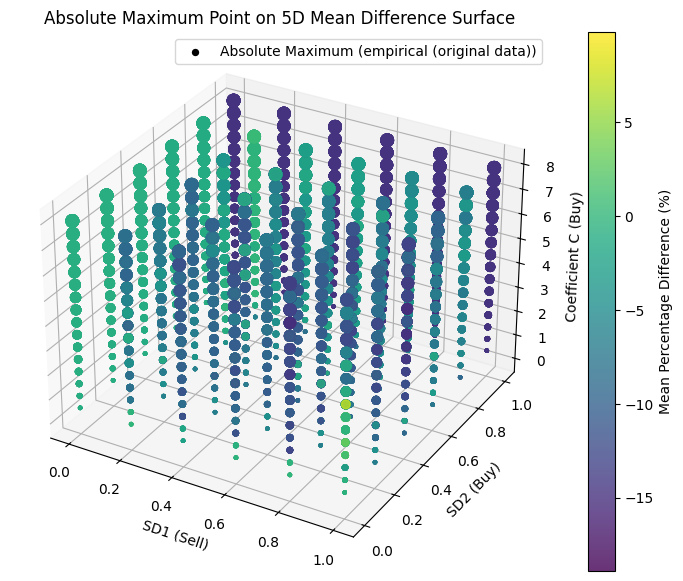

In [115]:
# --- 1) Original data as numpy arrays ---
sd1 = np.array(x_vals_otimization)               # Decision Sensitivity 1 (Sell)
sd2 = np.array(y_vals_otimization)               # Decision Sensitivity 2 (Buy)
C   = np.array(z_vals_otimization)               # Coefficient C (Buy)
V   = np.array(z_vals_otimization)               # Coefficient V (Sell)
m   = np.array(color_vals_media_otimization)     # Mean Percentage Difference

# Pack into X (n×4) and y (n,)
X = np.vstack([sd1, sd2, C, V]).T
y = m

# --- 2) Build RBF interpolator with automatic smoothing ---
interp = None
try:
    for smooth in [0, 1e-6, 1e-4, 1e-2, 1e-1]:
        try:
            rbf_i = RBFInterpolator(
                X, y,
                kernel='gaussian',
                epsilon=np.mean(np.ptp(X, axis=0)),
                smoothing=smooth
            )
            interp = lambda pt: rbf_i(pt.reshape(1, -1))[0]
            print(f"> Using RBFInterpolator gaussian, smoothing={smooth}")
            break
        except LinAlgError:
            continue
    if interp is None:
        raise LinAlgError
except (ImportError, LinAlgError):
    print("> Fallback to scipy.interpolate.Rbf with smooth=1e-3")
    rbf_fb = Rbf(sd1, sd2, C, V, y, function='multiquadric', smooth=1e-3)
    interp = lambda pt: rbf_fb(*pt)

# --- 3) Define bounds and objective for maximization ---
bounds = [
    (sd1.min(), sd1.max()),
    (sd2.min(), sd2.max()),
    (C.min(),    C.max()),
    (V.min(),    V.max()),
]

def neg_mdiff(pt):
    """Function to minimize: -interp(pt)"""
    return -interp(pt)

# --- 4) Multi-start L-BFGS-B optimization ---
best_val = -np.inf
best_pt  = None

# 4a) starts at your top-5 empirical points
top5 = np.argsort(y)[-5:]
starts = [X[i] for i in top5]

# 4b) additional random starts within bounds
N_random = 20
for _ in range(N_random):
    rnd = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
    starts.append(rnd)

# 4c) run L-BFGS-B from each start
for x0 in starts:
    res = minimize(
        neg_mdiff,
        x0=x0,
        method='L-BFGS-B',
        bounds=bounds,
        options={'ftol':1e-9, 'gtol':1e-6, 'maxiter':500}
    )
    if not res.success:
        continue
    val = -res.fun
    if val > best_val:
        best_val = val
        best_pt  = res.x

# --- 5) Check empirical maximum ---
idx_emp = np.argmax(y)
emp_pt = X[idx_emp]
emp_val = y[idx_emp]

if emp_val >= best_val:
    best_source = 'empirical (original data)'
    best_pt = emp_pt
    best_val = emp_val
else:
    best_source = 'interpolated (continuous surface)'

# --- 6) Print absolute maximum result ---
print("\n=== Absolute Maximum Found (Mean Difference) ===")
print(f"Source of maximum: {best_source}")
print(f"SD1 (Sell)     = {best_pt[0]:.6f}")
print(f"SD2 (Buy)      = {best_pt[1]:.6f}")
print(f"Coefficient C  = {best_pt[2]:.6f}")
print(f"Coefficient V  = {best_pt[3]:.6f}")
print(f"Mean Percentage Difference = {best_val:.6f}%")
Results_Mean_array[1] = [best_pt[0], best_pt[1], best_pt[2], best_pt[3], best_val]

# --- 7) Print top-3 empirical data points ---
top3 = np.argsort(y)[-3:][::-1]
print("\n=== Top 3 Empirical Data Points (Mean Difference) ===")
for rank, idx in enumerate(top3, start=1):
    pt = X[idx]
    val = y[idx]
    print(f"Top {rank} empirical point: SD1 (Sell) = {pt[0]:.6f}, SD2 (Buy) = {pt[1]:.6f}, Coefficient C = {pt[2]:.6f}, Coefficient V = {pt[3]:.6f}, Mean Difference = {val:.6f}%")

# --- 8) Final plot in English ---
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

sz = V * 10
sc = ax.scatter(sd1, sd2, C, c=m, cmap='viridis', s=sz, alpha=0.8)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Mean Percentage Difference (%)')
ax.scatter(
    best_pt[0], best_pt[1], best_pt[2],
    color='black', s=best_pt[3]*10*2,
    edgecolors='white', label=f'Absolute Maximum ({best_source})'
)
ax.set_xlabel('SD1 (Sell)')
ax.set_ylabel('SD2 (Buy)')
ax.set_zlabel('Coefficient C (Buy)')
ax.set_title('Absolute Maximum Point on 5D Mean Difference Surface')
ax.legend()
plt.show()

### **Test**

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para uma combinação especifica de sensibilidade decisiva e coeficientes.

Geralmente a ideia é analisar detalhadamente o que é que acontece com a combinação considerado ideal encotrado anteriormente.

In [116]:
sensibilidade_decisiva1_test = Results_Mean_array[1][0]
print(f"Sensibilidade Decisiva: {sensibilidade_decisiva1_test}")
sensibilidade_decisiva2_test = Results_Mean_array[1][1]
print(f"Sensibilidade Decisiva 2: {sensibilidade_decisiva2_test}")
coeficiente_c_test = Results_Mean_array[1][2]
print(f"Coeficiente Compra: {coeficiente_c_test}")
coeficiente_v_test = Results_Mean_array[1][3]
print(f"Coeficiente Venda: {coeficiente_v_test}")

Sensibilidade Decisiva: 1.0
Sensibilidade Decisiva 2: 0.0
Coeficiente Compra: 2.0
Coeficiente Venda: 2.0


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [117]:
# Inicializar variáveis
fund_test = Initial_Funds
num_shares_test = 0.0             # Número de ações detidas (podem ser fracionárias)
networth_strategy_test = []       # Armazenar a evolução do valor líquido (net worth)
Total_Fees_test = 0
Total_Slippage = 0
if Paid_Sun_Tzu:
    proxima_cobranca_test = last_subsets_dates_test[0]
    total_cobrancas_test = 0

print("Início da Simulação de Transações com Duas Sensibilidades Decisivas")
print("=" * 60)

# Iterar pelos períodos do tensor (exceto o último, que não possui previsão)
for i in range(len(tensor_test_np) - 1):
    current_price_test = float(tensor_test_np[i + 1][0])  # Preço da ação para operação
    prediction_test_str = tensor_test_np[i][1]              # Previsão atual (grau de certeza)

    if Paid_Sun_Tzu:
        if proxima_cobranca_test <= last_subsets_dates_test[i]:
            proxima_cobranca_test = last_subsets_dates_test[i] + relativedelta(months=1)
            fund_test -= valor_cobranca_test
            total_cobrancas_test += 1
            print(f"Custo do Alpaca cobrado: ${valor_cobranca_test:.2f}")
            print(f"Fundo restante: ${fund_test:.2f}")

    # Converter a previsão para float ou definir como 0 se não houver previsão
    if prediction_test_str != 'none':
        prediction_test = float(prediction_test_str)
    else:
        prediction_test = 0

    # Imprimir informações do período
    print("-" * 60)
    print(f"Período {i + 1}:")
    print(f"Preço da ação: ${current_price_test:.2f}")
    print(f"Previsão: {prediction_test:.2f}")

    # Verificar se deve comprar (previsão acima do threshold de compra e fundos disponíveis)
    if prediction_test > sensibilidade_decisiva2_test and fund_test > 0:
        percentage_to_spend_test = coeficiente_c_test * max(0.0, min(1.0, (prediction_test - sensibilidade_decisiva2_test) / max(eps, 1 - sensibilidade_decisiva2_test)))  # Percentual do fundo a investir
        if percentage_to_spend_test > 1:
            percentage_to_spend_test = 1
        amount_to_spend_test = percentage_to_spend_test * fund_test
        exec_px = exec_price_with_slippage("buy", current_price_test, symbol)
        num_shares_to_buy_test = amount_to_spend_test / exec_px
        fund_test -= num_shares_to_buy_test * exec_px
        num_shares_test += num_shares_to_buy_test
        Cost_Slippage = num_shares_to_buy_test * (exec_px - current_price_test)
        Total_Slippage += Cost_Slippage
        print(f">>> Sinal de COMPRA detectado! (Previsão {prediction_test:.2f} > {sensibilidade_decisiva2_test})")
        print(f"Taxa de Slippage: ${Cost_Slippage:.2f}")
        print(f"Comprado {num_shares_to_buy_test:.4f} ações a ${exec_px:.2f} cada")
        print(f"Valor investido: ${amount_to_spend_test:.2f} | Fundo restante: ${fund_test:.2f}")

    # Verificar se deve vender (previsão abaixo do threshold de venda e ações disponíveis)
    elif prediction_test < sensibilidade_decisiva1_test and num_shares_test > 0:
        percentage_to_sell_test = coeficiente_v_test * max(0.0, min(1.0, (sensibilidade_decisiva1_test - prediction_test) / max(eps, sensibilidade_decisiva1_test)))  # Percentual das ações a vender
        if percentage_to_sell_test > 1:
            percentage_to_sell_test = 1
        exec_px = exec_price_with_slippage("sell", current_price_test, symbol)
        amount_to_sell_test = percentage_to_sell_test * num_shares_test * current_price_test
        amount_to_sell_test = min(amount_to_sell_test, num_shares_test * exec_px)
        shares_to_sell_test = amount_to_sell_test / exec_px
        SEC_fee_test = calculate_fee("sell", shares_to_sell_test * exec_px)
        fund_test += shares_to_sell_test * exec_px - SEC_fee_test
        num_shares_test -= shares_to_sell_test
        Total_Fees_test += SEC_fee_test
        Cost_Slippage = shares_to_sell_test * (current_price_test - exec_px)
        Total_Slippage += Cost_Slippage
        print(f">>> Sinal de VENDA detectado! (Previsão {prediction_test:.2f} < {sensibilidade_decisiva1_test})")
        print(f"Vendido {amount_to_sell_test:.4f} ações a ${current_price_test:.2f} cada")
        print(f"Taxa de Slippage: ${Cost_Slippage:.2f}")
        print(f"Taxa do SEC: ${SEC_fee_test:.2f}")
        print(f"Valor obtido: ${amount_to_sell_test * current_price_test:.2f} | Fundo total: ${fund_test:.2f}")

    else:
        print(">>> Nenhuma operação executada neste período. Posição mantida.")

    # Calcular e exibir o valor líquido (fundo + valor das ações)
    networth_test = fund_test + num_shares_test * current_price_test
    networth_strategy_test.append(networth_test)
    print(f"Valor líquido (Net Worth) neste período: ${networth_test:.2f}")

# No final, vender quaisquer ações remanescentes
if num_shares_test > 0:
    final_price_test = float(tensor_test_np[-1][0])
    exec_px = exec_price_with_slippage("sell", final_price_test, symbol)
    SEC_fee_test = calculate_fee("sell", num_shares_test * exec_px)
    Cost_Slippage = num_shares_test * (final_price_test - exec_px)
    Total_Slippage += Cost_Slippage
    Total_Fees_test += SEC_fee_test
    fund_test += num_shares_test * exec_px - SEC_fee_test
    print("=" * 60)
    print("Período Final:")
    print(f"Preço final da ação: ${final_price_test:.2f}")
    print(f">>> Vendendo {num_shares_test:.4f} ações remanescentes a ${final_price_test:.2f} cada")
    print(f"Taxa de Slippage: ${Cost_Slippage:.2f}")
    print(f"Taxa do SEC: ${SEC_fee_test:.2f}")
    print(f"Valor obtido: ${num_shares_test * final_price_test:.2f} | Fundo final: ${fund_test:.2f}")
    num_shares_test = 0
    print("=" * 60)

networth_strategy_test.append(fund_test)
print(f"Data de ínicio da simulação: {last_subsets_dates_test[0]}. Data de fim da simulação: {last_subsets_dates_test[-1]}")

# Exibir o balanço final do fundo
print(f"Balanço final do fundo de investimento: ${fund_test:.2f}")

print(f"Total Gasto em Taxas do SEC: ${Total_Fees_test:.2f}")

print(f"Total Gasto em slippage: ${Total_Slippage:.2f}")

if Paid_Sun_Tzu:
    print(f"Data da primeira cobrança Alpaca: {last_subsets_dates_test[0]}. Total de cobranças do Alpaca: {total_cobrancas_test}. Valor gasto: ${total_cobrancas_test*valor_cobranca_test}")

# Calcular e exibir o percentual de crescimento da estratégia
percentage_increase_strategy_test = ((fund_test - initial_fund_test) / initial_fund_test) * 100
print(f"Percentual de crescimento do fundo com a nova estratégia: {percentage_increase_strategy_test:.3f}%")

Início da Simulação de Transações com Duas Sensibilidades Decisivas
Custo do Alpaca cobrado: $99.00
Fundo restante: $99901.00
------------------------------------------------------------
Período 1:
Preço da ação: $166.62
Previsão: 0.47
>>> Sinal de COMPRA detectado! (Previsão 0.47 > 0.0)
Taxa de Slippage: $28.29
Comprado 565.9900 ações a $166.67 cada
Valor investido: $94333.55 | Fundo restante: $5567.45
Valor líquido (Net Worth) neste período: $99872.71
------------------------------------------------------------
Período 2:
Preço da ação: $167.43
Previsão: 0.97
>>> Sinal de COMPRA detectado! (Previsão 0.97 > 0.0)
Taxa de Slippage: $1.67
Comprado 33.2424 ações a $167.48 cada
Valor investido: $5567.45 | Fundo restante: $0.00
Valor líquido (Net Worth) neste período: $100329.49
------------------------------------------------------------
Período 3:
Preço da ação: $167.51
Previsão: 1.00
>>> Sinal de VENDA detectado! (Previsão 1.00 < 1.0)
Vendido 103.0505 ações a $167.51 cada
Taxa de Slippag

Plot da networth do portefóflio usando esta estratégia com esta combinação sensibilidade decisiva, coeficientes para este modelo.

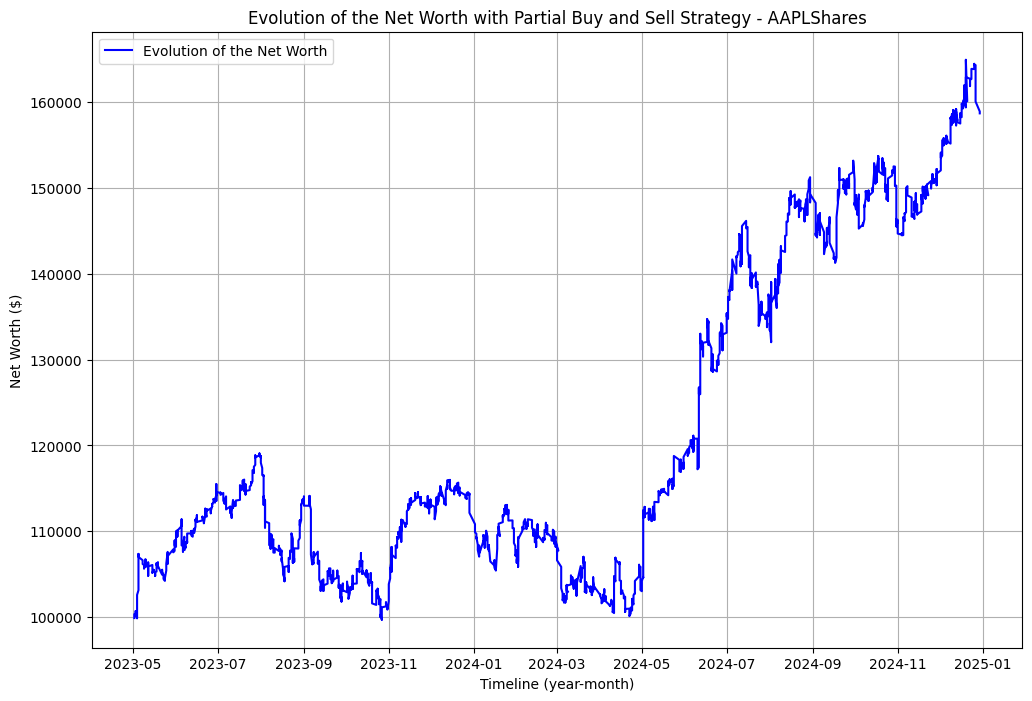

In [118]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(dates_list_test[-len(networth_strategy_test):], networth_strategy_test, label='Evolution of the Net Worth', color='blue')

plt.title('Evolution of the Net Worth with Partial Buy and Sell Strategy - ' + symbol + 'Shares')
plt.xlabel('Timeline (year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva e coeficiente para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

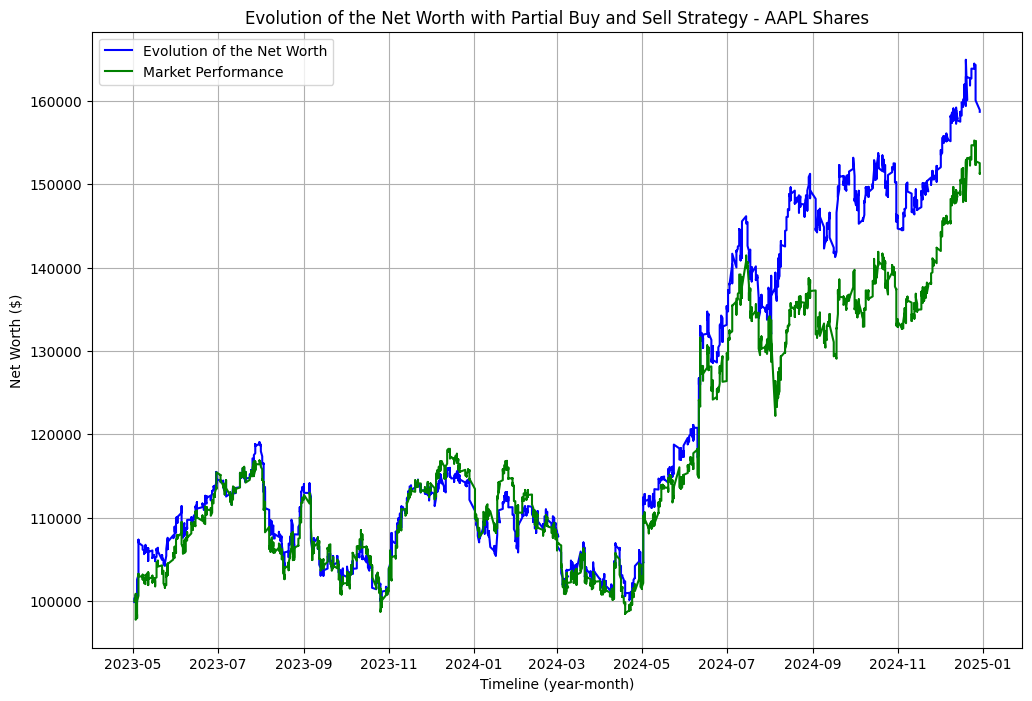

In [119]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(dates_list_test[-(len(networth_strategy_test)):], networth_strategy_test, label='Evolution of the Net Worth', color='blue')
plt.plot(last_subsets_dates_test, natural_fund_values_test, label='Market Performance', color='green')

plt.title('Evolution of the Net Worth with Partial Buy and Sell Strategy - ' + symbol + ' Shares')
plt.xlabel('Timeline (year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [120]:
print(f"Dinheiro extra ganho ao se ter usado AI: {fund_test - percentage_increase_test - final_value_test:.3f}$")

percentage_increase_AI_test = percentage_increase_strategy_test-percentage_increase_test
print(f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy_test-percentage_increase_test:.3f}%")

Dinheiro extra ganho ao se ter usado AI: 7462.096$

Melhoria percentual ao se ter usado AI: 7.513%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. A combinação valor da sensibilidade decisiva, coeficiente deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Coordenadas do valor máximo absoluto:
Data: 2024-08-07
Diferença Percentual Máxima: 13.44%
Average Percentage Difference between Net Worth and Market Price: 2.81%


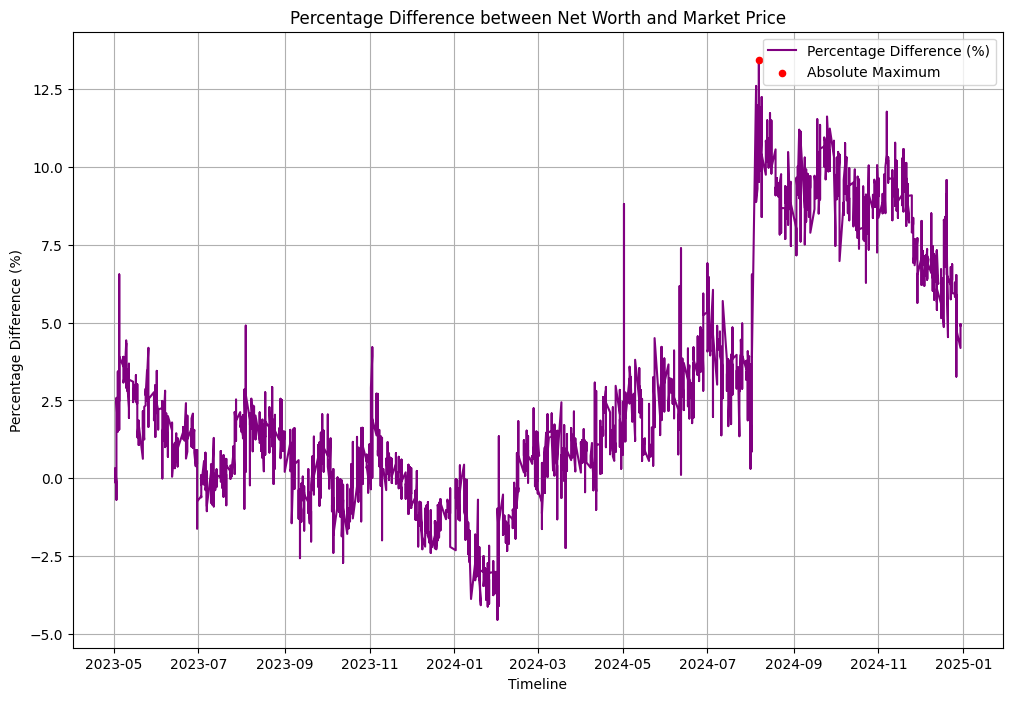

In [121]:
# Calcular a diferença percentual
diff_percentual_test = ((np.array(networth_strategy_test) - np.array(natural_fund_values_test)) / np.array(natural_fund_values_test)) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual_test)

# Coordenadas do valor máximo
max_diff_percentual_test = diff_percentual_test[max_index]
max_date_test = last_subsets_dates_test[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date_test}")
print(f"Diferença Percentual Máxima: {max_diff_percentual_test:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, diff_percentual_test, label='Percentage Difference (%)', color='purple')

# Adicionar o ponto máximo ao gráfico
plt.scatter(max_date_test, max_diff_percentual_test, color='red', s=20, zorder=5, label='Absolute Maximum')

# Rótulos e título
plt.title('Percentage Difference between Net Worth and Market Price')
plt.xlabel('Timeline')
plt.ylabel('Percentage Difference (%)')

# Calcular a média da diferença percentual
media_diff_percentual_test = np.mean(diff_percentual_test)

# Printar o valor médio
print(f"Average Percentage Difference between Net Worth and Market Price: {media_diff_percentual_test:.2f}%")

Results_Mean_array_test[1] = [sensibilidade_decisiva1_test, sensibilidade_decisiva2_test, coeficiente_c_test, coeficiente_v_test, percentage_increase_AI_test, media_diff_percentual_test]

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

In [122]:
# 1) Build your NAV Series from lists
values = pd.Series(
    data=networth_strategy_test,
    index=pd.to_datetime(last_subsets_dates_test),
    name="NAV"
).sort_index()

# 2) Compute period-to-period returns
returns = values.pct_change().dropna()

# 3) Estimate effective periods per year
P = estimate_periods_per_year(returns)

# 4) Build the metric functions for your frequency
metrics = make_metrics(P)

# —————————————————
# NEW: load & prepare your benchmark
bench_nav = pd.Series(
    data=natural_fund_values_test,
    index=pd.to_datetime(last_subsets_dates_test),
    name="Natural NAV"
).sort_index()

benchmark_returns = bench_nav.pct_change().dropna()

# 5) Define a (scalar) annual risk-free rate - Glabally define Above on the section of settings
#rf = 0.01  # e.g. 1% p.a.

# 6) Automatically run **all** metrics you can compute:
results = {}
for name, func in metrics.items():
    sig    = inspect.signature(func)
    params = list(sig.parameters)

    try:
        # If it expects (returns, benchmark_returns, rf)
        if params == ["returns", "benchmark_returns", "rf"]:
            results[name] = func(returns, benchmark_returns, rf)

        # If it expects only (returns, benchmark_returns)
        elif params == ["returns", "benchmark_returns"]:
            results[name] = func(returns, benchmark_returns)

        # If it expects (returns, rf)
        elif params == ["returns", "rf"]:
            results[name] = func(returns, rf)

        # Otherwise just (returns,)
        else:
            results[name] = func(returns)

    except Exception:
        results[name] = float("nan")

# 7) Display only the successfully computed metrics
print(pd.Series(results).dropna())

total_return                0.589050
annualized_return           0.260575
annualized_volatility       0.279930
sharpe_ratio                0.816322
sortino_ratio               0.859559
max_drawdown               -0.162775
drawdown_duration        1308.000000
ulcer_index                 7.254824
value_at_risk               0.011760
expected_shortfall          0.018221
calmar_ratio                1.600827
information_ratio           0.059546
beta                        0.345815
alpha                       0.169031
r_squared                   0.135361
treynor_ratio               0.629167
skewness                    0.723685
kurtosis                   11.532842
omega_ratio                 1.090154
dtype: float64


/tmp/ipython-input-1640029880.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return _capm_regression(returns, benchmark_returns, rf).params[1]
/tmp/ipython-input-1640029880.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = _capm_regression(returns, benchmark_returns, rf).params[0]
/tmp/ipython-input-1640029880.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return _capm_regression(returns, benchmark_returns, rf).pa

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

Coordenadas do ponto máximo absoluto: Dinheiro Inicial = $8081080.81, Percentual de Crescimento = -88.838%


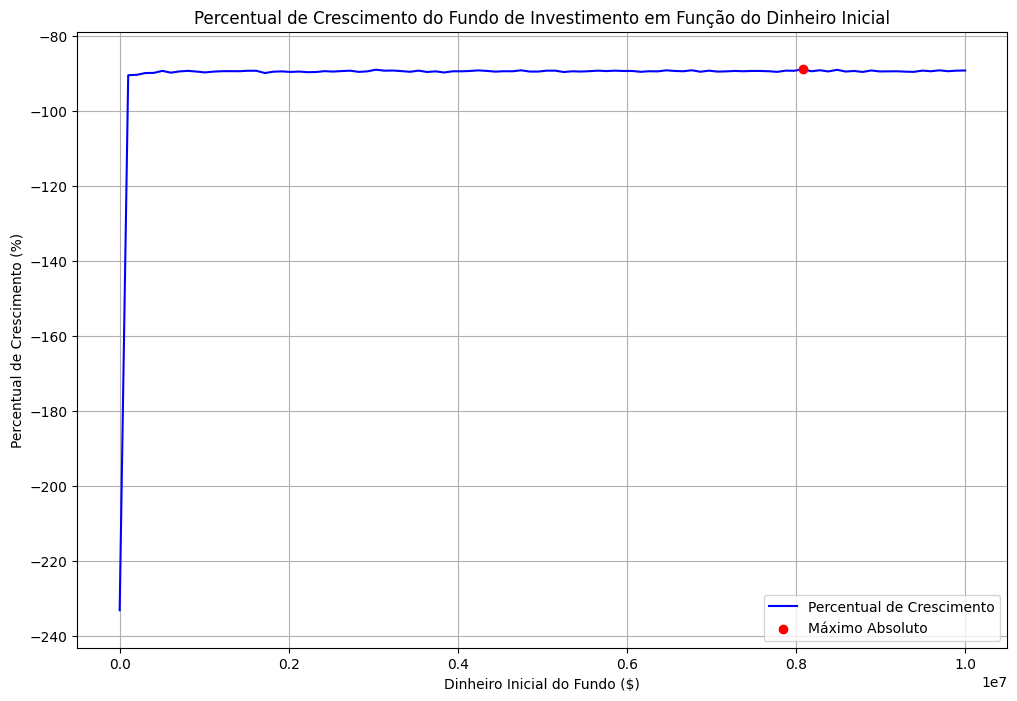

In [123]:
# Defina também os coeficientes para compra e venda (já devem estar definidos no seu contexto)
# Exemplo:
# coeficiente_c = 0.5  # Para determinar o percentual do fundo a investir na compra
# coeficiente_v = 0.5  # Para determinar o percentual das ações a vender

# Definir a faixa de valores para o fundo inicial
initial_fund_values_test = np.linspace(Min_Floor_Fund, Max_Selling_Fund + Step_money, Step_money)  # Valores de $50 a $10,000,000

# Lista para armazenar os resultados (percentual de crescimento para cada fundo inicial)
networth_results_test = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund_test = initial_fund
    num_shares_test = 0.0  # Número de ações atualmente detidas (permitindo frações)
    networth_strategy_test = []  # Armazenar a evolução do valor líquido (net worth) ao longo do tempo
    if Paid_Sun_Tzu:
        proxima_cobranca_test = last_subsets_dates_test[0]

    # Iterar pelo tensor (exceto o último que não possui previsão)
    for i in range(len(tensor_test_np) - 1):
        current_price = float(tensor_test_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_test_str = tensor_test_np[i][1]  # Previsão atual (grau de certeza)

        if Paid_Sun_Tzu:
            if proxima_cobranca_test <= last_subsets_dates_test[i]:
                proxima_cobranca_test = last_subsets_dates_test[i] + relativedelta(months=1)
                fund_test -= valor_cobranca_test

        # Converter a previsão para float, se possível, ou definir como 0 se for 'none'
        if prediction_test_str != 'none':
            prediction_test = float(prediction_test_str)
        else:
            prediction_test = 0

        # Se a previsão for maior que sensibilidade_decisiva2 e houver fundos, efetua COMPRA
        if prediction_test > sensibilidade_decisiva2_test and fund_test > 0:
            percentage_to_spend_test = coeficiente_c_test * max(0.0, min(1.0, (prediction_test - sensibilidade_decisiva2_test) / max(eps, 1 - sensibilidade_decisiva2_test)))  # Percentual do fundo a investir
            if percentage_to_spend_test > 1:
                percentage_to_spend_test = 1
            amount_to_spend_test = percentage_to_spend_test * fund_test
            exec_px = exec_price_with_slippage("buy", current_price_test, symbol)
            num_shares_to_buy_test = amount_to_spend_test / exec_px
            fund_test -= num_shares_to_buy_test * exec_px
            num_shares_test += num_shares_to_buy_test

        # Se a previsão for menor que sensibilidade_decisiva1 e houver ações, efetua VENDA
        elif prediction_test < sensibilidade_decisiva1_test and num_shares_test > 0:
            percentage_to_sell_test = coeficiente_v_test * max(0.0, min(1.0, (sensibilidade_decisiva1_test - prediction_test) / max(eps, sensibilidade_decisiva1_test)))  # Percentual de ações a vender
            if percentage_to_sell_test > 1:
                percentage_to_sell_test = 1
            amount_to_sell_test = percentage_to_sell_test * num_shares_test * current_price_test
            exec_px = exec_price_with_slippage("sell", current_price_test, symbol)
            amount_to_sell_test = min(amount_to_sell_test, num_shares_test * exec_px)
            SEC_fee_test = calculate_fee("sell", amount_to_sell_test * exec_px)
            shares_to_sell = amount_to_sell_test / exec_px
            fund_test += shares_to_sell * exec_px - SEC_fee_test
            num_shares_test -= shares_to_sell

        # Se a previsão estiver entre os thresholds, nenhuma operação é executada (posição mantida)

        # Calcular a net worth (fundo + valor das ações) e armazenar
        networth_test = fund_test + num_shares_test * current_price_test
        networth_strategy_test.append(networth_test)

    # No final do tensor, vender quaisquer ações remanescentes (se houver)
    if num_shares_test > 0:
        final_price_test = float(tensor_test_np[-1][0])
        exec_px = exec_price_with_slippage("sell", final_price_test, symbol)
        SEC_fee_test = calculate_fee("sell", num_shares_test * exec_px)
        fund_test += num_shares_test * exec_px - SEC_fee_test
        num_shares_test = 0
    networth_strategy_test.append(fund_test)

    # Calcular o percentual de crescimento da estratégia para este fundo inicial
    percentage_increase_strategy_test = ((fund_test - initial_fund) / initial_fund) * 100
    networth_results_test.append(percentage_increase_strategy_test)

# Encontrar o fundo inicial que gerou o maior percentual de crescimento
max_index = np.argmax(networth_results_test)
max_initial_fund = initial_fund_values_test[max_index]
max_percentage_increase = networth_results_test[max_index]

print(f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%")

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(initial_fund_values_test, networth_results_test, label='Percentual de Crescimento', color='blue')
plt.scatter(max_initial_fund, max_percentage_increase, color='red', zorder=5, label="Máximo Absoluto")  # Destacar o ponto máximo

# Ajustar os limites do eixo Y
plt.ylim(min(networth_results_test) - 10, max(networth_results_test) + 10)

plt.title('Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial')
plt.xlabel('Dinheiro Inicial do Fundo ($)')
plt.ylabel('Percentual de Crescimento (%)')
plt.grid(True)
plt.legend()
plt.show()

# **Results Sem Short-Selling**

### **Otimization**

Aqui podes comprar todas as estratégias testadas anteriormente sem short selling lado a lado para teres uma melhor visão comprativa de qual funciona melhor.

In [124]:
def print_header(title):
    """Prints a header with an underline."""
    print(title)
    print("-" * len(title))

def print_section(title):
    """Prints a section header followed by a blank line."""
    print_header(title)
    print()

def print_formatted_result(prefix, values, formats):
    """
    Given a prefix and a list of (label, value) pairs with associated formats,
    prints the values in a formatted string.
    """
    formatted_parts = [f"{label}={fmt.format(value)}" for (label, value), fmt in zip(values, formats)]
    print(f"  {prefix}: " + "; ".join(formatted_parts))

In [125]:
# Main Market Growth Information
print(f'Crescimento Natural do Mercado Entre {last_subsets_dates_otimization[0]} e {last_subsets_dates_otimization[-1]}, Dataset de otimização, para ações {symbol}:')
print(f'{percentage_increase_otimization:.5f}%\n')

print_section("Sem Short-Selling:")

# Optimization based on Mean Percentage Difference
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")

print("Absolute Buy and Sell:")
print(f"  Sensibilidade Decisiva 1 = {Results_Mean_array[0][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_array[0][1]:.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_array[0][2]:.5f}\n")

print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(f"  Sensibilidade Decisiva 1 = {Results_Mean_array[1][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_array[1][1]:.2f}; "
      f"Coeficiente de Compra = {Results_Mean_array[1][2]:.2f}; "
      f"Coeficiente de Venda = {Results_Mean_array[1][3]:.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_array[1][4]:.5f}\n")

# Optimization based on Last Date Percentage Difference
print_section("Resultados ao Otimizar em Função da Diferença Percentual da Última Data")

print("Absolute Buy and Sell:")
print(f"  Sensibilidade Decisiva 1 = {Results_Last_array[0][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Last_array[0][1]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Last_array[0][2] + percentage_increase_otimization):.5f}; "
      f"Diferença Percentual = {Results_Last_array[0][2]:.5f}\n")

print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(f"  Sensibilidade Decisiva 1 = {Results_Last_array[1][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Last_array[1][1]:.2f}; "
      f"Coeficiente de Compra = {Results_Last_array[1][2]:.2f}; "
      f"Coeficiente de Venda = {Results_Last_array[1][3]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Last_array[1][4] + percentage_increase_otimization):.5f}; "
      f"Diferença Percentual = {Results_Last_array[1][4]:.5f}")

Crescimento Natural do Mercado Entre 2023-05-02 e 2024-12-30, Dataset de otimização, para ações AAPL:
51.18941%

Sem Short-Selling:
------------------

Resultados ao Otimizar em Função da Média da Diferença Percentual
-----------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1 = 0.12; Sensibilidade Decisiva 2 = 0.76; Média da Diferença Percentual = 0.35978

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 1 = 1.00; Sensibilidade Decisiva 2 = 0.00; Coeficiente de Compra = 2.00; Coeficiente de Venda = 2.00; Média da Diferença Percentual = 9.81638

Resultados ao Otimizar em Função da Diferença Percentual da Última Data
-----------------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1 = 0.00; Sensibilidade Decisiva 2 = 0.73; Ganho Percentual da Estratégia = 52.87191; Diferença Percentual = 1.68250

Independent Parcial Buy and Sel

### **Test**

In [126]:
# Main Market Growth Information
print(f'Crescimento Natural do Mercado Entre {last_subsets_dates_test[0]} e {last_subsets_dates_test[-1]}, Dataset de test, para ações {symbol}:')
print(f'{percentage_increase_test:.5f}%\n')

print_section("Sem Short-Selling:")

# Optimization based on Mean Percentage Difference
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")

print("Absolute Buy and Sell:")
print(f"  Sensibilidade Decisiva 1 = {Results_Mean_array_test[0][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_array_test[0][1]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Mean_array_test[0][2] + percentage_increase_test):.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_array_test[0][3]:.5f}\n")

print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(f"  Sensibilidade Decisiva 1 = {Results_Mean_array_test[1][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_array_test[1][1]:.2f}; "
      f"Coeficiente de Compra = {Results_Mean_array_test[1][2]:.2f}; "
      f"Coeficiente de Venda = {Results_Mean_array_test[1][3]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Mean_array_test[1][4] + percentage_increase_test):.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_array_test[1][5]:.5f}\n")

Crescimento Natural do Mercado Entre 2023-05-02 e 2024-12-30, Dataset de test, para ações AAPL:
51.18941%

Sem Short-Selling:
------------------

Resultados ao Otimizar em Função da Média da Diferença Percentual
-----------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1 = 0.12; Sensibilidade Decisiva 2 = 0.76; Ganho Percentual da Estratégia = 44.91; Média da Diferença Percentual = 3.14975

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 1 = 1.00; Sensibilidade Decisiva 2 = 0.00; Coeficiente de Compra = 2.00; Coeficiente de Venda = 2.00; Ganho Percentual da Estratégia = 58.70; Média da Diferença Percentual = 2.81191



# **Estratégias de Gestão do Portefólio de Investimentos Com Short-Selling**

Aqui seram estudadas todas as possíveis estratégias de gestão de portefólio com o modelo usando short-selling. Para estudar as seguintes estratégias será criado um portefólio virtual com 100 000$ que será gerido usando o modelo para prever o mercado e a respetiva estratégia de gestão de portefólio que estará a ser estudada. Isto permite simular o mais aproximado ppossível a gestão real de um portefólio com o modelo desenvolvido no alpaca e a estratégia escolhida e desenvolvida pelo SunTzu.

É imporante destacar que a networth de um portefólio é dado pela seguinte função:

Networth(localização temporal; modelo; estratégia; ativo; valor inicial = 100 000$$) = Valor_do_ativo_comprado(localização temporal atual; ativo; quantidade do ativo) + Valor_Liquido_Guardado(localização temporal atual; modelo; estratégia; valor inicial = 100 000$) + Posição_short_selling(localização temporal da realização do short-selling; ativo; quantidade do ativo) - Ativo_short_selled(localização temporal atual; ativo; quantidade do ativo)

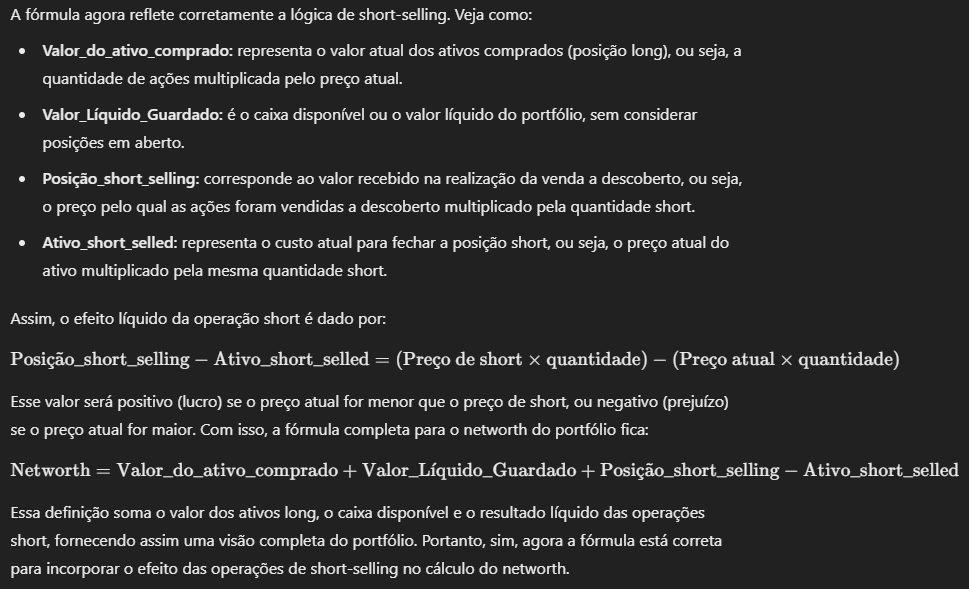

Temos de fazer alguns ajustes á estratégia de trading:

1. O número máximo de ações ás quais dás short-selling em valor numerário tem de corresponder ao valor de dinheiro liquido do portifólio.

2. Para calcular a networth do portfólio o valor de uma operação short-selling apenas deve contar para a networth após o short-selling ser coberto, até lá o dinheiro adquirido com a posição short-selled não deve entrar para o calculo da networth do portefólio.

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

Sensibilidade Decisiva trata-se do valor decimal que estipula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

Iniciar os arrays de resultados para guardar os resultados das estretégias estudadas.

In [127]:
Results_Last_cS_array = []
Results_Mean_cS_array = []
Results_Mean_cS_array_test = []

Results_Last_cS_array.extend([None] * (2))
Results_Mean_cS_array.extend([None] * (2))
Results_Mean_cS_array_test.extend([None] * (2))

## **Absolute Buy and Sell com Short-Selling**

Comprar em absoluto, ou seja, gastar todo o dinheiro da carteira ao primeiro sinal positivo "1". Buy and Hold, ou seja, manter todo o dinheiro nas ações uma vez executada a compra, até o sinal positivo "1" se alterar. Vender em absoluto, ou seja, vender todo o dinheiro das ações ao primeiro sinal negativo "0" e aplicar um posição short-selling, manter a posição short-selling até o sinal negativo "0" se alterar. Repetir infinitamente o processo.

### **Otimization**



**Estudo da Melhor Sensibilidade Decisiva:**

Sensibilidade Decisiva trata-se do valor decimal que estibula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

A seguir, apresento o código atualizado com a nova lógica para calcular a média da diferença percentual ao longo do tempo, incorporando o short-selling conforme as seguintes regras:

Ao abrir uma posição short, a quantidade vendida é determinada com base no dinheiro líquido disponível (isto é,
  num_shares_to_short = fund_strategy / current_price), mas os proceeds da venda não são creditados ao fundo (ficam bloqueados como garantia).

Enquanto a posição short estiver aberta, o short não afeta a networth (que é calculada como o valor do fundo mais os ativos long, isto é,
  networth = fund_strategy + num_shares_strategy * current_price).

Quando a posição short é coberta (por uma previsão forte positiva), o lucro ou prejuízo da operação short é realizado (calculado como
  num_shares_short_strategy * (short_sale_price_strategy - current_price)) e somado ao fundo.

O código abaixo utiliza essas regras para calcular, em cada iteração do tensor, a evolução da networth da estratégia e, ao final, a média da diferença percentual em relação à estratégia natural (representada por natural_fund_values):

Explicação dos pontos principais:
Operação Long:
Se a previsão for alta (acima do threshold) e houver caixa disponível, antes de comprar ações o código verifica se há um short aberto. Se houver, a posição short é coberta – realizando o lucro ou prejuízo (que é então adicionado ao fundo) – e somente depois a compra long é executada.

Operação Short:
Se a previsão for fortemente negativa (abaixo de
−
−threshold), se houver uma posição long, ela é vendida para liberar caixa. Em seguida, se não houver short aberto, o short é iniciado. A quantidade vendida é definida por num_shares_to_short = fund_strategy / current_price e os proceeds não são creditados ao fundo (o dinheiro permanece bloqueado como garantia).

Cálculo da Networth:
Enquanto uma posição short estiver aberta, o valor da operação short não entra na networth (ela é calculada apenas como fund_strategy + num_shares_strategy * current_price). Só ao fechar o short o efeito (lucro ou prejuízo) é realizado e incorporado ao fundo.

Cálculo da Diferença Percentual:
Para cada valor de sensibilidade, é calculada a média da diferença percentual entre a evolução da networth da estratégia AI e a estratégia natural (valores em natural_fund_values).

In [128]:
percentages_diference_array_otimization = []
media_diff_percentual_array_otimization = []  # Armazenar as médias das diferenças

sd1_list_otimization = []
sd2_list_otimization = []

total_iterations = len(sensibilidade_decisiva1_array_otimization) * len(sensibilidade_decisiva2_array_otimization)
iteration = 0

# Loop sobre todas as combinações válidas: garantimos que sd1 < sd2
for sd1 in sensibilidade_decisiva1_array_otimization:
    for sd2 in sensibilidade_decisiva2_array_otimization:
        iteration += 1
        print(f"\rProgress: {(iteration/total_iterations*100):.2f}%", end='')
        sys.stdout.flush()

        # Inicializar variáveis para esta combinação de thresholds
        initial_fund = Initial_Funds  # Fundo inicial de $100,000
        fund = initial_fund
        num_shares = 0.0       # Posição long (ações compradas)
        num_shares_short = 0.0 # Posição short (ações vendidas a descoberto)
        short_sale_price = 0.0 # Preço de abertura da operação short
        networth_strategy = [] # Evolução da networth ao longo do tempo
        if Paid_Sun_Tzu:
            proxima_cobranca = last_subsets_dates_otimization[0]

        # Iterar pelo tensor (exceto o último que não tem previsão)
        for i in range(len(tensor_otimization_np) - 1):
            current_price = float(tensor_otimization_np[i + 1][0])
            prediction_str = tensor_otimization_np[i][1]

            if Paid_Sun_Tzu:
                if proxima_cobranca <= last_subsets_dates_otimization[i]:
                    proxima_cobranca = last_subsets_dates_otimization[i] + relativedelta(months=1)
                    fund -= valor_cobranca_otimization

            if prediction_str != 'none':
                prediction = float(prediction_str)
            else:
                # Se não houver previsão, pular o período (ou alternativamente repetir o último valor)
                continue

            # Operação de COMPRA (posição long) se a previsão for alta: > sensibilidade_decisiva2
            if prediction > sd2 and fund > 0:
                # Se houver posição short aberta, cobrir primeiro
                if num_shares_short > 0:
                    exec_px = exec_price_with_slippage("cover", current_price, symbol)
                    SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_otimization[i])
                    profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
                    fund -= num_shares_short * exec_px + SEC_fee
                    num_shares_short = 0.0
                    short_sale_price = 0.0
                # Comprar ações com o fundo disponível
                if fund > 0:
                    amount_to_invest = fund
                    exec_px = exec_price_with_slippage("buy", current_price, symbol)
                    num_shares_to_buy = amount_to_invest / exec_px
                    fund -= num_shares_to_buy * current_price
                    num_shares += num_shares_to_buy

            # Operação de VENDA/SHORT se a previsão for baixa: < sensibilidade_decisiva1
            elif prediction < sd1:
                # Se houver posição long, vende para liberar caixa
                if num_shares > 0:
                    exec_px = exec_price_with_slippage("sell", current_price, symbol)
                    proceeds = num_shares * exec_px
                    SEC_fee = calculate_fee("sell", proceeds)
                    fund += proceeds - SEC_fee
                    num_shares = 0.0
                # Iniciar operação short se houver caixa e nenhuma posição short ainda aberta
                if fund > 0 and num_shares_short == 0:
                    time_at_short = last_subsets_dates_otimization[i]
                    exec_px = exec_price_with_slippage("short", current_price, symbol)
                    num_shares_to_short = fund / exec_px
                    # Não creditamos o valor, pois o fundo permanece bloqueado como garantia
                    num_shares_short = num_shares_to_short
                    short_sale_price = exec_px
                    SEC_fee = calculate_fee("short", num_shares_to_short * exec_px)
                    fund += num_shares_to_short * exec_px - SEC_fee
            else:
                # Zona neutra: nenhuma operação
                pass

            # Calcular a networth do período (considerando somente o fundo e as ações long)
            current_networth = fund + num_shares * current_price - num_shares_short * current_price
            networth_strategy.append(current_networth)

        # Ao final do tensor, fechar quaisquer posições abertas
        final_price = float(tensor_otimization_np[-1][0])
        # Fechar posição long, se houver
        if num_shares > 0:
            exec_px = exec_price_with_slippage("sell", final_price, symbol)
            proceeds = num_shares * exec_px
            SEC_fee = calculate_fee("sell", proceeds)
            fund += proceeds - SEC_fee
            num_shares = 0.0
        # Fechar posição short, se houver (calculando lucro/prejuízo)
        if num_shares_short > 0:
            exec_px = exec_price_with_slippage("cover", final_price, symbol)
            SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_otimization[-1])
            profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
            fund -= num_shares_short * exec_px + SEC_fee
            num_shares_short = 0.0
            short_sale_price = 0.0

        # Cálculo final da networth (todas as posições fechadas)
        networth = fund
        percentage_increase_strategy = ((networth - initial_fund) / initial_fund) * 100

        # Registrar a diferença percentual em relação à estratégia natural
        percentages_diference_array_otimization.append(percentage_increase_strategy - percentage_increase_otimization)
        networth_strategy.append(fund)

        # Calcular a diferença percentual entre a estratégia AI e a estratégia natural
        diff_percentual = ((np.array(networth_strategy) - np.array(natural_fund_values_otimization)) / np.array(natural_fund_values_otimization)) * 100
        media_diff_percentual = np.mean(diff_percentual)
        media_diff_percentual_array_otimization.append(media_diff_percentual)

        sd1_list_otimization.append(sd1)
        sd2_list_otimization.append(sd2)

Progress: 100.00%

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva utilizada sinalarizará a melhor sensibilidade decisiva para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor sensibilidade decisiva.

Top 1 point: Sensibilidade Decisiva 1 = 0.20, Sensibilidade Decisiva 2 = 0.80, Percentage Improvement = 1.26%
Top 2 point: Sensibilidade Decisiva 1 = 0.20, Sensibilidade Decisiva 2 = 0.60, Percentage Improvement = 1.02%
Top 3 point: Sensibilidade Decisiva 1 = 0.00, Sensibilidade Decisiva 2 = 0.00, Percentage Improvement = -1.99%

Absolute maximum of the interpolated surface:
  Sensibilidade Decisiva 1 = 0.17
  Sensibilidade Decisiva 2 = 0.70
  Percentage Improvement   = 12.13%


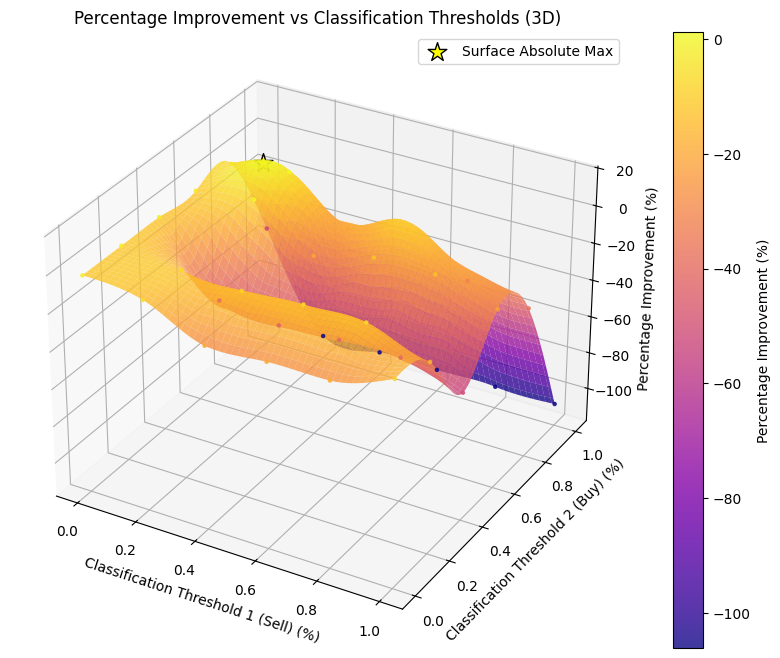

In [129]:
# --- Converter as listas para arrays NumPy ---
sd1_vals = np.array(sd1_list_otimization)                 # Sensibilidade Decisiva 1 (Venda)
sd2_vals = np.array(sd2_list_otimization)                 # Sensibilidade Decisiva 2 (Compra)
perc_diff = np.array(percentages_diference_array_otimization)  # Melhoria Percentual

# --- Identificar os 3 melhores pontos nos dados originais ---
top3_indices = np.argsort(perc_diff)[-3:][::-1]  # índices dos 3 maiores valores

# Imprimir coordenadas e valores dos 3 melhores pontos
for rank, idx in enumerate(top3_indices, start=1):
    sd1_top = sd1_vals[idx]
    sd2_top = sd2_vals[idx]
    perc_top = perc_diff[idx]
    print(f"Top {rank} point: Sensibilidade Decisiva 1 = {sd1_top:.2f}, "
          f"Sensibilidade Decisiva 2 = {sd2_top:.2f}, "
          f"Percentage Improvement = {perc_top:.2f}%")

# --- Criar grade regular e interpolar superfície (cubic) ---
xi = np.linspace(sd1_vals.min(), sd1_vals.max(), 100)
yi = np.linspace(sd2_vals.min(), sd2_vals.max(), 100)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((sd1_vals, sd2_vals), perc_diff, (xi, yi), method='cubic')

# --- Encontrar máximo absoluto da superfície interpolada ---
max_idx = np.nanargmax(zi)
max_i, max_j = np.unravel_index(max_idx, zi.shape)
max_sd1 = xi[max_i, max_j]
max_sd2 = yi[max_i, max_j]
max_perc = zi[max_i, max_j]

print("\nAbsolute maximum of the interpolated surface:")
print(f"  Sensibilidade Decisiva 1 = {max_sd1:.2f}")
print(f"  Sensibilidade Decisiva 2 = {max_sd2:.2f}")
print(f"  Percentage Improvement   = {max_perc:.2f}%")

# --- Plot 3D ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# superfície interpolada
surf = ax.plot_surface(xi, yi, zi, cmap='plasma', alpha=0.8, edgecolor='none')

# pontos originais
sc = ax.scatter(sd1_vals, sd2_vals, perc_diff, c=perc_diff, cmap='plasma', s=5, alpha=0.8)

# destacar máximo absoluto da superfície
ax.scatter(max_sd1, max_sd2, max_perc,
           color='yellow', s=200, marker='*', edgecolors='black',
           label='Surface Absolute Max')

Results_Last_cS_array[0] = [max_sd1, max_sd2, max_perc]

# rótulos e título
ax.set_title('Percentage Improvement vs Classification Thresholds (3D)')
ax.set_xlabel('Classification Threshold 1 (Sell) (%)')
ax.set_ylabel('Classification Threshold 2 (Buy) (%)')
ax.set_zlabel('Percentage Improvement (%)')

# barra de cores
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Percentage Improvement (%)')

ax.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a sensibilidade decisiva que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor sensibilidade decisiva parqa este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

Top 1 point: Sensibilidade Decisiva 1 = 0.20, Sensibilidade Decisiva 2 = 0.80, Mean Percentage Difference = 6.36%
Top 2 point: Sensibilidade Decisiva 1 = 0.20, Sensibilidade Decisiva 2 = 0.00, Mean Percentage Difference = 2.27%
Top 3 point: Sensibilidade Decisiva 1 = 1.00, Sensibilidade Decisiva 2 = 0.00, Mean Percentage Difference = 0.94%

Absolute maximum of the interpolated surface:
  Sensibilidade Decisiva 1 = 0.17
  Sensibilidade Decisiva 2 = 0.76
  Mean Percentage Difference   = 7.30%


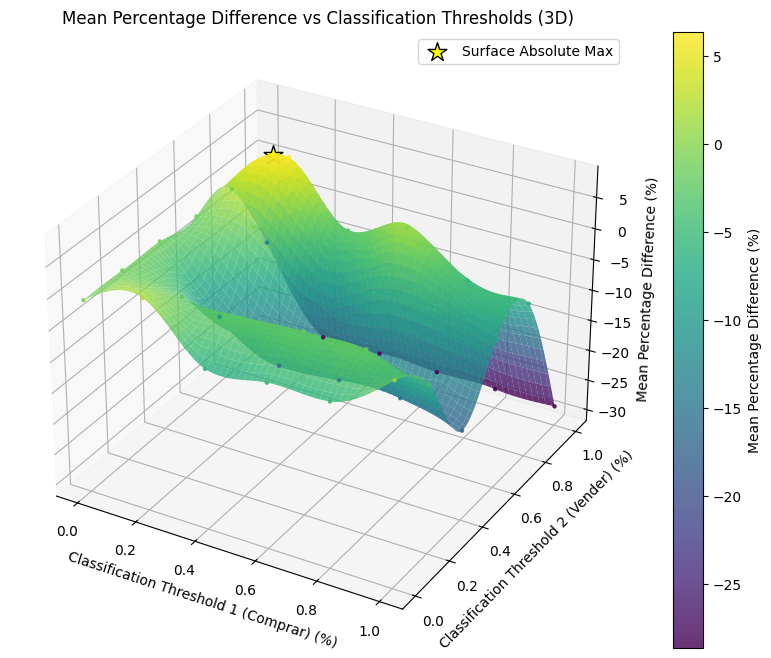

In [130]:
# --- Converter as listas para arrays NumPy ---
sd1_vals = np.array(sd1_list_otimization)                 # Sensibilidade Decisiva 1 (Venda)
sd2_vals = np.array(sd2_list_otimization)                 # Sensibilidade Decisiva 2 (Compra)
media_diff_vals = np.array(media_diff_percentual_array_otimization)  # Média Diferença Percentual

# --- Identificar e imprimir os 3 melhores pontos nos dados originais ---
top3_indices = np.argsort(media_diff_vals)[-3:][::-1]  # índices dos 3 maiores valores
colors = ['red', 'green', 'blue']

for rank, idx in enumerate(top3_indices, start=1):
    sd1_best = sd1_vals[idx]
    sd2_best = sd2_vals[idx]
    media_diff_best = media_diff_vals[idx]
    print(f"Top {rank} point: Sensibilidade Decisiva 1 = {sd1_best:.2f}, "
          f"Sensibilidade Decisiva 2 = {sd2_best:.2f}, "
          f"Mean Percentage Difference = {media_diff_best:.2f}%")

# --- Criar grade regular e interpolar superfície (cubic) ---
xi = np.linspace(sd1_vals.min(), sd1_vals.max(), 100)
yi = np.linspace(sd2_vals.min(), sd2_vals.max(), 100)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((sd1_vals, sd2_vals), media_diff_vals, (xi, yi), method='cubic')

# --- Encontrar e imprimir o máximo absoluto da superfície interpolada ---
max_idx = np.nanargmax(zi)
max_i, max_j = np.unravel_index(max_idx, zi.shape)
max_sd1 = xi[max_i, max_j]
max_sd2 = yi[max_i, max_j]
max_media_diff = zi[max_i, max_j]

print("\nAbsolute maximum of the interpolated surface:")
print(f"  Sensibilidade Decisiva 1 = {max_sd1:.2f}")
print(f"  Sensibilidade Decisiva 2 = {max_sd2:.2f}")
print(f"  Mean Percentage Difference   = {max_media_diff:.2f}%")

# --- Plot 3D ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# superfície interpolada
surf = ax.plot_surface(xi, yi, zi, cmap='viridis', alpha=0.8, edgecolor='none')

# pontos originais
sc = ax.scatter(sd1_vals, sd2_vals, media_diff_vals,
                c=media_diff_vals, cmap='viridis', s=5, alpha=0.8)

# destacar o máximo absoluto da superfície interpolada
ax.scatter(max_sd1, max_sd2, max_media_diff,
           color='yellow', s=200, marker='*', edgecolors='black',
           label='Surface Absolute Max')

# opcional: armazenar no segundo slot do array
Results_Mean_cS_array[0] = [max_sd1, max_sd2, max_media_diff]

# rótulos e título
ax.set_title('Mean Percentage Difference vs Classification Thresholds (3D)')
ax.set_xlabel('Classification Threshold 1 (Comprar) (%)')
ax.set_ylabel('Classification Threshold 2 (Vender) (%)')
ax.set_zlabel('Mean Percentage Difference (%)')

# barra de cores
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Mean Percentage Difference (%)')

ax.legend()
plt.show()

### **Test**

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para um valor em especifico de sensibilidade decisiva.

Geralmente a ideia é analisar detalhadamente o que é que acontec com o valor considerado ideal encotrado anteriormente.

Escolhe-se o valor da sensibilidade decisiva que se quer estudar.

In [131]:
sensibilidade_decisiva1_test = Results_Mean_cS_array[0][0]
print(f"Sensibilidade Decisiva 1: {sensibilidade_decisiva1_test}")
sensibilidade_decisiva2_test = Results_Mean_cS_array[0][1]
print(f"Sensibilidade Decisiva 2: {sensibilidade_decisiva2_test}")

Sensibilidade Decisiva 1: 0.17171717171717174
Sensibilidade Decisiva 2: 0.7575757575757577


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [132]:
# Inicializar variáveis
initial_fund = Initial_Funds  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0              # Posição long (ações compradas)
num_shares_short = 0.0        # Posição short (ações vendidas a descoberto)
short_sale_price = 0.0        # Preço de abertura da operação short
total_ops = 0.0               # Valor total das operações realizadas
networth_strategy_array = []
Total_Fees = 0
Total_Borrowings = 0
Total_Slippage = 0
if Paid_Sun_Tzu:
    proxima_cobranca = last_subsets_dates_test[0]
    total_cobrancas = 0

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_test_np) - 1):
    current_price = float(tensor_test_np[i + 1][0])  # Preço da ação para a operação
    prediction_raw = tensor_test_np[i][1]              # Previsão atual

    if Paid_Sun_Tzu:
        if proxima_cobranca <= last_subsets_dates_test[i]:
            proxima_cobranca = last_subsets_dates_test[i] + relativedelta(months=1)
            fund -= valor_cobranca_test
            total_cobrancas += 1
            print(f"Custo do Alpaca cobrado: ${valor_cobranca_test:.2f}")
            print(f"Fundo restante: ${fund:.2f}")

    if prediction_raw != 'none':
        prediction = float(prediction_raw)
    else:
        prediction = 0.0

    # Determinar sinal para debug:
    if prediction > sensibilidade_decisiva2:
        signal = 1
    elif prediction < sensibilidade_decisiva1:
        signal = -1
    else:
        signal = 0

    # Operação LONG: se previsão > sensibilidade_decisiva2 e houver fundos disponíveis
    if prediction > sensibilidade_decisiva2 and fund > 0:
        # Se houver posição short aberta, cobrir primeiro
        if num_shares_short > 0:
            exec_px = exec_price_with_slippage("cover", current_price, symbol)
            SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_test[i])
            Slippage_Cost = num_shares_short * (exec_px - current_price)
            Total_Borrowings += SEC_fee
            Total_Slippage += Slippage_Cost
            profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
            fund -= num_shares_short * exec_px + SEC_fee
            total_ops += num_shares_short * exec_px  # valor da operação de cobertura
            print(f"[Período {i}] COBERTURA SHORT: Fechado {num_shares_short:.6f} ações short a {exec_px:.2f} por ${num_shares_short * exec_px:.2f}, borrowing rate = ${SEC_fee:.2f}, slippage custo = ${Slippage_Cost:.2f}. Lucro/Prejuízo: ${profit:.2f}. Novo fundo: ${fund:.2f}.")
            num_shares_short = 0.0
            short_sale_price = 0.0

        # Comprar ações (posição long)
        if fund > 0:
            amount_to_invest = fund
            exec_px = exec_price_with_slippage("buy", current_price, symbol)
            num_shares_to_buy = amount_to_invest / exec_px
            cost = num_shares_to_buy * exec_px
            Slippage_Cost = num_shares_to_buy * (exec_px - current_price)
            Total_Slippage += Slippage_Cost
            Total_Borrowings += SEC_fee
            fund -= cost
            total_ops += cost
            num_shares += num_shares_to_buy
            print(f"[Período {i}] COMPRA LONG: Comprado {num_shares_to_buy:.6f} ações a {exec_px:.2f} por ${cost:.2f}, slippage custo = ${Slippage_Cost:.2f}. Liquidez: ${fund:.2f}.")

    # Operação VENDA/SHORT: se previsão < sensibilidade_decisiva1
    elif prediction < sensibilidade_decisiva1:
        # Se houver posição long, vender para liberar caixa
        if num_shares > 0:
            exec_px = exec_price_with_slippage("sell", current_price, symbol)
            proceeds = num_shares * exec_px
            SEC_fee = calculate_fee("sell", proceeds)
            Slippage_Cost = num_shares * (current_price - exec_px)
            Total_Slippage += Slippage_Cost
            Total_Fees += SEC_fee
            fund += proceeds - SEC_fee
            total_ops += proceeds
            print(f"[Período {i}] VENDA LONG: Vendido {num_shares:.6f} ações a {exec_px:.2f} por ${proceeds:.2f}, taxas SEC = ${SEC_fee:.2f}, slippage custo = ${Slippage_Cost:.2f}. Liquidez: ${fund:.2f}.")
            num_shares = 0.0
        # Se não houver posição long e nem short aberta, iniciar operação short
        if num_shares == 0 and num_shares_short == 0 and fund > 0:
            exec_px = exec_price_with_slippage("short", current_price, symbol)
            num_shares_to_short = fund / exec_px
            total_ops += num_shares_to_short * exec_px
            num_shares_short = num_shares_to_short
            short_sale_price = exec_px
            SEC_fee = calculate_fee("short", num_shares_to_short * exec_px)
            Slippage_Cost = num_shares_to_short * (current_price - exec_px)
            Total_Slippage += Slippage_Cost
            time_at_short = last_subsets_dates_test[i]
            Total_Fees += SEC_fee
            fund += num_shares_to_short * exec_px - SEC_fee
            print(f"[Período {i}] ABERTURA SHORT: Vendido a descoberto {num_shares_to_short:.6f} ações a {exec_px:.2f} por ${num_shares_to_short * exec_px:.2f}, taxa SEC = ${SEC_fee:.2f}, slippage custo = ${Slippage_Cost:.2f}. (Fundo permanece: ${fund:.2f}).")
    else:
        # Zona neutra: nenhuma operação
        print(f"[Período {i}] SEM OPERAÇÃO: Previsão {prediction:.5f} está na zona neutra. Liquidez: ${fund:.2f}.")

    # Cálculo da networth do portfólio (contando somente o fundo e posições long)
    current_networth = fund + num_shares * current_price - num_shares_short * current_price
    print(f"[Período {i}] Networth: ${current_networth:.2f} | Preço: {current_price:.2f} | Prediction: {prediction:.5f} | Sinal: {signal}")
    networth_strategy_array.append(current_networth)

# Ao final do tensor, fechar quaisquer posições abertas:
final_price = float(tensor_test_np[-1][0])

# Fechar posição long, se houver
if num_shares > 0:
    exec_px = exec_price_with_slippage("sell", current_price, symbol)
    proceeds = num_shares * exec_px
    SEC_fee = calculate_fee("sell", proceeds)
    Slippage_Cost = num_shares * (final_price - exec_px)
    Total_Slippage += Slippage_Cost
    Total_Fees += SEC_fee
    fund += proceeds - SEC_fee
    total_ops += proceeds
    print(f"[Final] FECHAMENTO LONG: Vendido {num_shares:.6f} ações a {exec_px:.2f} por ${proceeds:.2f}, taxa SEC = ${SEC_fee:.2f}, slippage custo = ${Slippage_Cost:.2f}.")
    num_shares = 0.0

# Fechar posição short, se houver (realizando lucro ou prejuízo do short)
if num_shares_short > 0:
    exec_px = exec_price_with_slippage("cover", current_price, symbol)
    SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_test[-1])
    Total_Borrowings += SEC_fee
    Slippage_Cost = num_shares_short * (exec_px - final_price)
    Total_Slippage += Slippage_Cost
    profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
    fund -= num_shares_short * final_price + SEC_fee
    total_ops += num_shares_short * exec_px  # valor da operação de cobertura
    print(f"[Final] FECHAMENTO SHORT: Fechado {num_shares_short:.6f} ações short a {exec_px:.2f} por ${num_shares_short * final_price:.2f}, borrowing rate = ${SEC_fee:.2f}, slippage custo = ${Slippage_Cost:.2f}. Lucro/Prejuízo: ${profit:.2f}.")
    num_shares_short = 0.0
    short_sale_price = 0.0

print(f"Data de ínicio da simulação: {last_subsets_dates_test[0]}. Data de fim da simulação: {last_subsets_dates_test[-1]}")
print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")
print(f"Total de Borrowing rates pagos: ${Total_Borrowings:.2f}")
print(f"Total de Slippage pagos: ${Total_Slippage:.2f}")
print(f"Total de Fees pagos: ${Total_Fees:.2f}")
if Paid_Sun_Tzu:
    print(f"Data da primeira cobrança Alpaca: {last_subsets_dates_test[0]}. Total de cobranças do Alpaca: {total_cobrancas}. Valor gasto: ${total_cobrancas*valor_cobranca_test}")
networth_strategy_array.append(fund)
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(f"Percentual de crescimento do fundo com a estratégia: {percentage_increase_strategy:.3f}%")
print(f"Valor Total das Operações Realizadas: ${total_ops:.2f}")

Streaming output truncated to the last 5000 lines.
[Período 395] VENDA LONG: Vendido 666.433467 ações a 183.43 por $122247.19, taxas SEC = $3.40, slippage custo = $36.69. Liquidez: $122243.79.
[Período 395] ABERTURA SHORT: Vendido a descoberto 666.414941 ações a 183.43 por $122243.79, taxa SEC = $3.40, slippage custo = $36.68. (Fundo permanece: $244484.19).
[Período 395] Networth: $122203.71 | Preço: 183.49 | Prediction: 0.10749 | Sinal: -1
[Período 396] SEM OPERAÇÃO: Previsão 0.66631 está na zona neutra. Liquidez: $244484.19.
[Período 396] Networth: $122023.78 | Preço: 183.76 | Prediction: 0.66631 | Sinal: 0
[Período 397] Networth: $124069.67 | Preço: 180.69 | Prediction: 0.00365 | Sinal: -1
[Período 398] SEM OPERAÇÃO: Previsão 0.59583 está na zona neutra. Liquidez: $244484.19.
[Período 398] Networth: $124296.25 | Preço: 180.35 | Prediction: 0.59583 | Sinal: 0
[Período 399] COBERTURA SHORT: Fechado 666.414941 ações short a 181.48 por $120943.93, borrowing rate = $0.00, slippage custo 

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo.

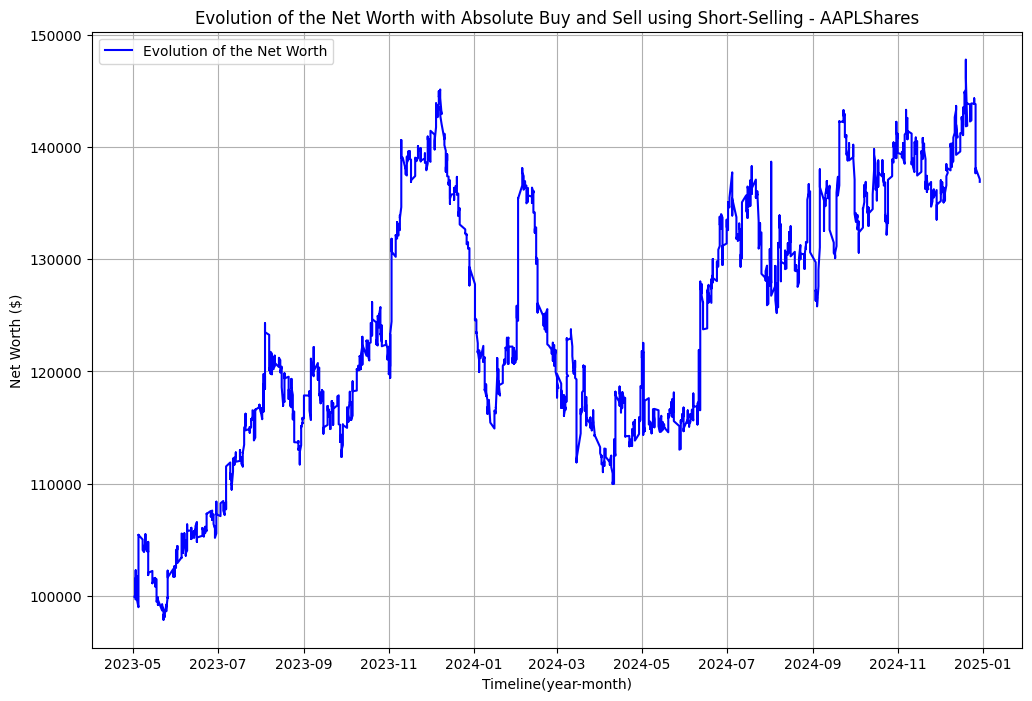

In [133]:
# Gerar o gráfico da evolução da networth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, networth_strategy_array, label='Evolution of the Net Worth', color='blue')
plt.title('Evolution of the Net Worth with Absolute Buy and Sell using Short-Selling - ' + symbol + 'Shares')
plt.xlabel('Timeline(year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

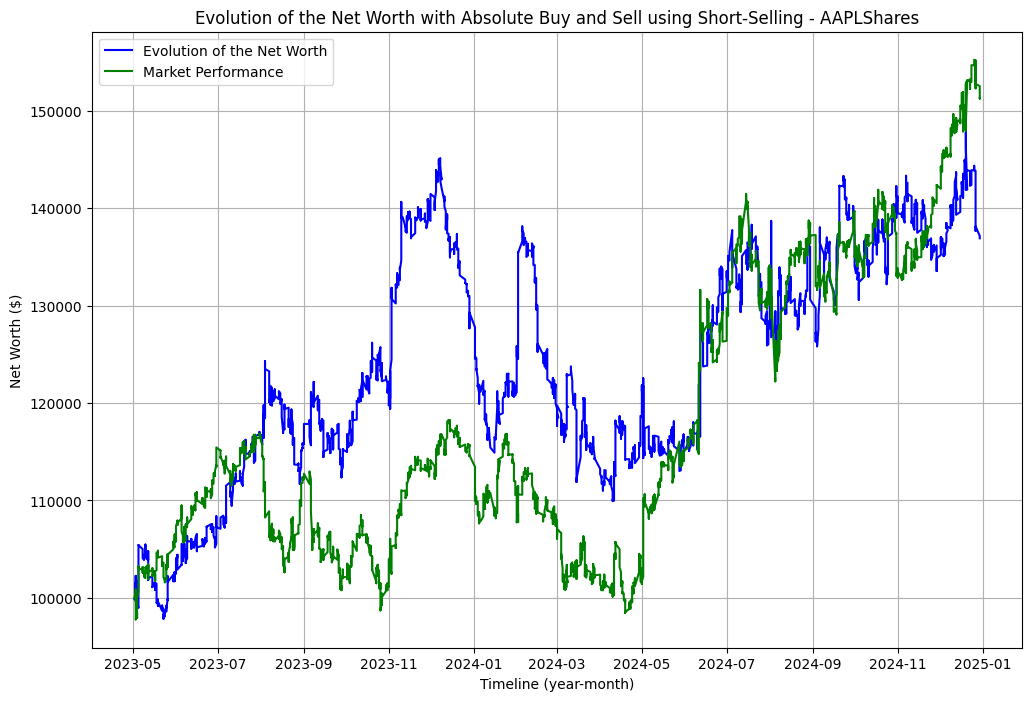

In [134]:
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, networth_strategy_array, label='Evolution of the Net Worth', color='blue')
plt.plot(last_subsets_dates_test, natural_fund_values_test, label='Market Performance', color='green')

plt.title('Evolution of the Net Worth with Absolute Buy and Sell using Short-Selling - ' + symbol + 'Shares')
plt.xlabel('Timeline (year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [135]:
print(f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase_test - final_value_test:.3f}$")

AI_percentage_increase = percentage_increase_strategy - percentage_increase_test
print(f"\nMelhoria percentual ao se ter usado AI: {AI_percentage_increase:.3f}%")

Dinheiro extra ganho ao se ter usado AI: -14322.544$

Melhoria percentual ao se ter usado AI: -14.271%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. O valor da sensibilidade decisiva deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Coordenadas do valor máximo absoluto:
Data: 2023-11-10
Diferença Percentual Máxima: 28.97%
Average Percentage Difference between Net Worth and Market Price: 6.11%


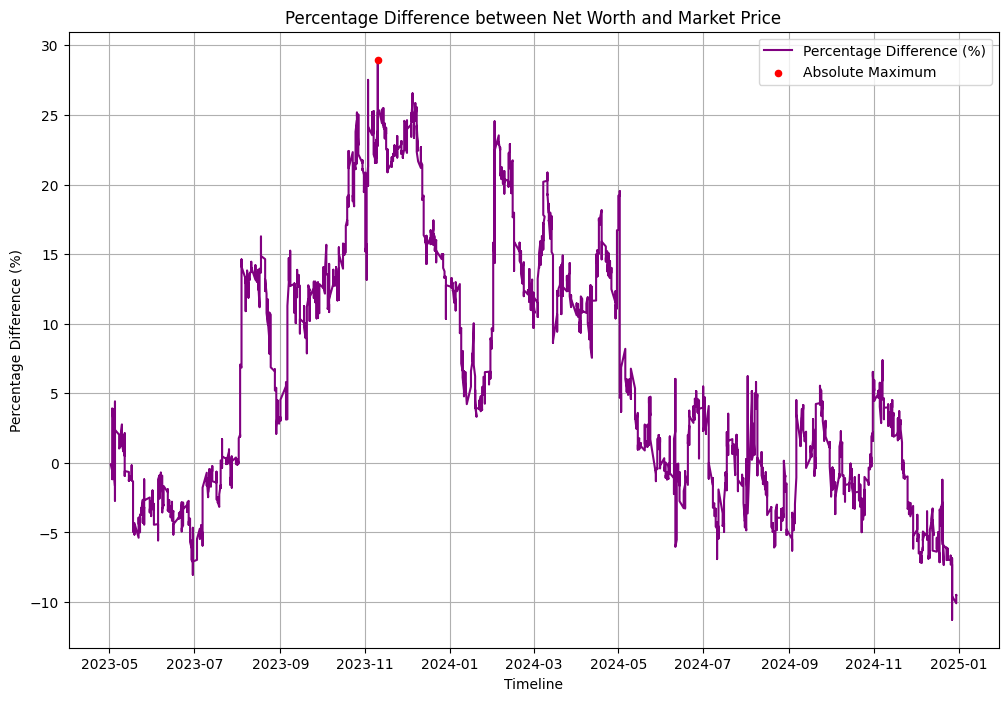

In [136]:
# Calcular a diferença percentual
diff_percentual = ((np.array(networth_strategy_array) - np.array(natural_fund_values_test)) / np.array(natural_fund_values_test)) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates_test[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, diff_percentual, label='Percentage Difference (%)', color='purple')

# Adicionar o ponto máximo ao gráfico
plt.scatter(max_date, max_diff_percentual, color='red', s=20, zorder=5, label='Absolute Maximum')

# Rótulos e título
plt.title('Percentage Difference between Net Worth and Market Price')
plt.xlabel('Timeline')
plt.ylabel('Percentage Difference (%)')

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(f"Average Percentage Difference between Net Worth and Market Price: {media_diff_percentual:.2f}%")

Results_Mean_cS_array_test[0] = [sensibilidade_decisiva1, sensibilidade_decisiva2, AI_percentage_increase, media_diff_percentual]

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

In [137]:
# 1) Build your NAV Series from lists
values = pd.Series(
    data=networth_strategy_array,
    index=pd.to_datetime(last_subsets_dates_test),
    name="NAV"
).sort_index()

# 2) Compute period-to-period returns
returns = values.pct_change().dropna()

# 3) Estimate effective periods per year
P = estimate_periods_per_year(returns)

# 4) Build the metric functions for your frequency
metrics = make_metrics(P)

# —————————————————
# NEW: load & prepare your benchmark
bench_nav = pd.Series(
    data=natural_fund_values_test,
    index=pd.to_datetime(last_subsets_dates_test),
    name="Natural NAV"
).sort_index()

benchmark_returns = bench_nav.pct_change().dropna()

# 5) Define a (scalar) annual risk-free rate - Glabally define Above on the section of settings
#rf = 0.01  # e.g. 1% p.a.

# 6) Automatically run **all** metrics you can compute:
results = {}
for name, func in metrics.items():
    sig    = inspect.signature(func)
    params = list(sig.parameters)

    try:
        # If it expects (returns, benchmark_returns, rf)
        if params == ["returns", "benchmark_returns", "rf"]:
            results[name] = func(returns, benchmark_returns, rf)

        # If it expects only (returns, benchmark_returns)
        elif params == ["returns", "benchmark_returns"]:
            results[name] = func(returns, benchmark_returns)

        # If it expects (returns, rf)
        elif params == ["returns", "rf"]:
            results[name] = func(returns, rf)

        # Otherwise just (returns,)
        else:
            results[name] = func(returns)

    except Exception:
        results[name] = float("nan")

# 7) Display only the successfully computed metrics
print(pd.Series(results).dropna())

total_return                0.370537
annualized_return           0.170700
annualized_volatility       0.370405
sharpe_ratio                0.495771
sortino_ratio               0.540040
max_drawdown               -0.242520
drawdown_duration        1598.000000
ulcer_index                10.852361
value_at_risk               0.013730
expected_shortfall          0.023246
calmar_ratio                0.703858
information_ratio          -0.058076
beta                        0.185229
alpha                       0.155909
r_squared                   0.022180
treynor_ratio               0.689414
skewness                    1.039147
kurtosis                   13.407182
omega_ratio                 1.056222
dtype: float64


/tmp/ipython-input-1640029880.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return _capm_regression(returns, benchmark_returns, rf).params[1]
/tmp/ipython-input-1640029880.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = _capm_regression(returns, benchmark_returns, rf).params[0]
/tmp/ipython-input-1640029880.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return _capm_regression(returns, benchmark_returns, rf).pa

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

Coordenadas do ponto máximo absoluto: Dinheiro Inicial = $10000100.00, Percentual de Crescimento = 39.089%


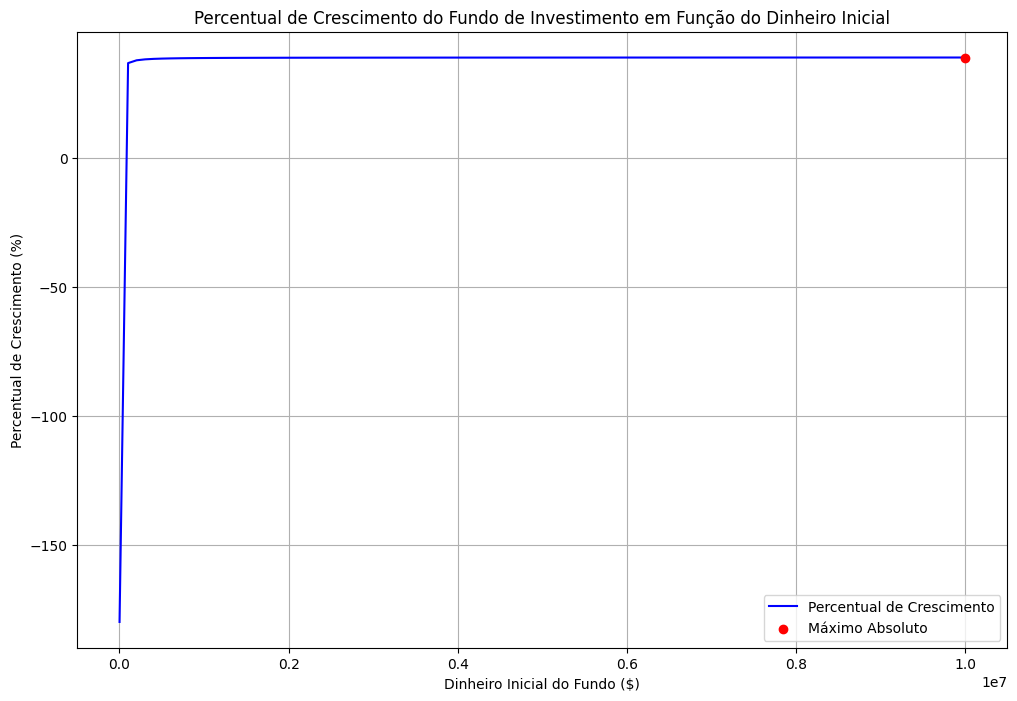

In [138]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(Min_Floor_Fund, Max_Selling_Fund + Step_money, Step_money)  # Valores de $50 a $10,000,000

# Lista para armazenar os resultados (percentual de crescimento para cada fundo inicial)
percentual_ganhos = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0           # Posição long (ações compradas)
    num_shares_short = 0.0     # Posição short (ações vendidas a descoberto)
    short_sale_price = 0.0     # Preço de abertura da operação short
    if Paid_Sun_Tzu:
        proxima_cobranca = last_subsets_dates_test[0]

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_test_np) - 1):
        current_price = float(tensor_test_np[i + 1][0])  # Preço da ação para a operação
        prediction_str = tensor_test_np[i][1]              # Previsão atual (grau de certeza)

        if Paid_Sun_Tzu:
            if proxima_cobranca <= last_subsets_dates_test[i]:
                proxima_cobranca = last_subsets_dates_test[i] + relativedelta(months=1)
                fund -= valor_cobranca_test

        # Converter a previsão para float ou definir 0 se for 'none'
        if prediction_str != 'none':
            prediction = float(prediction_str)
        else:
            prediction = 0

        # Operação LONG: se a previsão for fortemente positiva (acima de sensibilidade_decisiva2) e houver fundos
        if prediction > sensibilidade_decisiva2 and fund > 0:
            # Se houver posição short aberta, cobrir essa posição primeiro
            if num_shares_short > 0:
                exec_px = exec_price_with_slippage("cover", current_price, symbol)
                SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_test[i])
                profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
                fund -= num_shares_short * exec_px + SEC_fee
                num_shares_short = 0.0
                short_sale_price = 0.0
            # Comprar ações com o fundo disponível
            exec_px = exec_price_with_slippage("buy", current_price, symbol)
            num_shares_to_buy = fund / exec_px
            cost = num_shares_to_buy * exec_px
            fund -= cost
            num_shares += num_shares_to_buy

        # Operação SHORT: se a previsão for fortemente negativa (abaixo de sensibilidade_decisiva1)
        elif prediction < sensibilidade_decisiva1:
            # Se houver posição long, vender todas para liberar caixa
            if num_shares > 0:
                exec_px = exec_price_with_slippage("sell", current_price, symbol)
                proceeds = num_shares * exec_px
                SEC_fee = calculate_fee("sell", proceeds)
                fund += proceeds - SEC_fee
                num_shares = 0.0
            # Iniciar operação short se não houver short aberto (o valor recebido não é creditado; fica bloqueado)
            if num_shares_short == 0 and fund > 0:
                exec_px = exec_price_with_slippage("short", current_price, symbol)
                num_shares_to_short = fund / exec_px
                SEC_fee = calculate_fee("short", num_shares_to_short * exec_px)
                time_at_short = last_subsets_dates_test[i]
                fund += num_shares_to_short * exec_px - SEC_fee
                num_shares_short = num_shares_to_short
                short_sale_price = current_price
        else:
            # Zona neutra: nenhuma operação
            pass

    # Ao final do tensor, fechar quaisquer posições abertas:
    final_price = float(tensor_test_np[-1][0])
    # Fechar posição long, se houver
    if num_shares > 0:
        exec_px = exec_price_with_slippage("sell", final_price, symbol)
        proceeds = num_shares * exec_px
        SEC_fee = calculate_fee("sell", proceeds)
        fund += proceeds - SEC_fee
        num_shares = 0.0
    # Fechar posição short, se houver (lucro ou prejuízo do short)
    if num_shares_short > 0:
        exec_px = exec_price_with_slippage("cover", final_price, symbol)
        SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_test[-1])
        profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
        fund -= num_shares_short * exec_px + SEC_fee
        num_shares_short = 0.0
        short_sale_price = 0.0

    # Calcular o percentual de crescimento da estratégia
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
    percentual_ganhos.append(percentage_increase_strategy)

# Encontrar o índice do valor máximo em percentual_ganhos
max_index = np.argmax(percentual_ganhos)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = percentual_ganhos[max_index]

print(f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%")

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(initial_fund_values, percentual_ganhos, label='Percentual de Crescimento', color='blue')
plt.scatter(max_initial_fund, max_percentage_increase, color='red', zorder=5, label="Máximo Absoluto")
plt.ylim(min(percentual_ganhos) - 10, max(percentual_ganhos) + 10)
plt.title('Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial')
plt.xlabel('Dinheiro Inicial do Fundo ($)')
plt.ylabel('Percentual de Crescimento (%)')
plt.grid(True)
plt.legend()
plt.show()

## **Independent Parcial Buy and Sell in Function of Predictions Probabilaty**

Agora eu quero testar uma nova estratégia. As compras e as vendas vão ser de forma percentual. Ou seja, sempre que existe um sinal positivo para compra - "1", deve ser gasto "coeficiente * grau_certeza"% (o grau_certeza é dado por "predictions", relembrando que sempre que "predictions" é superior a "sensibilidade_decisiva" é um "1" e sempre que "predictions" é inferior a "sensibilidade_decisiva" é um "0", o grau_certeza é pela certeza que o modelo tem se se trata de um "0" ou de um "1", isto pode ser inferido através de "predictions") do dinheiro do fundo de investimento na compra de ações, se existir algum dinheiro ainda no fundo para o fazer de acordo com o percentual calculado. Sempre que existe um sinal positivo de venda - "0", devem ser vendidas "coeficiente * grau_certeza"% das ações do fundo de investimento, se o fundo tiver ainda ações suficientes para o fazer de acordo com a percentagem calculada. A questão que aqui diferencia da passada estratégia é que agora vão existir 2 coeficientes em jogo um coeficente para ações de venda, coeficiente_v, outro para ações de compra, coeficiente_c.

Esta estratégia é extremamente semelhante á anterior apenas é acrecenta um novo coeficiente e para tal terá de ser distinguido o coeficiente de buy do coeficiente de sell.

if prediction > sensibilidade_decisiva and fund > 0:
    grau_certeza = abs(prediction)  # Grau de certeza do modelo
    # Comprar ações com base no percentual calculado
    amount_to_invest = coeficiente_c * grau_certeza * fund
    num_shares_to_buy = amount_to_invest / current_price  # Quantidade de ações que podemos comprar (fracionária)
    fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
    num_shares += num_shares_to_buy  # Atualiza o número de ações

elif prediction <= sensibilidade_decisiva and num_shares > 0:
    grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
    # Vender ações com base no percentual calculado
    amount_to_sell = coeficiente_v * grau_certeza * num_shares  # Quantidade de ações a vender
    num_shares_to_sell = amount_to_sell  # Quantidade fracionária de ações a vender
    fund += num_shares_to_sell * current_price  # Vende as ações e atualiza o fundo
    num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda

Por este código passam 3 loops diferentes todos uns dentro uns dos outros assim consigo garantir que para cada coeficiente de compra é testado para todos os valores de coeficiente de venda e para todos os valores de sensibilidade decisiva.

### **Otimization**

**Estudo do Melhor Coeficiente e Melhor Sensibilidade Decisiva para Formatar o Percentual Investido:**


Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva e do coeficientes. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva e com o coeficientes utilizados sinalarizará a melhor combinação sensibilidade decisiva, coeficiente para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva e coefieciente em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor combinação sensibilidade decisiva, coeficientes.

In [139]:
# Fundo inicial e baseline para comparação
initial_fund = Initial_Funds_Last_Strategy  # Fundo inicial de $100,000
# percentage_increase é o benchmark, já definido no contexto

# Listas para armazenar as coordenadas e os resultados
x_vals = []   # Sensibilidade Decisiva 1 (Venda/Short)
y_vals = []   # Sensibilidade Decisiva 2 (Compra/Long)
z_vals = []   # Coeficiente C (Compra)
w_vals = []   # Coeficiente V (Venda)  -- pode ser usado para representar dimensão adicional
u_vals = []   # Coeficiente S (Short-selling)
color_vals_med = []  # Média da Diferença Percentual
color_vals = []      # Ganho Percentual Ajustado (ganho da estratégia menos o benchmark)

total_iterations = len(sensibilidade_decisiva1_array_otimization_Last_Strategy) * len(sensibilidade_decisiva2_array_otimization_Last_Strategy) * len(coeficiente_c_array_otimization_Last_Strategy) * len(coeficiente_v_array_otimization_Last_Strategy) * len(coeficiente_s_array_otimization_Last_Strategy)
iteration = 0

# Loop sobre todas as combinações dos parâmetros, iterando primeiro sobre os thresholds:
for sensibilidade_decisiva1 in sensibilidade_decisiva1_array_otimization_Last_Strategy:
    for sensibilidade_decisiva2 in sensibilidade_decisiva2_array_otimization_Last_Strategy:
        for coeficiente_c in coeficiente_c_array_otimization_Last_Strategy:
            for coeficiente_v in coeficiente_v_array_otimization_Last_Strategy:
                for coeficiente_s in coeficiente_s_array_otimization_Last_Strategy:
                    iteration += 1
                    print(f"\rProgress: {(iteration/total_iterations*100):.2f}%", end='')
                    sys.stdout.flush()

                    # Inicialização das variáveis para esta simulação
                    fund = initial_fund
                    num_shares = 0.0          # Posição long (ações compradas)
                    num_shares_short = 0.0      # Posição short (ações vendidas a descoberto)
                    short_sale_price = 0.0      # Preço de abertura do short
                    networth_strategy_array = []
                    if Paid_Sun_Tzu:
                        proxima_cobranca = last_subsets_dates_otimization[0]

                    # Iterar pelo tensor (exceto o último que não tem previsão)
                    for i in range(len(tensor_otimization_np) - 1):
                        current_price = float(tensor_otimization_np[i + 1][0])  # Preço da ação para a operação
                        prediction_raw = tensor_otimization_np[i][1]            # Previsão atual

                        if Paid_Sun_Tzu:
                            if proxima_cobranca <= last_subsets_dates_otimization[i]:
                                proxima_cobranca = last_subsets_dates_otimization[i] + relativedelta(months=1)
                                fund -= valor_cobranca_otimization

                        if prediction_raw != 'none':
                            prediction = float(prediction_raw)
                        else:
                            prediction = 0.0

                        # Determinar sinal (para debug):
                        # 1 se previsão > sensibilidade_decisiva2 (compra),
                        # -1 se previsão < sensibilidade_decisiva1 (venda/short),
                        # 0 se estiver na zona neutra.
                        if prediction > sensibilidade_decisiva2:
                            signal = 1
                        elif prediction < sensibilidade_decisiva1:
                            signal = -1
                        else:
                            signal = 0

                        # OPERAÇÃO LONG (compra) se previsão for alta: > sensibilidade_decisiva2
                        if prediction > sensibilidade_decisiva2 and fund > 0:
                            # Se houver posição short aberta, cobrir primeiro
                            if num_shares_short > 0:
                                exec_px = exec_price_with_slippage("cover", current_price, symbol)
                                SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_otimization[i])
                                profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
                                fund -= num_shares_short * exec_px + SEC_fee
                                num_shares_short = 0.0
                                short_sale_price = 0.0

                            # Comprar ações com base no coeficiente_c e no grau de certeza
                            percentage_to_spend = coeficiente_c * max(0.0, min(1.0, (prediction - sensibilidade_decisiva2) / max(eps, 1 - sensibilidade_decisiva2)))
                            if percentage_to_spend > 1:
                                percentage_to_spend = 1
                            exec_px = exec_price_with_slippage("buy", current_price, symbol)
                            amount_to_invest = percentage_to_spend * fund
                            num_shares_to_buy = amount_to_invest / exec_px
                            cost = num_shares_to_buy * exec_px
                            fund -= cost
                            num_shares += num_shares_to_buy

                        # OPERAÇÃO VENDA/SHORT se previsão for baixa: < sensibilidade_decisiva1
                        elif prediction < sensibilidade_decisiva1:
                            # Se houver posição long, vender parte dela conforme coeficiente_v
                            if num_shares > 0:
                                percentage_to_sell = coeficiente_v * max(0.0, min(1.0, (sensibilidade_decisiva1 - prediction) / max(eps, sensibilidade_decisiva1)))
                                if percentage_to_sell > 1:
                                    percentage_to_sell = 1
                                exec_px = exec_price_with_slippage("sell", current_price, symbol)
                                amount_to_sell = percentage_to_sell * num_shares * current_price
                                amount_to_sell = min(amount_to_sell, num_shares * exec_px)
                                shares_to_sell = amount_to_sell / exec_px
                                proceeds = shares_to_sell * exec_px
                                SEC_fee = calculate_fee("sell", proceeds)
                                fund += proceeds - SEC_fee
                                num_shares -= shares_to_sell

                            # Se não houver posição long e nem short aberta, iniciar operação short
                            if num_shares == 0 and num_shares_short == 0 and fund > 0:
                                percentage_to_short = coeficiente_s * max(0.0, min(1.0, (sensibilidade_decisiva1 - prediction) / max(eps, sensibilidade_decisiva1)))
                                if percentage_to_short > 1:
                                    percentage_to_short = 1
                                # Utiliza o fundo disponível como capacidade máxima para short-selling
                                amount_to_short = percentage_to_short * fund
                                exec_px = exec_price_with_slippage("short", current_price, symbol)
                                num_shares_to_short = amount_to_short / exec_px
                                SEC_fee = calculate_fee("short", num_shares_to_short * exec_px)
                                fund += num_shares_to_short * exec_px - SEC_fee
                                time_at_short = last_subsets_dates_otimization[i]
                                num_shares_short = num_shares_to_short
                                short_sale_price = exec_px

                        else:
                            pass

                        # Cálculo da networth do portfólio (contando somente o fundo e posições long)
                        current_networth = fund + num_shares * current_price - num_shares_short * current_price
                        networth_strategy_array.append(current_networth)

                    # Ao final do tensor, fechar quaisquer posições abertas:
                    final_price = float(tensor_otimization_np[-1][0])

                    # Fechar posição long, se houver
                    if num_shares > 0:
                        exec_px = exec_price_with_slippage("sell", final_price, symbol)
                        proceeds = num_shares * exec_px
                        SEC_fee = calculate_fee("sell", proceeds)
                        fund += proceeds - SEC_fee
                        num_shares = 0.0

                    # Fechar posição short, se houver (realizando lucro ou prejuízo do short)
                    if num_shares_short > 0:
                        exec_px = exec_price_with_slippage("cover", final_price, symbol)
                        SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_otimization[-1])
                        profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
                        fund -= num_shares_short * exec_px + SEC_fee
                        num_shares_short = 0.0
                        short_sale_price = 0.0

                    networth_strategy_array.append(fund)
                    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100

                    # Calcular a diferença percentual entre a estratégia simulada e o fundo natural
                    diff_percentual = ((np.array(networth_strategy_array) - np.array(natural_fund_values_otimization)) /
                                       np.array(natural_fund_values_otimization)) * 100
                    media_diff_percentual = np.mean(diff_percentual)

                    # Calcular o ganho percentual da estratégia e ajustar em relação à baseline
                    percentual_ganho = ((fund - initial_fund) / initial_fund) * 100
                    gain_adjusted = percentual_ganho - percentage_increase_otimization

                    # Armazenar os parâmetros e resultados para análise/plotagem
                    x_vals.append(sensibilidade_decisiva1)  # Sensibilidade Decisiva 1 (venda/short)
                    y_vals.append(sensibilidade_decisiva2)  # Sensibilidade Decisiva 2 (compra/long)
                    z_vals.append(coeficiente_c)       # Coeficiente C (compra)
                    w_vals.append(coeficiente_v)  # Coeficiente V (venda)
                    u_vals.append(coeficiente_s)  # Coeficiente S (short-selling)
                    color_vals_med.append(media_diff_percentual)
                    color_vals.append(gain_adjusted)

Progress: 100.00%


=== Top 3 Empirical Data Points (Adjusted Gain) ===
Top 1 empirical point: SD1 (Sell) = 1.000000, SD2 (Buy) = 0.000000, Buy Coef = 2.000000, Sell Coef = 2.500000, Short Coef = 1.000000, Adjusted Gain = 47.458193%
Top 2 empirical point: SD1 (Sell) = 1.000000, SD2 (Buy) = 0.000000, Buy Coef = 2.000000, Sell Coef = 1.500000, Short Coef = 4.000000, Adjusted Gain = 30.148506%
Top 3 empirical point: SD1 (Sell) = 1.000000, SD2 (Buy) = 0.000000, Buy Coef = 2.000000, Sell Coef = 1.500000, Short Coef = 3.000000, Adjusted Gain = 30.148506%


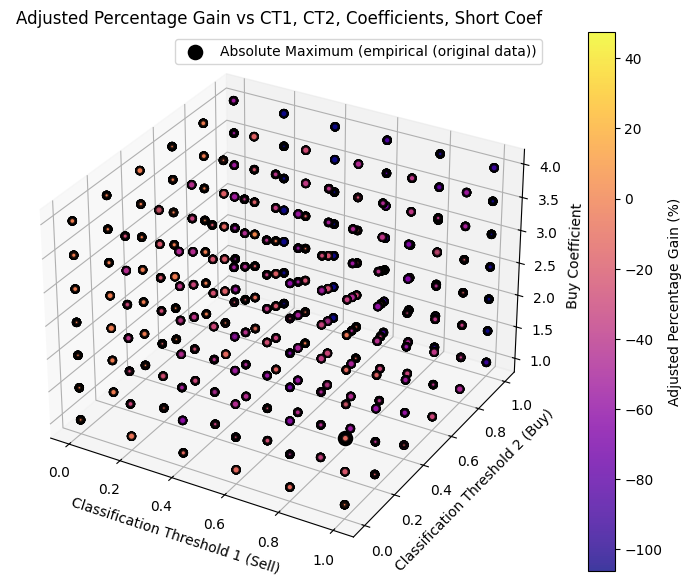

In [140]:
# --- 1) Original data as numpy arrays ---
sd1_vals    = np.array(x_vals)          # Decision Sensitivity 1 (Sell)
sd2_vals    = np.array(y_vals)          # Decision Sensitivity 2 (Buy)
coef_c_vals = np.array(z_vals)          # Buy Coefficient
coef_v_vals = np.array(w_vals)          # Sell Coefficient
coef_s_vals = np.array(u_vals)          # Short-selling Coefficient
color_vals  = np.array(color_vals)      # Adjusted Percentage Gain

# Pack into X (n×5) and y (n,)
X = np.vstack([sd1_vals, sd2_vals, coef_c_vals, coef_v_vals, coef_s_vals]).T
y = color_vals

# --- 5) Check empirical maximum ---
idx_emp = np.argmax(y)
emp_pt = X[idx_emp]
emp_val = y[idx_emp]

best_source = 'empirical (original data)'
best_pt = emp_pt
best_val = emp_val

Results_Last_cS_array[1] = [best_pt[0], best_pt[1], best_pt[2], best_pt[3], best_pt[4], best_val]

# --- 7) Print top-3 empirical data points ---
top3 = np.argsort(y)[-3:][::-1]
print("\n=== Top 3 Empirical Data Points (Adjusted Gain) ===")
for rank, idx in enumerate(top3, start=1):
    pt = X[idx]
    val = y[idx]
    print(
        f"Top {rank} empirical point: "
        f"SD1 (Sell) = {pt[0]:.6f}, "
        f"SD2 (Buy) = {pt[1]:.6f}, "
        f"Buy Coef = {pt[2]:.6f}, "
        f"Sell Coef = {pt[3]:.6f}, "
        f"Short Coef = {pt[4]:.6f}, "
        f"Adjusted Gain = {val:.6f}%"
    )

# --- 8) Final plot in English ---
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Map sizes and edge widths
sizes = coef_v_vals * 7
mean_edge_width = np.mean(coef_s_vals - 1)

# Scatter original data
sc = ax.scatter(
    sd1_vals, sd2_vals, coef_c_vals,
    c=color_vals, cmap='plasma',
    s=sizes, alpha=0.8,
    linewidths=mean_edge_width,
    edgecolor='black'
)
# Highlight absolute maximum
ax.scatter(
    best_pt[0], best_pt[1], best_pt[2],
    color='black', s=150,
    edgecolors='white', label=f"Absolute Maximum ({best_source})"
)
# Colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Adjusted Percentage Gain (%)')

# Labels in English
ax.set_title('Adjusted Percentage Gain vs CT1, CT2, Coefficients, Short Coef')
ax.set_xlabel('Classification Threshold 1 (Sell)')
ax.set_ylabel('Classification Threshold 2 (Buy)')
ax.set_zlabel('Buy Coefficient')

# Legend
ax.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a combinação sensibilidade decisiva, coeficientes que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor combinação sensibilidade decisiva, coeficientes para este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.


=== Top 3 Empirical Data Points (Mean Percentage Gain) ===
Top 1 empirical point: SD1 (Sell/Short) = 1.000000, SD2 (Buy/Long) = 0.000000, Buy Coef = 2.000000, Sell Coef = 2.500000, Short Coef = 1.000000, Mean Gain = 21.250220%
Top 2 empirical point: SD1 (Sell/Short) = 1.000000, SD2 (Buy/Long) = 0.000000, Buy Coef = 3.000000, Sell Coef = 3.000000, Short Coef = 1.500000, Mean Gain = 10.354110%
Top 3 empirical point: SD1 (Sell/Short) = 1.000000, SD2 (Buy/Long) = 0.000000, Buy Coef = 2.000000, Sell Coef = 2.500000, Short Coef = 3.500000, Mean Gain = 9.993544%


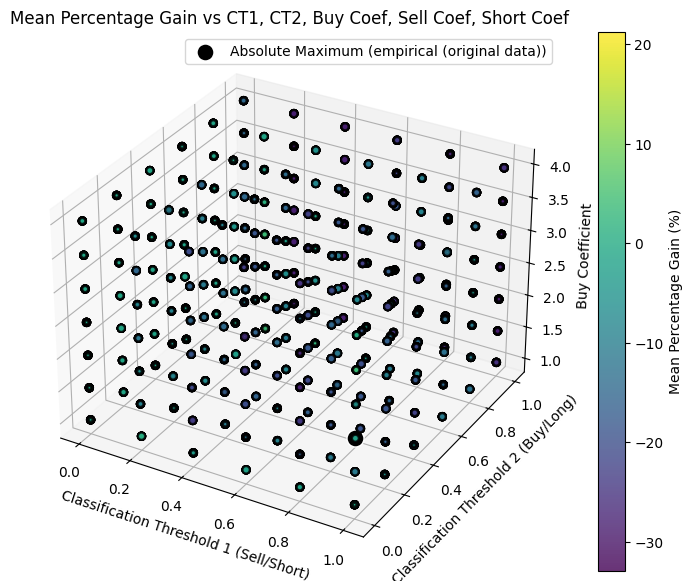

In [141]:
# --- 1) Original data as numpy arrays ---
x = np.array(x_vals)            # Decision Sensitivity 1 (Sell/Short)
y = np.array(y_vals)            # Decision Sensitivity 2 (Buy/Long)
z = np.array(z_vals)            # Buy Coefficient
w = np.array(w_vals)            # Sell Coefficient
v = np.array(u_vals)            # Short-selling Coefficient
m = np.array(color_vals_med)    # Mean Percentage Gain

# Pack into X (n×5) and target y (n,)
X = np.vstack([x, y, z, w, v]).T
y_target = m

# --- 5) Check empirical maximum ---
idx_emp = np.argmax(y_target)
emp_pt = X[idx_emp]
emp_val = y_target[idx_emp]

best_source = 'empirical (original data)'
best_pt = emp_pt
best_val = emp_val

Results_Mean_cS_array[1] = [best_pt[0], best_pt[1], best_pt[2], best_pt[3], best_pt[4], best_val]

# --- 7) Print top-3 empirical data points ---
top3 = np.argsort(y_target)[-3:][::-1]
print("\n=== Top 3 Empirical Data Points (Mean Percentage Gain) ===")
for rank, idx in enumerate(top3, start=1):
    pt_vals = X[idx]
    val = y_target[idx]
    print(
        f"Top {rank} empirical point: "
        f"SD1 (Sell/Short) = {pt_vals[0]:.6f}, "
        f"SD2 (Buy/Long) = {pt_vals[1]:.6f}, "
        f"Buy Coef = {pt_vals[2]:.6f}, "
        f"Sell Coef = {pt_vals[3]:.6f}, "
        f"Short Coef = {pt_vals[4]:.6f}, "
        f"Mean Gain = {val:.6f}%"
    )

# --- 8) Final plot in English ---
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Sizes by Sell Coef, edge width by Short Coef
data_sizes = w * 7
mean_edge = np.mean(v - 1)
sc = ax.scatter(
    x, y, z,
    c=m, cmap='viridis',
    s=data_sizes, alpha=0.8,
    linewidths=mean_edge,
    edgecolor='black'
)
# Highlight absolute maximum
ax.scatter(
    best_pt[0], best_pt[1], best_pt[2],
    color='black', s=150,
    edgecolors='white', label=f"Absolute Maximum ({best_source})"
)
# Colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Mean Percentage Gain (%)')

# Labels in English
ax.set_title('Mean Percentage Gain vs CT1, CT2, Buy Coef, Sell Coef, Short Coef')
ax.set_xlabel('Classification Threshold 1 (Sell/Short)')
ax.set_ylabel('Classification Threshold 2 (Buy/Long)')
ax.set_zlabel('Buy Coefficient')
ax.legend()
plt.show()

### **Test**

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para uma combinação especifica de sensibilidade decisiva e coeficientes.

Geralmente a ideia é analisar detalhadamente o que é que acontece com a combinação considerado ideal encotrado anteriormente.

In [142]:
sensibilidade_decisiva1 = Results_Mean_cS_array[1][0]
print(f"Sensibilidade Decisiva 1: {sensibilidade_decisiva1}")
sensibilidade_decisiva2 = Results_Mean_cS_array[1][1]
print(f"Sensibilidade Decisiva 2: {sensibilidade_decisiva2}")
coeficiente_c = Results_Mean_cS_array[1][2]
print(f"Coeficiente de Compra: {coeficiente_c}")
coeficiente_v = Results_Mean_cS_array[1][3]
print(f"Coeficiente de Venda: {coeficiente_v}")
coeficiente_s_array = Results_Mean_cS_array[1][4]
print(f"Coeficiente de Short-Selling: {coeficiente_s_array}")

Sensibilidade Decisiva 1: 1.0
Sensibilidade Decisiva 2: 0.0
Coeficiente de Compra: 2.0
Coeficiente de Venda: 2.5
Coeficiente de Short-Selling: 1.0


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [143]:
# Inicializar variáveis
initial_fund = Initial_Funds  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0              # Posição long (ações compradas)
num_shares_short = 0.0        # Posição short (ações vendidas a descoberto)
short_sale_price = 0.0        # Preço de abertura da operação short
total_ops = 0.0               # Valor total das operações realizadas
networth_strategy_array = []
Total_Slippage = 0
Total_Fees = 0
Total_Borrowings = 0
if Paid_Sun_Tzu:
    proxima_cobranca = last_subsets_dates_test[0]
    total_cobrancas = 0

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_test_np) - 1):
    current_price = float(tensor_test_np[i + 1][0])  # Preço da ação para a operação
    prediction_raw = tensor_test_np[i][1]              # Previsão atual

    if Paid_Sun_Tzu:
        if proxima_cobranca <= last_subsets_dates_test[i]:
            proxima_cobranca = last_subsets_dates_test[i] + relativedelta(months=1)
            fund -= valor_cobranca_test
            total_cobrancas += 1
            print(f"Custo do Alpaca cobrado: ${valor_cobranca_test:.2f}")
            print(f"Fundo restante: ${fund:.2f}")

    if prediction_raw != 'none':
        prediction = float(prediction_raw)
    else:
        prediction = 0.0

    # Determinar sinal (para debug):
    # 1 se previsão > sensibilidade_decisiva2 (compra),
    # -1 se previsão < sensibilidade_decisiva1 (venda/short),
    # 0 se estiver na zona neutra.
    if prediction > sensibilidade_decisiva2:
        signal = 1
    elif prediction < sensibilidade_decisiva1:
        signal = -1
    else:
        signal = 0

    # OPERAÇÃO LONG (compra) se previsão for alta: > sensibilidade_decisiva2
    if prediction > sensibilidade_decisiva2 and fund > 0:
        # Se houver posição short aberta, cobrir primeiro
        if num_shares_short > 0:
            exec_px = exec_price_with_slippage("cover", current_price, symbol)
            SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_test[i])
            Total_Borrowings += SEC_fee
            Slippage_Cost = num_shares_short * (exec_px - current_price)
            Total_Slippage += Slippage_Cost
            profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
            fund -= num_shares_short * exec_px + SEC_fee
            total_ops += num_shares_short * exec_px  # valor da operação de cobertura
            print(f"[Período {i}] COBERTURA SHORT: Fechado {num_shares_short:.6f} ações short a {exec_px:.2f} por ${num_shares_short * current_price:.2f}, borrowing rate = ${SEC_fee:.2f}, custo do slippage = ${Slippage_Cost:.2f}. Lucro/Prejuízo: ${profit:.2f}. Novo fundo: ${fund:.2f}.")
            num_shares_short = 0.0
            short_sale_price = 0.0

        # Comprar ações com base no coeficiente_c e no grau de certeza
        percentage_to_spend = coeficiente_c * max(0.0, min(1.0, (prediction - sensibilidade_decisiva2) / max(eps, 1 - sensibilidade_decisiva2)))
        if percentage_to_spend > 1:
            percentage_to_spend = 1
        exec_px = exec_price_with_slippage("buy", current_price, symbol)
        amount_to_invest = percentage_to_spend * fund
        num_shares_to_buy = amount_to_invest / exec_px
        cost = num_shares_to_buy * exec_px
        Slippage_Cost = num_shares_to_buy * (exec_px - current_price)
        Total_Slippage += Slippage_Cost
        fund -= cost
        total_ops += cost
        num_shares += num_shares_to_buy
        print(f"[Período {i}] COMPRA LONG: Comprado {num_shares_to_buy:.6f} ações a {current_price:.2f} por ${cost:.2f}, custo do slippage = ${Slippage_Cost:.2f}. Liquidez: ${fund:.2f}.")

    # OPERAÇÃO VENDA/SHORT se previsão for baixa: < sensibilidade_decisiva1
    elif prediction < sensibilidade_decisiva1:
        # Se houver posição long, vender parte dela conforme coeficiente_v
        if num_shares > 0:
            percentage_to_sell = coeficiente_v * max(0.0, min(1.0, (sensibilidade_decisiva1 - prediction) / max(eps, sensibilidade_decisiva1)))
            if percentage_to_sell > 1:
                percentage_to_sell = 1
            exec_px = exec_price_with_slippage("sell", current_price, symbol)
            amount_to_sell = percentage_to_sell * num_shares * current_price
            shares_to_sell = amount_to_sell / exec_px
            shares_to_sell = min(num_shares, amount_to_sell / exec_px)
            proceeds = shares_to_sell * exec_px
            SEC_fee = calculate_fee("sell", proceeds)
            Slippage_Cost = shares_to_sell * (current_price - exec_px)
            Total_Slippage += Slippage_Cost
            Total_Fees += SEC_fee
            fund += proceeds - SEC_fee
            total_ops += proceeds
            num_shares -= shares_to_sell
            print(f"[Período {i}] VENDA LONG: Vendido {shares_to_sell:.6f} ações a {current_price:.2f} por ${proceeds:.2f}, taxa SEC ${SEC_fee:.2f}, custo do slippage = ${Slippage_Cost:.2f}. Liquidez: ${fund:.2f}.")

        # Se não houver posição long e nem short aberta, iniciar operação short
        if num_shares == 0 and num_shares_short == 0 and fund > 0:
            percentage_to_short = coeficiente_s * max(0.0, min(1.0, (sensibilidade_decisiva1 - prediction) / max(eps, sensibilidade_decisiva1)))
            if percentage_to_short > 1:
                percentage_to_short = 1
            # Utiliza o fundo disponível como capacidade máxima para short-selling
            exec_px = exec_price_with_slippage("short", current_price, symbol)
            amount_to_short = percentage_to_short * fund
            num_shares_to_short = amount_to_short / exec_px
            SEC_fee = calculate_fee("short", num_shares_to_short * exec_px)
            Total_Fees += SEC_fee
            Slippage_Cost = num_shares_to_short * (current_price - exec_px)
            Total_Slippage += Slippage_Cost
            fund += num_shares_to_short * exec_px - SEC_fee
            time_at_short = last_subsets_dates_test[i]
            num_shares_short = num_shares_to_short
            short_sale_price = exec_px
            total_ops += num_shares_to_short * exec_px
            print(f"[Período {i}] ABERTURA SHORT: Vendido a descoberto {num_shares_to_short:.6f} ações a {current_price:.2f} por ${num_shares_to_short * current_price:.2f}, taxa SEC = ${SEC_fee:.2f}, custo do slippage = ${Slippage_Cost:.2f}. (Fundo permanece: ${fund:.2f}).")

    else:
        print(f"[Período {i}] SEM OPERAÇÃO: Previsão {prediction:.5f} está na zona neutra. Liquidez: ${fund:.2f}.")

    # Cálculo da networth do portfólio (contando somente o fundo e posições long)
    current_networth = fund + num_shares * current_price - num_shares_short * current_price
    print(f"[Período {i}] Networth: ${current_networth:.2f} | Preço: {current_price:.2f} | Prediction: {prediction:.5f} | Sinal: {signal}")
    networth_strategy_array.append(current_networth)

# Ao final do tensor, fechar quaisquer posições abertas:
final_price = float(tensor_test_np[-1][0])

# Fechar posição long, se houver
if num_shares > 0:
    exec_px = exec_price_with_slippage("sell", final_price, symbol)
    proceeds = num_shares * exec_px
    SEC_fee = calculate_fee("sell", proceeds)
    Slippage_Cost = num_shares * (final_price - exec_px)
    Total_Slippage += Slippage_Cost
    Total_Fees += SEC_fee
    fund += proceeds - SEC_fee
    total_ops += proceeds
    print(f"[Final] FECHAMENTO LONG: Vendido {num_shares:.6f} ações a {final_price:.2f} por ${proceeds:.2f}, taxa SEC = ${SEC_fee:.2f}, custo do slippage = ${Slippage_Cost:.2f}.")
    num_shares = 0.0

# Fechar posição short, se houver (realizando lucro ou prejuízo do short)
if num_shares_short > 0:
    exec_px = exec_price_with_slippage("cover", final_price, symbol)
    SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_test[-1])
    Total_Borrowings += SEC_fee
    Slippage_Cost = num_shares_short * (exec_px - final_price)
    Total_Slippage += Slippage_Cost
    profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
    fund -= exec_px * num_shares_short + SEC_fee
    total_ops += num_shares_short * exec_px  # valor da operação de cobertura
    print(f"[Final] FECHAMENTO SHORT: Fechado {num_shares_short:.6f} ações short a {final_price:.2f} por ${num_shares_short * final_price:.2f}, borrowing rate = ${SEC_fee:.2f}, custo do slippage = ${Slippage_Cost:.2f}. Lucro/Prejuízo: ${profit:.2f}.")
    num_shares_short = 0.0
    short_sale_price = 0.0

print(f"Data de ínicio da simulação: {last_subsets_dates_test[0]}. Data de fim da simulação: {last_subsets_dates_test[-1]}")
print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")
networth_strategy_array.append(fund)
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(f"Custo do Slippage: ${Total_Slippage:.2f}")
print(f"Taxas SEC total pagas: ${Total_Fees:.2f}")
print(f"Rate borrowings pagos: ${Total_Borrowings:.2f}")
if Paid_Sun_Tzu:
    print(f"Data da primeira cobrança Alpaca: {last_subsets_dates_test[0]}. Total de cobranças do Alpaca: {total_cobrancas}. Valor gasto: ${total_cobrancas*valor_cobranca_test}")
print(f"Percentual de crescimento do fundo com a estratégia: {percentage_increase_strategy:.3f}%")
print(f"Valor Total das Operações Realizadas: ${total_ops:.2f}")

Custo do Alpaca cobrado: $99.00
Fundo restante: $99901.00
[Período 0] COMPRA LONG: Comprado 565.990019 ações a 166.62 por $94333.55, custo do slippage = $28.29. Liquidez: $5567.45.
[Período 0] Networth: $99872.71 | Preço: 166.62 | Prediction: 0.47214 | Sinal: 1
[Período 1] COMPRA LONG: Comprado 33.242440 ações a 167.43 por $5567.45, custo do slippage = $1.67. Liquidez: $0.00.
[Período 1] Networth: $100329.49 | Preço: 167.43 | Prediction: 0.96657 | Sinal: 1
[Período 2] VENDA LONG: Vendido 0.769219 ações a 167.51 por $128.81, taxa SEC $0.00, custo do slippage = $0.04. Liquidez: $128.81.
[Período 2] Networth: $100377.39 | Preço: 167.51 | Prediction: 0.99949 | Sinal: 1
[Período 3] COMPRA LONG: Comprado 0.766311 ações a 168.04 por $128.81, custo do slippage = $0.04. Liquidez: $0.00.
[Período 3] Networth: $100694.53 | Preço: 168.04 | Prediction: 0.54463 | Sinal: 1
[Período 4] VENDA LONG: Vendido 599.229552 ações a 167.20 por $100161.12, taxa SEC $2.78, custo do slippage = $30.06. Liquidez: $

Plot da networth do portefóflio usando esta estratégia com esta combinação sensibilidade decisiva, coeficientes para este modelo.

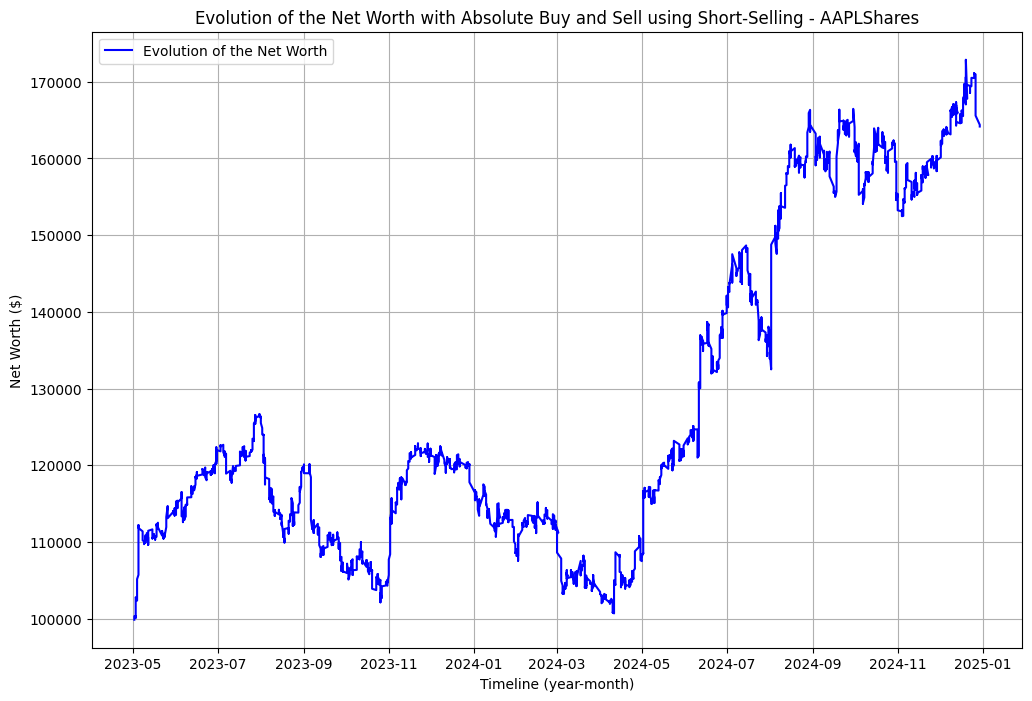

In [144]:
# Gerar o gráfico da evolução da networth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, networth_strategy_array, label='Evolution of the Net Worth', color='blue')
plt.title('Evolution of the Net Worth with Absolute Buy and Sell using Short-Selling - ' + symbol + 'Shares')
plt.xlabel('Timeline (year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva e coeficiente para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

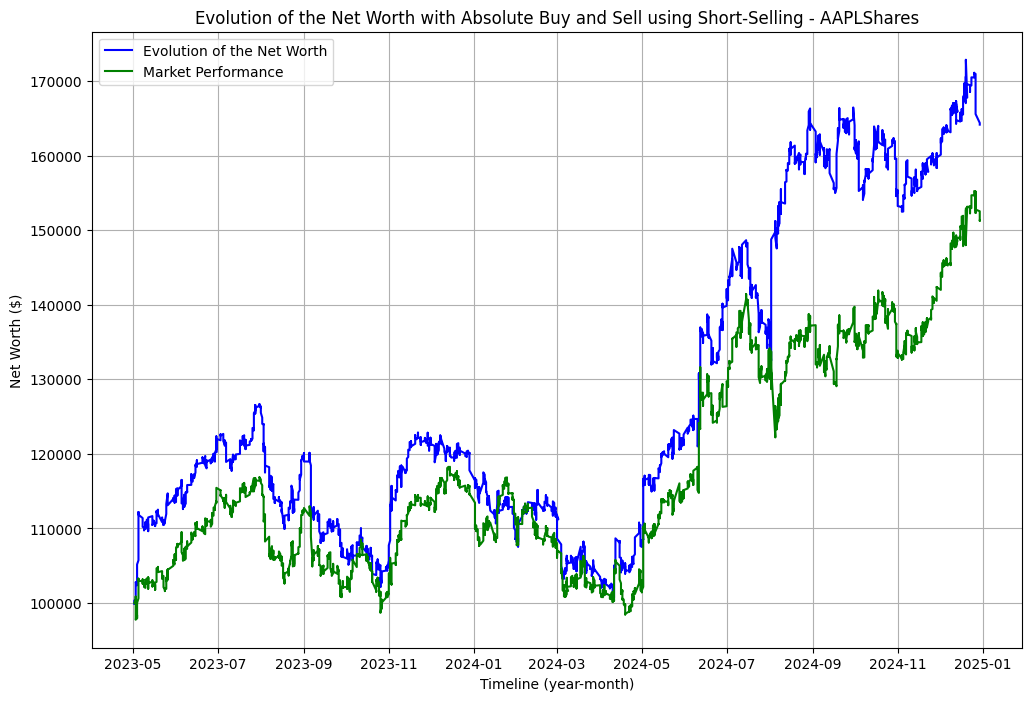

In [145]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(dates_list_test[-(len(networth_strategy_array)):], networth_strategy_array, label='Evolution of the Net Worth', color='blue')
plt.plot(last_subsets_dates_test, natural_fund_values_test, label='Market Performance', color='green')

plt.title('Evolution of the Net Worth with Absolute Buy and Sell using Short-Selling - ' + symbol + 'Shares')
plt.xlabel('Timeline (year-month)')
plt.ylabel('Net Worth ($)')
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [146]:
print(f"Dinheiro extra ganho ao se ter usado AI: {fund-percentage_increase_test-final_value_test:.3f}$")

AI_percentage_increase = percentage_increase_strategy-percentage_increase_test
print(f"\nMelhoria percentual ao se ter usado AI: {AI_percentage_increase:.3f}%")

Dinheiro extra ganho ao se ter usado AI: 12926.495$

Melhoria percentual ao se ter usado AI: 12.978%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. A combinação valor da sensibilidade decisiva, coeficiente deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Coordenadas do valor máximo absoluto:
Data: 2024-08-07
Diferença Percentual Máxima: 23.18%
Average Percentage Difference between Net Worth and Market Price: 7.79%


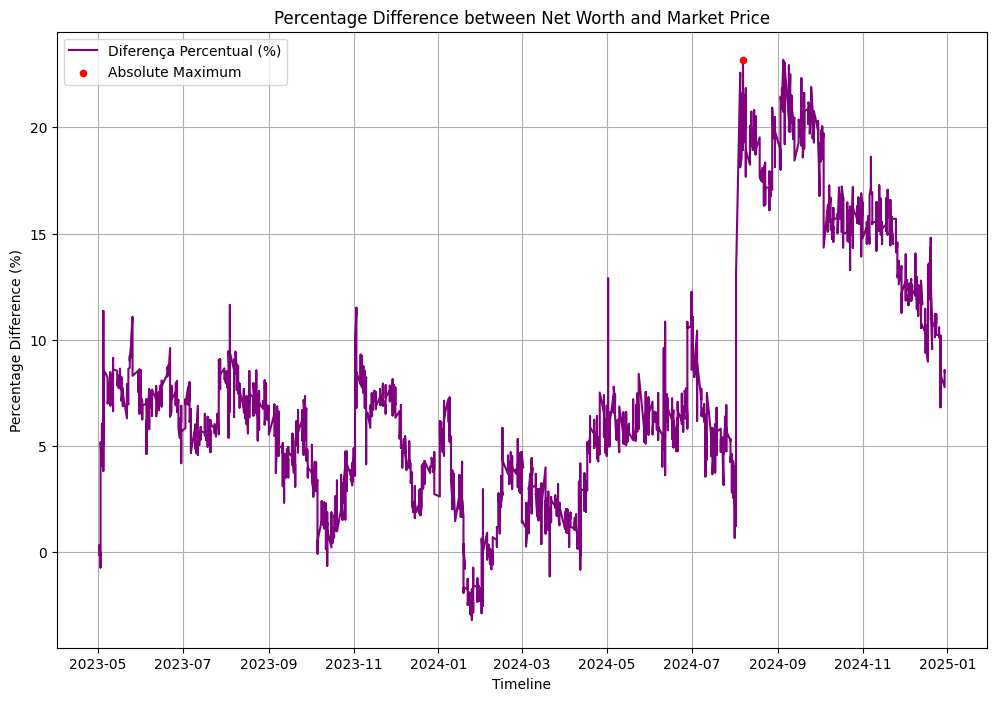

In [147]:
# Calcular a diferença percentual
diff_percentual = ((np.array(networth_strategy_array) - np.array(natural_fund_values_test)) / np.array(natural_fund_values_test)) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates_test[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(last_subsets_dates_test, diff_percentual, label='Diferença Percentual (%)', color='purple')

# Adicionar o ponto máximo ao gráfico
plt.scatter(max_date, max_diff_percentual, color='red', s=20, zorder=5, label='Absolute Maximum')

# Rótulos e título
plt.title('Percentage Difference between Net Worth and Market Price')
plt.xlabel('Timeline')
plt.ylabel('Percentage Difference (%)')

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(f"Average Percentage Difference between Net Worth and Market Price: {media_diff_percentual:.2f}%")

Results_Mean_cS_array_test[1] = [sensibilidade_decisiva1, sensibilidade_decisiva2, coeficiente_c, coeficiente_v, coeficiente_s, AI_percentage_increase, media_diff_percentual]

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

In [148]:
# 1) Build your NAV Series from lists
values = pd.Series(
    data=networth_strategy_array,
    index=pd.to_datetime(last_subsets_dates_test),
    name="NAV"
).sort_index()

# 2) Compute period-to-period returns
returns = values.pct_change().dropna()

# 3) Estimate effective periods per year
P = estimate_periods_per_year(returns)

# 4) Build the metric functions for your frequency
metrics = make_metrics(P)

# —————————————————
# NEW: load & prepare your benchmark
bench_nav = pd.Series(
    data=natural_fund_values_test,
    index=pd.to_datetime(last_subsets_dates_test),
    name="Natural NAV"
).sort_index()

benchmark_returns = bench_nav.pct_change().dropna()

# 5) Define a (scalar) annual risk-free rate - Glabally define Above on the section of settings
#rf = 0.01  # e.g. 1% p.a.

# 6) Automatically run **all** metrics you can compute:
results = {}
for name, func in metrics.items():
    sig    = inspect.signature(func)
    params = list(sig.parameters)

    try:
        # If it expects (returns, benchmark_returns, rf)
        if params == ["returns", "benchmark_returns", "rf"]:
            results[name] = func(returns, benchmark_returns, rf)

        # If it expects only (returns, benchmark_returns)
        elif params == ["returns", "benchmark_returns"]:
            results[name] = func(returns, benchmark_returns)

        # If it expects (returns, rf)
        elif params == ["returns", "rf"]:
            results[name] = func(returns, rf)

        # Otherwise just (returns,)
        else:
            results[name] = func(returns)

    except Exception:
        results[name] = float("nan")

# 7) Display only the successfully computed metrics
print(pd.Series(results).dropna())

total_return                0.643763
annualized_return           0.282093
annualized_volatility       0.316492
sharpe_ratio                0.809236
sortino_ratio               0.864406
max_drawdown               -0.205043
drawdown_duration        1343.000000
ulcer_index                 8.877999
value_at_risk               0.011940
expected_shortfall          0.019789
calmar_ratio                1.375776
information_ratio           0.128024
beta                        0.306048
alpha                       0.211782
r_squared                   0.082939
treynor_ratio               0.781229
skewness                    1.336127
kurtosis                   19.665997
omega_ratio                 1.089257
dtype: float64


/tmp/ipython-input-1640029880.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return _capm_regression(returns, benchmark_returns, rf).params[1]
/tmp/ipython-input-1640029880.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = _capm_regression(returns, benchmark_returns, rf).params[0]
/tmp/ipython-input-1640029880.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return _capm_regression(returns, benchmark_returns, rf).pa

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

Coordenadas do ponto máximo absoluto: Dinheiro Inicial = $7172071.72, Percentual de Crescimento = 86.160%


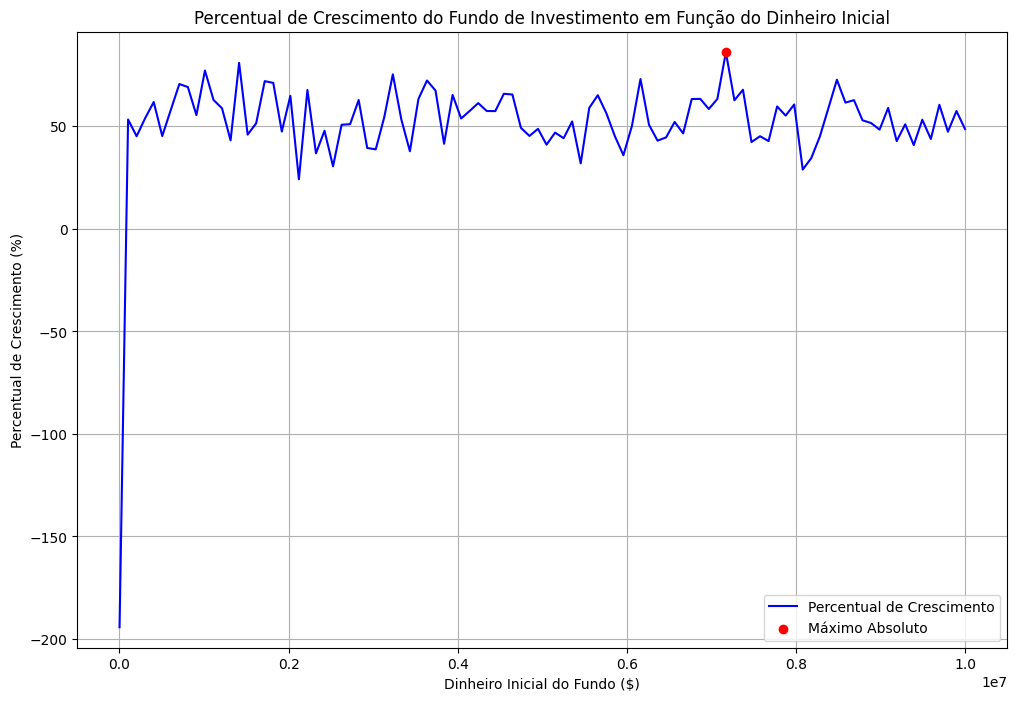

In [149]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(Min_Floor_Fund_Last_Strategy, Max_Selling_Fund_Last_Strategy + Step_money_Last_Strategy, Step_money_Last_Strategy)  # Valores de $50 a $10,000,150

# Lista para armazenar os resultados de percentual de ganhos para cada fundo inicial
percentual_ganhos = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0           # Posição long (ações compradas)
    num_shares_short = 0.0     # Posição short (ações vendidas a descoberto)
    short_sale_price = 0.0     # Preço de abertura da operação short
    if Paid_Sun_Tzu:
        proxima_cobranca = last_subsets_dates_test[0]

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_test_np) - 1):
        current_price = float(tensor_test_np[i + 1][0])  # Preço da ação para a operação
        prediction_raw = tensor_test_np[i][1]              # Previsão atual (grau de certeza)

        if Paid_Sun_Tzu:
            if proxima_cobranca <= last_subsets_dates_test[i]:
                proxima_cobranca = last_subsets_dates_test[i] + relativedelta(months=1)
                fund -= valor_cobranca_test

        # Converter a previsão para float ou definir 0 se for 'none'
        if prediction_raw != 'none':
            prediction = float(prediction_raw)
        else:
            prediction = 0.0

        # OPERAÇÃO LONG (compra) se previsão for fortemente alta: > sensibilidade_decisiva2
        if prediction > sensibilidade_decisiva2 and fund > 0:
            # Se houver posição short aberta, cobrir (fechar) o short primeiro
            if num_shares_short > 0:
                exec_px = exec_price_with_slippage("cover", current_price, symbol)
                SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_test[i])
                profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
                fund -= num_shares_short * exec_px + SEC_fee
                num_shares_short = 0.0
                short_sale_price = 0.0

            # Comprar ações: investir uma fração do fundo determinada pelo coeficiente_C e pelo grau de certeza
            percentage_to_spend = coeficiente_c * max(0.0, min(1.0, (prediction - sensibilidade_decisiva2) / max(eps, 1 - sensibilidade_decisiva2)))
            if percentage_to_spend > 1:
                percentage_to_spend = 1
            exec_px = exec_price_with_slippage("buy", current_price, symbol)
            amount_to_invest = percentage_to_spend * fund
            num_shares_to_buy = amount_to_invest / exec_px
            cost = num_shares_to_buy * exec_px
            fund -= cost
            num_shares += num_shares_to_buy

        # OPERAÇÃO VENDA/SHORT se previsão for fortemente baixa: < sensibilidade_decisiva1
        elif prediction < sensibilidade_decisiva1:
            # Se houver posição long, vende uma fração determinada pelo coeficiente_V e pelo grau de certeza
            if num_shares > 0:
                percentage_to_sell = coeficiente_v * max(0.0, min(1.0, (sensibilidade_decisiva1 - prediction) / max(eps, sensibilidade_decisiva1)))
                if percentage_to_sell > 1:
                    percentage_to_sell = 1
                exec_px = exec_price_with_slippage("sell", current_price, symbol)
                amount_to_sell = percentage_to_sell * num_shares * current_price
                shares_to_sell = amount_to_sell / exec_px
                proceeds = shares_to_sell * exec_px
                SEC_fee = calculate_fee("sell", proceeds)
                fund += proceeds - SEC_fee
                num_shares -= shares_to_sell

            # Se não houver posição long e nem short aberta, iniciar operação short
            if num_shares_short == 0 and fund > 0:
                percentage_to_short = coeficiente_s * max(0.0, min(1.0, (sensibilidade_decisiva1 - prediction) / max(eps, sensibilidade_decisiva1)))
                if percentage_to_short > 1:
                    percentage_to_short = 1
                # Utiliza o fundo disponível como capacidade máxima para short-selling
                exec_px = exec_price_with_slippage("short", current_price, symbol)
                amount_to_short = percentage_to_short * fund
                num_shares_to_short = amount_to_short / exec_px
                num_shares_short = num_shares_to_short
                short_sale_price = exec_px
                SEC_fee = calculate_fee("short", num_shares_to_short * exec_px)
                fund += num_shares_to_short * exec_px - SEC_fee
                time_at_short = last_subsets_dates_test[i]
        else:
            # Zona neutra: nenhuma operação
            pass

    # Ao final do tensor, fechar quaisquer posições abertas:
    final_price = float(tensor_test_np[-1][0])

    # Fechar posição long, se houver
    if num_shares > 0:
        exec_px = exec_price_with_slippage("sell", final_price, symbol)
        SEC_fee = calculate_fee("sell", num_shares * exec_px)
        proceeds = num_shares * exec_px - SEC_fee
        fund += proceeds
        num_shares = 0.0

    # Fechar posição short, se houver (realizando lucro ou prejuízo do short)
    if num_shares_short > 0:
        exec_px = exec_price_with_slippage("cover", current_price, symbol)
        SEC_fee = calculate_fee("cover", num_shares_short * short_sale_price, time_at_short, last_subsets_dates_test[-1])
        profit = num_shares_short * (short_sale_price - exec_px) - SEC_fee
        fund -= num_shares_short * exec_px + SEC_fee
        num_shares_short = 0.0
        short_sale_price = 0.0

    # Calcular o percentual de crescimento da estratégia
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
    percentual_ganhos.append(percentage_increase_strategy)

# Encontrar o índice do valor máximo de percentual_ganhos
max_index = np.argmax(percentual_ganhos)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = percentual_ganhos[max_index]

print(f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%")

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(initial_fund_values, percentual_ganhos, label='Percentual de Crescimento', color='blue')
plt.scatter(max_initial_fund, max_percentage_increase, color='red', zorder=5, label="Máximo Absoluto")
plt.ylim(min(percentual_ganhos) - 10, max(percentual_ganhos) + 10)
plt.title('Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial')
plt.xlabel('Dinheiro Inicial do Fundo ($)')
plt.ylabel('Percentual de Crescimento (%)')
plt.grid(True)
plt.legend()
plt.show()

# **Results Com Short-Selling**

### **Otimization**

Aqui podes comprar todas as estratégias testadas anteriormente sem short selling lado a lado para teres uma melhor visão comprativa de qual funciona melhor.

In [150]:
def print_header(title):
    """Prints a header with an underline for emphasis."""
    print(title)
    print("-" * len(title))

def print_section(title):
    """Prints a section header followed by a blank line."""
    print_header(title)
    print()

def print_result_line(prefix, data, labels, formats):
    """
    Prints a result line using the provided prefix, labels, and format strings.

    :param prefix: A string to print before the results (can be empty).
    :param data: A tuple or list of values to be printed.
    :param labels: A list of label names for each value.
    :param formats: A list of format strings for each corresponding value.
    """
    parts = [f"{label}={fmt.format(val)}" for label, val, fmt in zip(labels, data, formats)]
    print(f"{prefix}{'; '.join(parts)}")

In [151]:
# Main Market Growth Information
print(f'Crescimento Natural do Mercado Entre {last_subsets_dates_otimization[0]} e {last_subsets_dates_otimization[-1]} para ações {symbol}:')
print(f'{percentage_increase_otimization:.5f}%\n')

print_section("Com Short-Selling:")

# Section: Results based on Mean Percentage Difference with Short-Selling
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual:")

print("Absolute Buy and Sell com Short-Selling:")
print_result_line(
    prefix="  ",
    data=Results_Mean_cS_array[0],
    labels=["Sensibilidade Decisiva 1", "Sensibilidade Decisiva 2", "Média da Diferença Percentual"],
    formats=["{:.2f}", "{:.2f}", "{:.5f}"]
)
print()

print("Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:")
print_result_line(
    prefix="  ",
    data=Results_Mean_cS_array[1],
    labels=["Sensibilidade Decisiva 1", "Sensibilidade Decisiva 2", "Coeficiente de Compra",
            "Coeficiente de Venda", "Coeficiente de Short-Selling", "Média da Diferença Percentual"],
    formats=["{:.2f}", "{:.2f}", "{:.2f}", "{:.2f}", "{:.2f}", "{:.5f}"]
)
print("\n")

# Section: Results based on Last Date Percentage Difference with Short-Selling
print_section("Resultados ao Otimizar em Função da Diferença Percentual da Última Data:")

print("Absolute Buy and Sell com Short-Selling:")
print_result_line(
    prefix="  ",
    data=Results_Last_cS_array[0],
    labels=["Sensibilidade Decisiva 1", "Sensibilidade Decisiva 2", "Diferença Percentual"],
    formats=["{:.2f}", "{:.2f}", "{:.5f}"]
)
print()

print("Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:")
combined_data = (
    Results_Last_cS_array[1][0],  # Sensibilidade Decisiva 1
    Results_Last_cS_array[1][1],  # Sensibilidade Decisiva 2
    Results_Last_cS_array[1][2],  # Coeficiente de Compra
    Results_Last_cS_array[1][3],  # Coeficiente de Venda
    Results_Last_cS_array[1][4],  # Coeficiente de Short-Selling
    Results_Last_cS_array[1][5]   # Diferença Percentual
)
print_result_line(
    prefix="  ",
    data=combined_data,
    labels=["Sensibilidade Decisiva 1", "Sensibilidade Decisiva 2", "Coeficiente de Compra",
            "Coeficiente de Venda", "Coeficiente de Short-Selling", "Diferença Percentual"],
    formats=["{:.2f}", "{:.2f}", "{:.2f}", "{:.2f}", "{:.2f}", "{:.5f}"]
)

Crescimento Natural do Mercado Entre 2023-05-02 e 2024-12-30 para ações AAPL:
51.18941%

Com Short-Selling:
------------------

Resultados ao Otimizar em Função da Média da Diferença Percentual:
------------------------------------------------------------------

Absolute Buy and Sell com Short-Selling:
  Sensibilidade Decisiva 1=0.17; Sensibilidade Decisiva 2=0.76; Média da Diferença Percentual=7.30239

Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 1=1.00; Sensibilidade Decisiva 2=0.00; Coeficiente de Compra=2.00; Coeficiente de Venda=2.50; Coeficiente de Short-Selling=1.00; Média da Diferença Percentual=21.25022


Resultados ao Otimizar em Função da Diferença Percentual da Última Data:
------------------------------------------------------------------------

Absolute Buy and Sell com Short-Selling:
  Sensibilidade Decisiva 1=0.17; Sensibilidade Decisiva 2=0.70; Diferença Percentual=12.12644

Independent Parcial Buy, Se

### **Test**

In [152]:
# Main Market Growth Information
print(f'Crescimento Natural do Mercado Entre {last_subsets_dates_test[0]} e {last_subsets_dates_test[-1]}, Dataset de test, para ações {symbol}:')
print(f'{percentage_increase_test:.5f}%\n')

print_section("Sem Short-Selling:")

# Optimization based on Mean Percentage Difference
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")

print("Absolute Buy and Sell:")
print(f"Sensibilidade Decisiva 1 = {Results_Mean_cS_array_test[0][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_cS_array_test[0][1]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Mean_cS_array_test[0][2] + percentage_increase_test):.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_cS_array_test[0][3]:.5f}\n")

print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(f"Sensibilidade Decisiva 1 = {Results_Mean_cS_array_test[1][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_cS_array_test[1][1]:.2f}; "
      f"Coeficiente de Compra = {Results_Mean_cS_array_test[1][2]:.2f}; "
      f"Coeficiente de Venda = {Results_Mean_cS_array_test[1][3]:.2f}; "
      f"Coeficiente de Short-Selling = {Results_Mean_cS_array_test[1][4]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Mean_cS_array_test[1][5] + percentage_increase_test):.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_cS_array_test[1][6]:.5f}\n")

Crescimento Natural do Mercado Entre 2023-05-02 e 2024-12-30, Dataset de test, para ações AAPL:
51.18941%

Sem Short-Selling:
------------------

Resultados ao Otimizar em Função da Média da Diferença Percentual
-----------------------------------------------------------------

Absolute Buy and Sell:
Sensibilidade Decisiva 1 = 0.12; Sensibilidade Decisiva 2 = 0.76; Ganho Percentual da Estratégia = 36.92; Média da Diferença Percentual = 6.11303

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
Sensibilidade Decisiva 1 = 1.00; Sensibilidade Decisiva 2 = 0.00; Coeficiente de Compra = 2.00; Coeficiente de Venda = 2.50; Coeficiente de Short-Selling = 4.00; Ganho Percentual da Estratégia = 64.17; Média da Diferença Percentual = 7.78694



# **Results Com e Sem Short-Selling (Comparação)**

### **Otimization**

In [153]:
def print_header(title):
    print(title)
    print("-" * len(title))

def print_result(label, *values, formats=None):
    """
    Prints a label and its corresponding values formatted according to the 'formats' list.
    If formats is not provided, values are printed as is.
    """
    formatted_values = []
    if formats:
        for v, fmt in zip(values, formats):
            formatted_values.append(fmt.format(v))
    else:
        formatted_values = values
    print(f"  {label}: {'; '.join(formatted_values)}")

def print_section(title, lines=None):
    print_header(title)
    if lines:
        for line in lines:
            print(line)
    print()  # extra newline for spacing

In [154]:
# Main Market Growth Information
print(f'Crescimento Natural do Mercado Entre {last_subsets_dates_otimization[0]} e {last_subsets_dates_otimization[-1]} para ações {symbol}:')
print(f'{percentage_increase_otimization:.5f}%\n\n')

# Without Short-Selling
print_section("Sem Short-Selling")

# Optimization based on Mean Percentage Difference
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")
print("Absolute Buy and Sell:")
print_result("Sensibilidade Decisiva 1", Results_Mean_array[0][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Mean_array[0][1], formats=["{:.2f}"])
print_result("Média da Diferença Percentual", Results_Mean_array[0][2], formats=["{:.5f}"])
print()
print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print_result("Sensibilidade Decisiva 1", Results_Mean_array[1][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Mean_array[1][1], formats=["{:.2f}"])
print_result("Coeficiente de Compra", Results_Mean_array[1][2], formats=["{:.2f}"])
print_result("Coeficiente de Venda", Results_Mean_array[1][3], formats=["{:.2f}"])
print_result("Média da Diferença Percentual", Results_Mean_array[1][4], formats=["{:.5f}"])
print("\n")

# Optimization based on Last Date Percentage Difference
print_section("Resultados ao Otimizar em Função da Diferença Percentual da Última Data")
print("Absolute Buy and Sell:")
print_result("Sensibilidade Decisiva 1", Results_Last_array[0][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Last_array[0][1], formats=["{:.2f}"])
print_result("Diferença Percentual", Results_Last_array[0][2], formats=["{:.5f}"])
print()
print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print_result("Sensibilidade Decisiva 1", Results_Last_array[1][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Last_array[1][1], formats=["{:.2f}"])
print_result("Coeficiente de Compra", Results_Last_array[1][2], formats=["{:.2f}"])
print_result("Coeficiente de Venda", Results_Last_array[1][3], formats=["{:.2f}"])
print_result("Diferença Percentual", Results_Last_array[1][4], formats=["{:.5f}"])
print("\n")

# With Short-Selling
print_section("Com Short-Selling")

# Optimization based on Mean Percentage Difference with Short-Selling
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")
print("Absolute Buy and Sell com Short-Selling:")
print_result("Sensibilidade Decisiva 1", Results_Mean_cS_array[0][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Mean_cS_array[0][1], formats=["{:.2f}"])
print_result("Média da Diferença Percentual", Results_Mean_cS_array[0][2], formats=["{:.5f}"])
print()
print("Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:")
print_result("Sensibilidade Decisiva 1", Results_Mean_cS_array[1][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Mean_cS_array[1][1], formats=["{:.2f}"])
print_result("Coeficiente de Compra", Results_Mean_cS_array[1][2], formats=["{:.2f}"])
print_result("Coeficiente de Venda", Results_Mean_cS_array[1][3], formats=["{:.2f}"])
print_result("Coeficiente de Short-Selling", Results_Mean_cS_array[1][4], formats=["{:.2f}"])
print_result("Média da Diferença Percentual", Results_Mean_cS_array[1][5], formats=["{:.5f}"])
print("\n")

# Optimization based on Last Date Percentage Difference with Short-Selling
print_section("Resultados ao Otimizar em Função da Diferença Percentual da Última Data")
print("Absolute Buy and Sell com Short-Selling:")
print_result("Sensibilidade Decisiva 1", Results_Last_cS_array[0][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Last_cS_array[0][1], formats=["{:.2f}"])
print_result("Diferença Percentual", Results_Last_cS_array[0][2], formats=["{:.5f}"])
print()
print("Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:")
print_result("Sensibilidade Decisiva 1", Results_Last_cS_array[1][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Last_cS_array[1][1], formats=["{:.2f}"])
print_result("Coeficiente de Compra", Results_Last_cS_array[1][2], formats=["{:.2f}"])
print_result("Coeficiente de Venda", Results_Last_cS_array[1][3], formats=["{:.2f}"])
print_result("Coeficiente de Short-Selling", Results_Last_cS_array[1][4], formats=["{:.2f}"])
print_result("Diferença Percentual", Results_Last_cS_array[1][5], formats=["{:.5f}"])

Crescimento Natural do Mercado Entre 2023-05-02 e 2024-12-30 para ações AAPL:
51.18941%


Sem Short-Selling
-----------------

Resultados ao Otimizar em Função da Média da Diferença Percentual
-----------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1: 0.12
  Sensibilidade Decisiva 2: 0.76
  Média da Diferença Percentual: 0.35978

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 1: 1.00
  Sensibilidade Decisiva 2: 0.00
  Coeficiente de Compra: 2.00
  Coeficiente de Venda: 2.00
  Média da Diferença Percentual: 9.81638


Resultados ao Otimizar em Função da Diferença Percentual da Última Data
-----------------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1: 0.00
  Sensibilidade Decisiva 2: 0.73
  Diferença Percentual: 1.68250

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 1: 

### **Test**

In [155]:
# Main Market Growth Information
print(f'Crescimento Natural do Mercado Entre {last_subsets_dates_test[0]} e {last_subsets_dates_test[-1]}, Dataset de test, para ações {symbol}:')
print(f'{percentage_increase_test:.5f}%\n')

print_section("Sem Short-Selling:")

# Optimization based on Mean Percentage Difference
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")

print("Absolute Buy and Sell:")
print(f"  Sensibilidade Decisiva 1 = {Results_Mean_array_test[0][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_array_test[0][1]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Mean_array_test[0][2] + percentage_increase_test):.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_array_test[0][3]:.5f}\n")

print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(f"  Sensibilidade Decisiva 1 = {Results_Mean_array_test[1][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_array_test[1][1]:.2f}; "
      f"Coeficiente de Compra = {Results_Mean_array_test[1][2]:.2f}; "
      f"Coeficiente de Venda = {Results_Mean_array_test[1][3]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Mean_array_test[1][4] + percentage_increase_test):.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_array_test[1][5]:.5f}\n")

print_section("Sem Short-Selling:")

# Optimization based on Mean Percentage Difference
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")

print("Absolute Buy and Sell:")
print(f"  Sensibilidade Decisiva 1 = {Results_Mean_cS_array_test[0][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_cS_array_test[0][1]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Mean_cS_array_test[0][2] + percentage_increase_test):.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_cS_array_test[0][3]:.5f}\n")

print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(f"  Sensibilidade Decisiva 1 = {Results_Mean_cS_array_test[1][0]:.2f}; "
      f"Sensibilidade Decisiva 2 = {Results_Mean_cS_array_test[1][1]:.2f}; "
      f"Coeficiente de Compra = {Results_Mean_cS_array_test[1][2]:.2f}; "
      f"Coeficiente de Venda = {Results_Mean_cS_array_test[1][3]:.2f}; "
      f"Coeficiente de Short-Selling = {Results_Mean_cS_array_test[1][4]:.2f}; "
      f"Ganho Percentual da Estratégia = {(Results_Mean_cS_array_test[1][5] + percentage_increase_test):.2f}; "
      f"Média da Diferença Percentual = {Results_Mean_cS_array_test[1][6]:.5f}\n")

Crescimento Natural do Mercado Entre 2023-05-02 e 2024-12-30, Dataset de test, para ações AAPL:
51.18941%

Sem Short-Selling:
------------------

Resultados ao Otimizar em Função da Média da Diferença Percentual
-----------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1 = 0.12; Sensibilidade Decisiva 2 = 0.76; Ganho Percentual da Estratégia = 44.91; Média da Diferença Percentual = 3.14975

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 1 = 1.00; Sensibilidade Decisiva 2 = 0.00; Coeficiente de Compra = 2.00; Coeficiente de Venda = 2.00; Ganho Percentual da Estratégia = 58.70; Média da Diferença Percentual = 2.81191

Sem Short-Selling:
------------------

Resultados ao Otimizar em Função da Média da Diferença Percentual
-----------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1 = 0.12; Sensibilidade Decisiva 2 = 0.76; Ganho